## Columns to be removed from training/validation

In [1]:
disqualified_columns = ["tls_joint_isoitu_policy_crt_count", "rdap_time_from_last_change", "lex_www_flag"]

# New problem features identified by Filip
disqualified_columns += ["lex_tld_abuse_score", "tls_leaf_cert_validity_len", "rdap_domain_active_time",
                         "tls_root_authority_hash",  "lex_tld_len", "tls_critical_extensions",
                         "tls_percentage_crt_with_policies"
                        ]         

# Dataset preparation

In [2]:
import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd
import numpy as np

from pyarrow import Table
from pandas import DataFrame, api, Int64Dtype
from pandas.core.dtypes import common as com
import sys
sys.path.append('..')
from utils.preprocess import NDF

def cast_timestamp(df: DataFrame):
    """
    Cast timestamp fields to seconds since epoch.
    """
    for col in df.columns:
        if com.is_timedelta64_dtype(df[col]):
            df[col] = df[col].dt.total_seconds()  # This converts timedelta to float (seconds)
        elif com.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].astype(np.int64) // 10**9  # Converts datetime64 to Unix timestamp (seconds)

    return df


def union_tables(tables: [pa.Table]) -> pa.Table:
    union_table = tables[0]
    for table in tables[1:]:
        right_not_in_union = union_table.join(right_table=table, keys='domain_name', join_type='right anti',
                                              coalesce_keys=True, use_threads=True)
        union_table = pa.concat_tables([union_table, right_not_in_union])
    return union_table

##################################
# EDIT to specify the model name #
##################################
model_name = "phishing_xgboost_model_nonndf"     
##################################

# #############################################################
# EDIT this to specify benign / malicious datasets to use     #
# #############################################################
benign_dataset_filenames = [
    '../feature-extraction/floor/benign_2312.parquet',
    '../feature-extraction/floor/umbrella_benign_FINISHED.parquet'
]
malicious_dataset_filenames = [
    '../feature-extraction/floor/phishing_2406_strict.parquet',
]
# #############################################################
# EDIT this for to set appropriate labels (malware, dga, ...) #
# #############################################################
benign_label = "benign"
malicious_label = "phishing"
# #############################################################

# Unify malicious datasets and benign datasets
schema = (pq.read_table(malicious_dataset_filenames[0])).schema # Use the schema from the first malicious filename
benign_tables = [pq.read_table(filename).cast(schema) for filename in benign_dataset_filenames]

malicious_tables = [pq.read_table(filename).cast(schema) for filename in malicious_dataset_filenames]
malicious = union_tables(malicious_tables)
benign = union_tables(benign_tables)

# Convert pyarrow tables to pandas dataframes
df_benign = benign.to_pandas()
df_malicious = malicious.to_pandas()

# Set appropriate labels
df_benign["label"] = benign_label
df_malicious["label"] = malicious_label

# Merge the dataframes together
df = merged_df = pd.concat([df_benign, df_malicious], ignore_index=True)
class_map = {benign_label: 0, malicious_label: 1}

# Drop the domain name column
df.drop('domain_name', axis=1, inplace=True)

# Cast timestamps
df = cast_timestamp(df)

# Handle NaNs
df.fillna(-1, inplace=True)

# Remove disqualified columns
for column in disqualified_columns:
    if column in df.columns:
        df.drop(column, axis=1, inplace=True)
df

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


,label,dns_has_dnskey,dns_A_count,dns_AAAA_count,dns_MX_count,dns_NS_count,dns_TXT_count,dns_SOA_count,dns_CNAME_count,dns_zone_level,...,rdap_ip_v4_count,rdap_ip_v6_count,rdap_ip_shortest_v4_prefix_len,rdap_ip_longest_v4_prefix_len,rdap_ip_shortest_v6_prefix_len,rdap_ip_longest_v6_prefix_len,rdap_ip_avg_admin_name_len,rdap_ip_avg_admin_name_entropy,rdap_ip_avg_admin_email_len,rdap_ip_avg_admin_email_entropy
0,benign,0.0,0,0,0,0,0,0,1,0,...,1,0,19,19,0,0,15.000000,0.221549,0.000000,0.000000
1,benign,0.0,0,0,0,0,0,0,1,0,...,1,0,19,19,0,0,15.000000,0.221549,0.000000,0.000000
2,benign,1.0,1,1,1,4,2,1,0,0,...,7,6,17,24,48,48,11.384615,0.287974,3.538462,0.023059
3,benign,0.0,1,0,0,0,0,0,0,0,...,1,0,16,16,0,0,14.000000,0.231138,0.000000,0.000000
4,benign,0.0,1,0,0,0,0,0,0,0,...,1,0,16,16,0,0,14.000000,0.231138,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
980744,phishing,0.0,1,0,0,2,0,1,0,0,...,17,2,13,16,22,22,6.210526,0.371952,23.894737,0.142238
980745,phishing,1.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000
980746,phishing,0.0,1,0,0,0,0,0,0,0,...,1,0,13,13,0,0,10.000000,0.292193,23.000000,0.157442
980747,phishing,0.0,1,1,0,0,2,0,0,0,...,1,1,21,21,48,48,10.000000,0.292193,23.000000,0.157442


In [3]:
# Convert the unique feature names to a list
#feature_names_list = ndf_dataset['feature_names'].unique().tolist()

# Print each feature name individually
#for feature in feature_names_list:
#    print(feature)


# Model validation function

In [4]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, log_loss, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from kneed import KneeLocator

# Helpers
from kneed import KneeLocator

def plot_metric(metric):
    plt.rcParams["figure.dpi"] = 300
    
    # Plot metric curves
    plt.plot(x_axis, results['training'][metric], label='Training set')
    plt.plot(x_axis, results['valid_1'][metric], label='Testing set')
    
    # Detect elbow using Kneedle algorithm
    kn = KneeLocator(x_axis, results['valid_1'][metric], curve='convex', direction='decreasing')
    if kn.knee:
        plt.vlines(kn.knee, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='red', label='Elbow at tree ' + str(kn.knee))
    
    plt.legend()
    mnames = {'error': 'Classification Error', 'binary_logloss': 'Log Loss', 'auc': 'AUC'}
    mname = mnames.get(metric, metric)  # Return the metric itself if it's not in the dictionary
    plt.ylabel(mname)
    plt.xlabel('Number of trees')
    plt.title('LightGBM ' + mname)
    plt.show()

    
# Tuning - graphs
def DisplayTuningGraph(scores):
    from numpy import array
    from numpy.ma import masked_array

    col_names = ['mean_train_score', 'mean_test_score']
    means_df = scores[col_names]
    ax = means_df.plot(kind='line', grid=True)

    from matplotlib import pyplot as plt
    plt.rcParams["figure.figsize"] = [12, 12]
    plt.rcParams["figure.autolayout"] = True

    plt.rcParams["figure.dpi"] = 300

    max_ids = means_df.idxmax(axis=0)

    for i in range(len(max_ids)):
        for col_name in col_names:
            value = means_df[col_name][max_ids[i]]
            id = max_ids[i]

            color = 'r' if max_ids[i] == max_ids['mean_test_score'] else 'grey'

            ax.scatter([id], [value],
                      marker='o',
                      color=color,
                      label='point',)

            ax.annotate(str(round(value, 3))+"_ID="+str(id),
                        (id, value),
                        xytext=(id+3, value))
    print(scores)

def ValidateModel_advanced(X_test, y_test, model): 
    y_pred = model.predict(X_test)
    
    # Classification report
    print(classification_report(y_test, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    tn, fp, fn, tp = cm.ravel()
    print("Confusion Matrix:")
    print("TN:", tn, "FP:", fp, "FN:", fn, "TP:", tp)

    # Plotting ROC Curve
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

    # Model-specific evaluations
    if isinstance(model, (XGBClassifier, LGBMClassifier)):
        
        if isinstance(model, (XGBClassifier)):
            results = model.evals_result()
        elif isinstance(model, (LGBMClassifier)):
            results = model.evals_result_

        training_key = 'training' if isinstance(model, LGBMClassifier) else 'validation_0'
        validation_key = 'valid_1' if isinstance(model, LGBMClassifier) else 'validation_1'
        
        print("Training metrics:", results[training_key].keys())
        print("Validation metrics:", results[validation_key].keys())

        trees = len(results[validation_key]['binary_logloss']) if isinstance(model, LGBMClassifier) else len(results[validation_key]['logloss'])
        x_axis = range(0, trees)

        def plot_metric(metric):
            plt.rcParams["figure.dpi"] = 300

            # Plot metric curves
            plt.plot(x_axis, results[training_key][metric], label='Training set')
            plt.plot(x_axis, results[validation_key][metric], label='Validation set')

            # Detect elbow using Kneedle algorithm
            kn = KneeLocator(x_axis, results[validation_key][metric], curve='convex', direction='decreasing')
            if kn.knee:
                plt.vlines(kn.knee, plt.ylim()[0], plt.ylim()[1], linestyles='dashed', colors='red', label='Elbow at tree ' + str(kn.knee))

            plt.legend()
            mnames = {'binary_logloss': 'Log Loss', 'auc': 'AUC'}
            mname = mnames.get(metric, metric)
            plt.ylabel(mname)
            plt.xlabel('Number of trees')
            plt.title(f'{type(model).__name__} {mname}')
            plt.show()

        if isinstance(model, LGBMClassifier):
            plot_metric('binary_logloss')
        elif isinstance(model, XGBClassifier):
            plot_metric('logloss')
            
        plot_metric('auc')
        
    elif isinstance(model, (RandomForestClassifier, AdaBoostClassifier)):
        # For RandomForest and AdaBoost, additional model-specific evaluations can be added here
        pass
    
    # Display the confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)  # Compute confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)  # Create display object
    disp.plot(cmap=plt.cm.Blues)  # Plot confusion matrix
    plt.show()  # Show the plot

## Supressing unwanted warnings (futures etc.)

In [5]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn.*')
warnings.filterwarnings('ignore', category=FutureWarning, module='xgboost.*')
warnings.filterwarnings('ignore', message="Series.__getitem__ treating keys as positions is deprecated.*")

# XGBoost

# Train-Test Split

In [6]:
from sklearn.model_selection import train_test_split

labels = df['label'].apply(lambda x: class_map[x]) # y vector
features = df.drop('label', axis=1).copy() # X matrix

X_train, X_test, Y_train, Y_test = train_test_split(
  features,
  labels,
  test_size=0.2,
  random_state=42,
  shuffle=True, 
  stratify=labels
)

## XGBoost model Training

In [97]:
import joblib
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# XGBoost parameters
params = {
    "objective": "binary:logistic",
    "tree_method": "gpu_hist",
    "sampling_method": "gradient_based",
    "max_depth": 9,
    "eta": 0.05,
    "min_child_weight": 1,
    "subsample": 0.6,
    "alpha": 0,
    "gamma": 0.05,
    "lambda": 1.7,
    "max_delta_step": 0,
    "grow_policy": "depthwise",
    "max_bin": 512,
    "n_estimators": 160,
    "scale_pos_weight": 0.002,
    "random_state": 42,
}

# Create the XGBoost model
model = xgb.XGBClassifier(**params)

# Train the model
eval_set = [(X_train, Y_train), (X_test, Y_test)]
model.fit(X_train, Y_train, eval_set=eval_set, eval_metric=["error", "logloss", "auc"])

# Save the model to a file
joblib.dump(model, 'models/' + model_name + '.joblib')

[0]	validation_0-error:0.16765	validation_0-logloss:0.46107	validation_0-auc:0.59188	validation_1-error:0.16765	validation_1-logloss:0.46115	validation_1-auc:0.59033
[1]	validation_0-error:0.16765	validation_0-logloss:0.46180	validation_0-auc:0.59197	validation_1-error:0.16765	validation_1-logloss:0.46195	validation_1-auc:0.59041
[2]	validation_0-error:0.16765	validation_0-logloss:0.46268	validation_0-auc:0.59201	validation_1-error:0.16765	validation_1-logloss:0.46292	validation_1-auc:0.59044
[3]	validation_0-error:0.16765	validation_0-logloss:0.46392	validation_0-auc:0.59201	validation_1-error:0.16765	validation_1-logloss:0.46422	validation_1-auc:0.59044
[4]	validation_0-error:0.16765	validation_0-logloss:0.46729	validation_0-auc:0.59260	validation_1-error:0.16765	validation_1-logloss:0.46760	validation_1-auc:0.59119
[5]	validation_0-error:0.16765	validation_0-logloss:0.46879	validation_0-auc:0.59260	validation_1-error:0.16765	validation_1-logloss:0.46919	validation_1-auc:0.59119
[6]	

['models/phishing_xgboost_model_nonndf.joblib']

## LightGBM model Validation

              precision    recall  f1-score   support

           0     0.9104    1.0000    0.9531    163265
           1     0.9999    0.5115    0.6768     32885

    accuracy                         0.9181    196150
   macro avg     0.9552    0.7557    0.8149    196150
weighted avg     0.9254    0.9181    0.9068    196150

Confusion Matrix:
TN: 163263 FP: 2 FN: 16064 TP: 16821


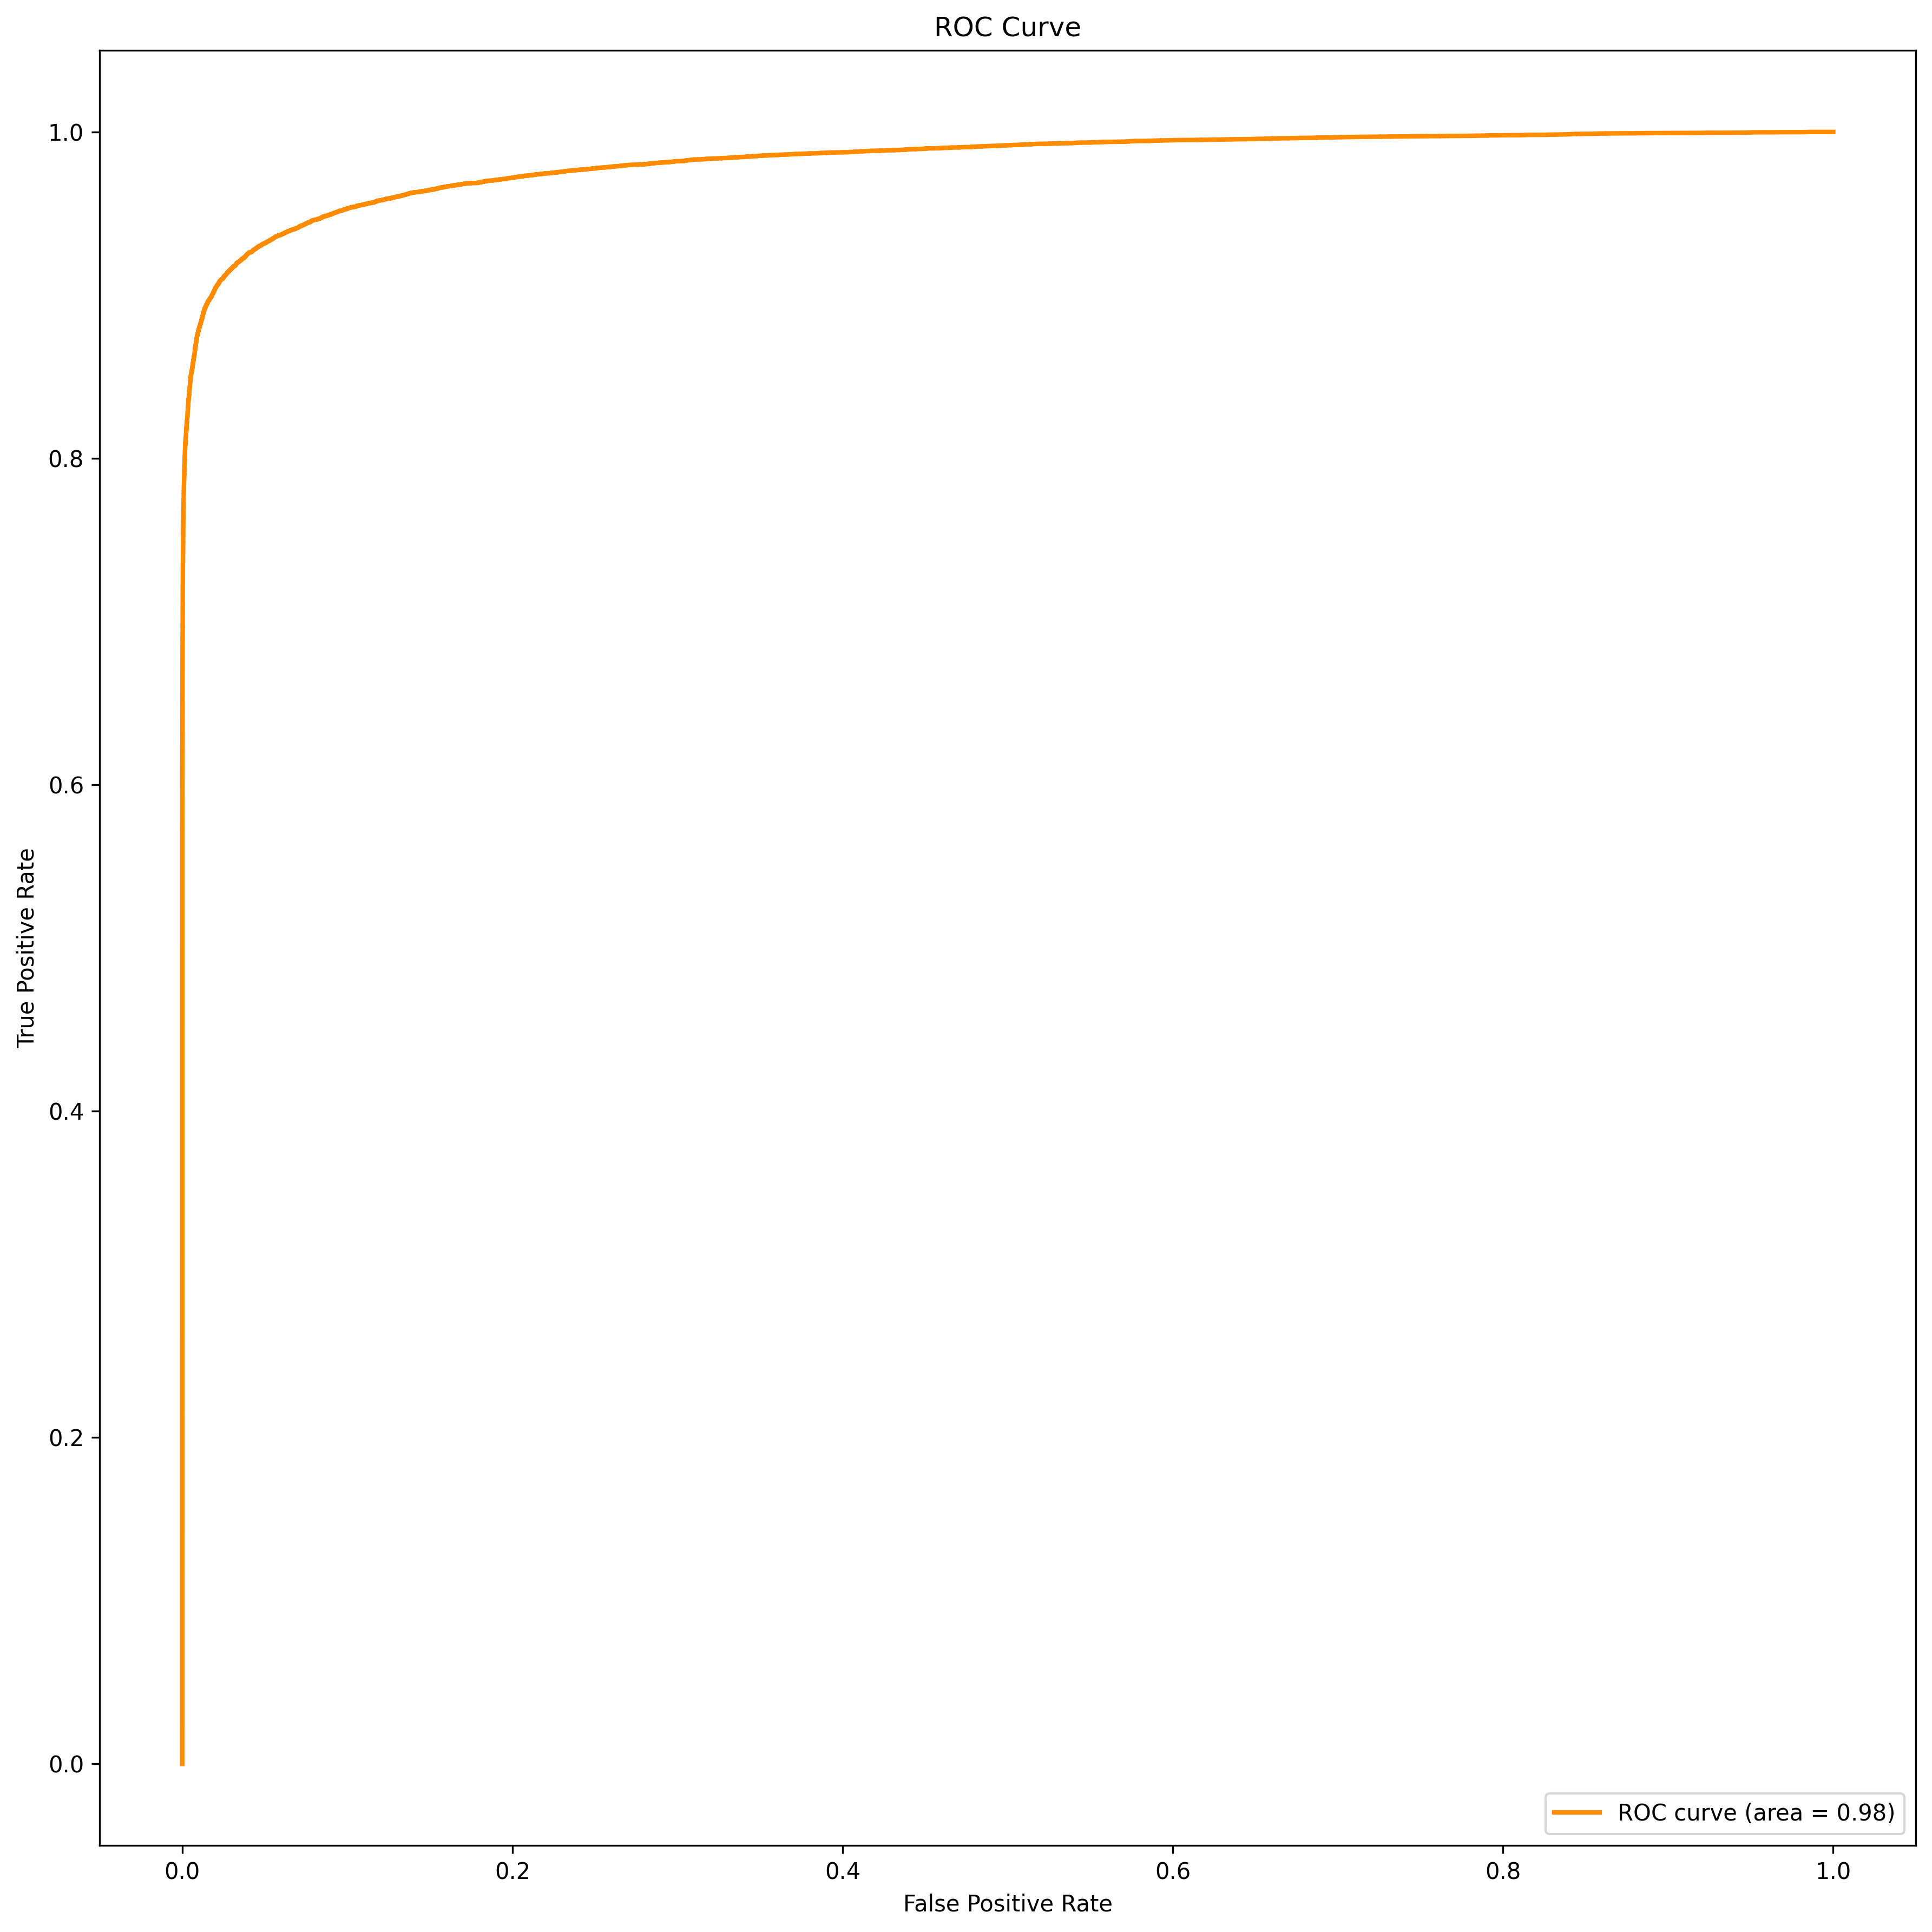

Training metrics: odict_keys(['error', 'logloss', 'auc'])
Validation metrics: odict_keys(['error', 'logloss', 'auc'])


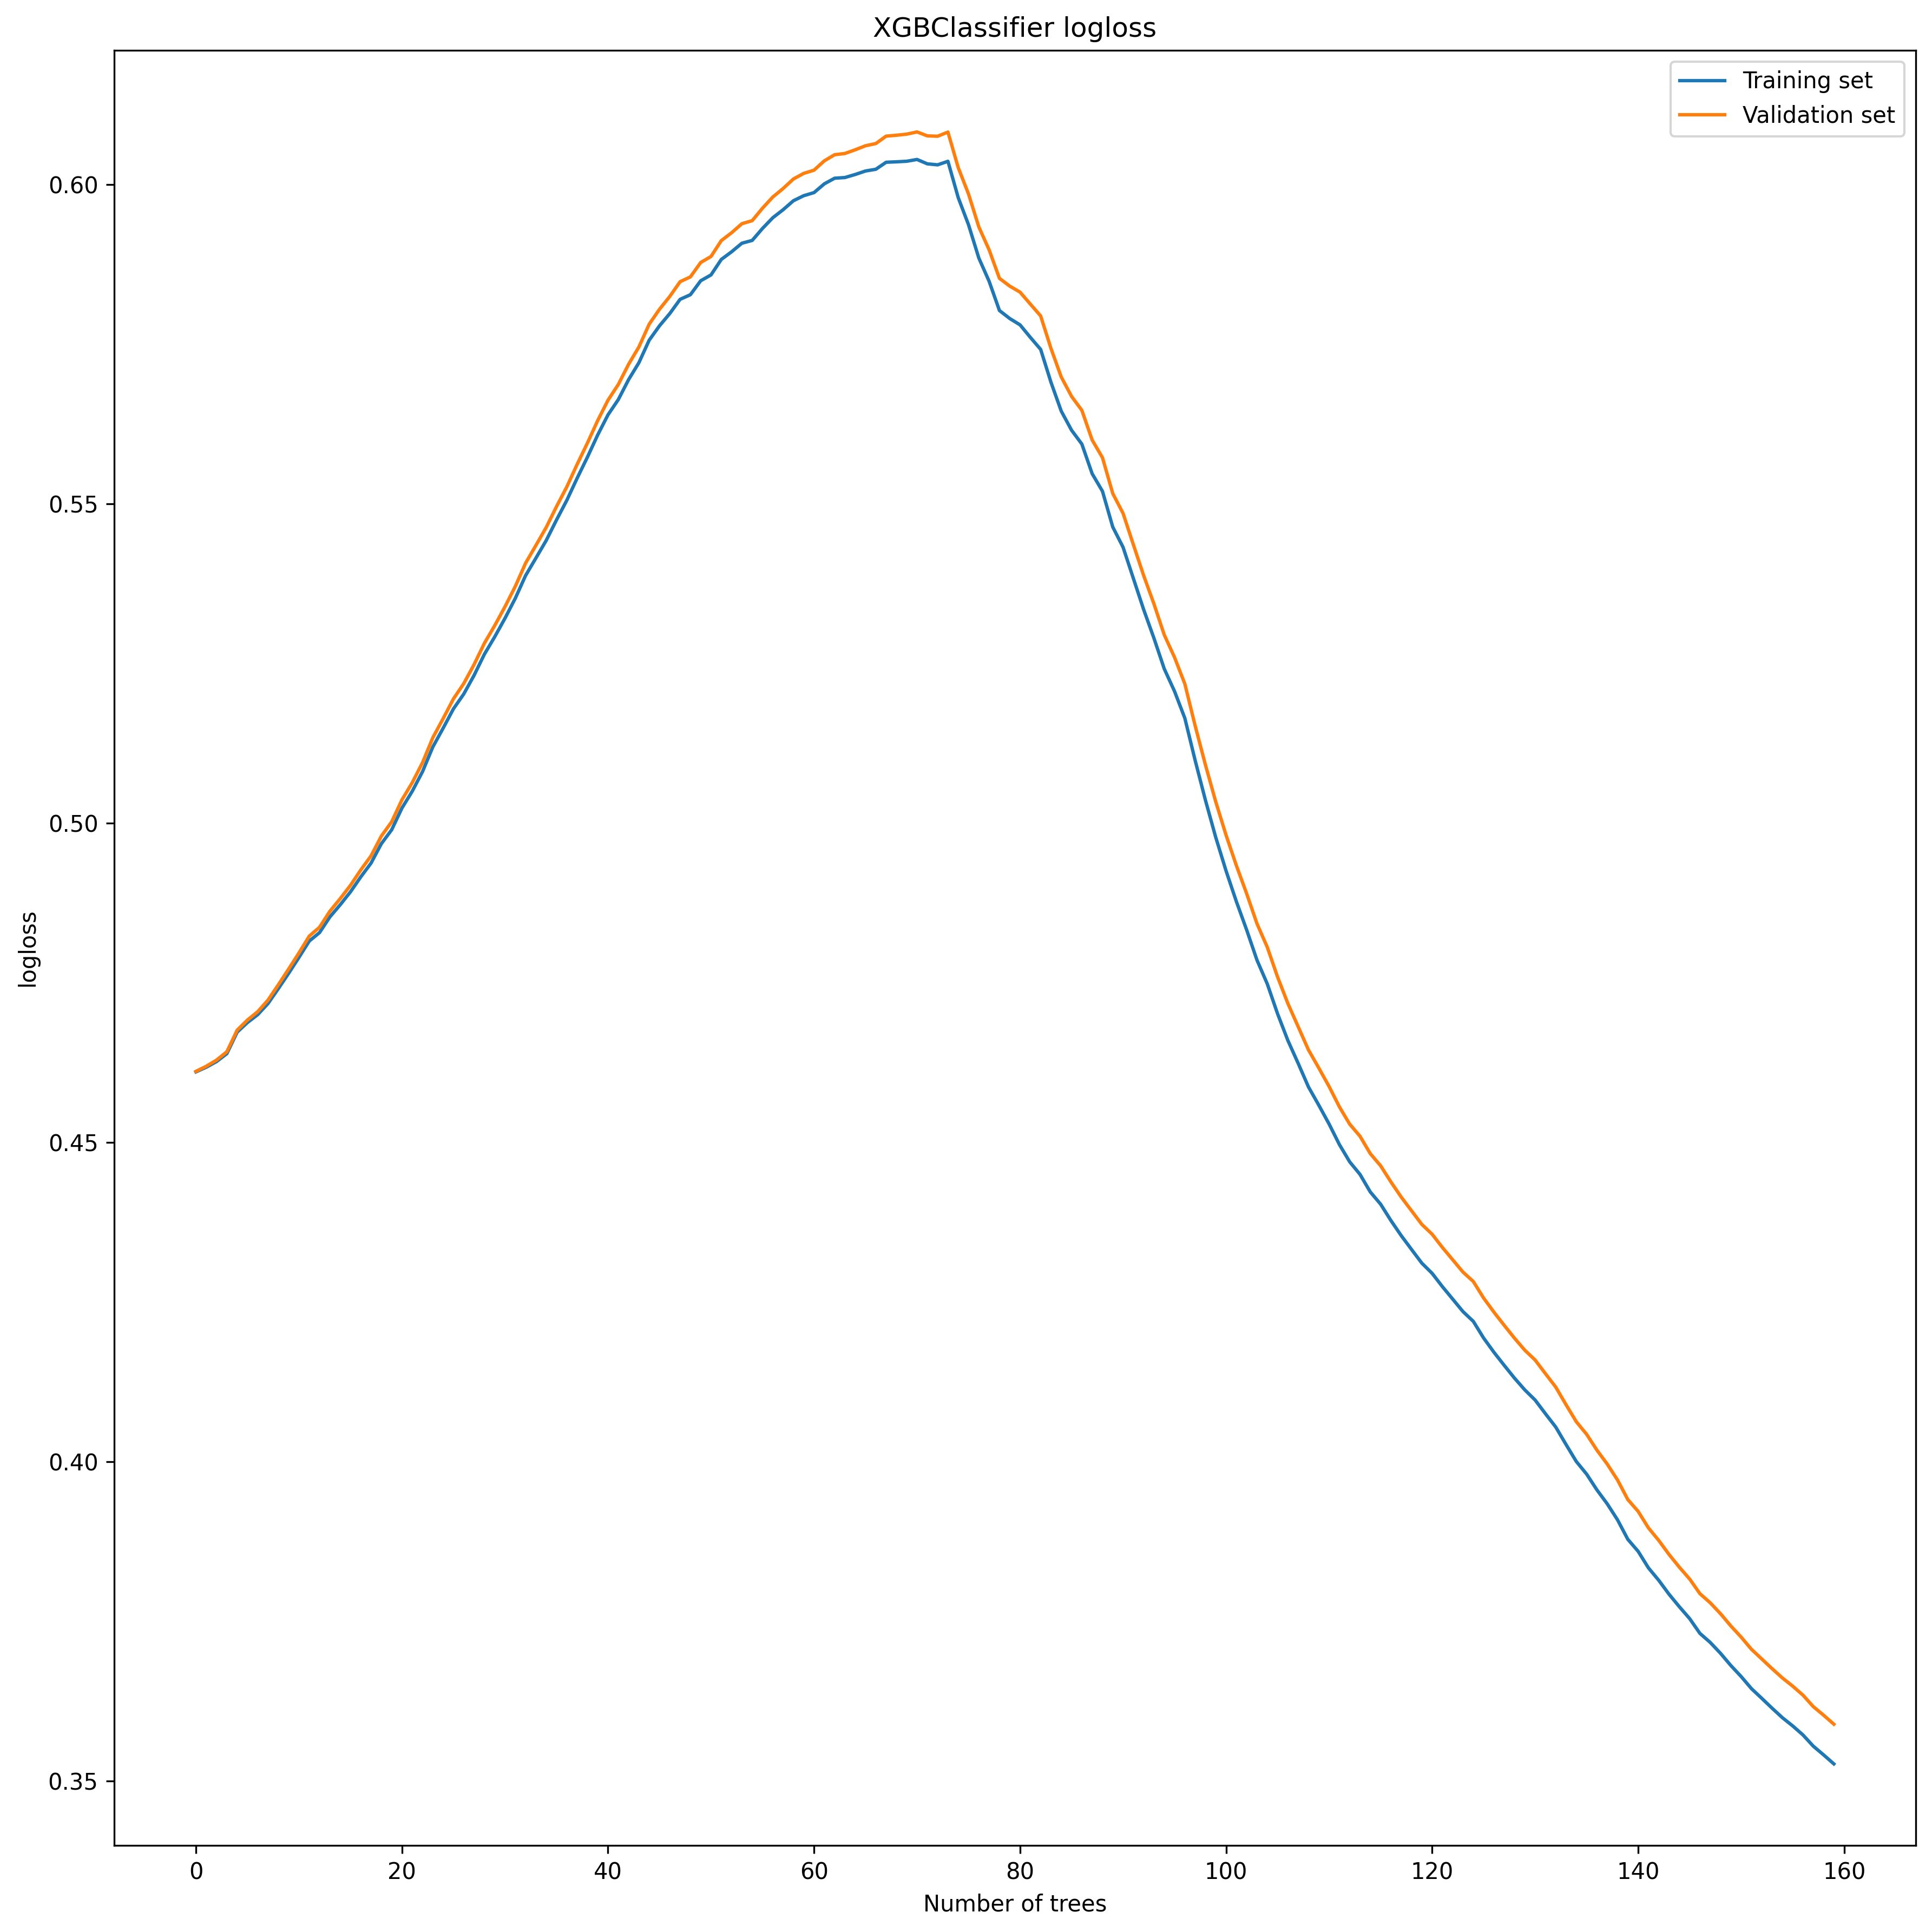

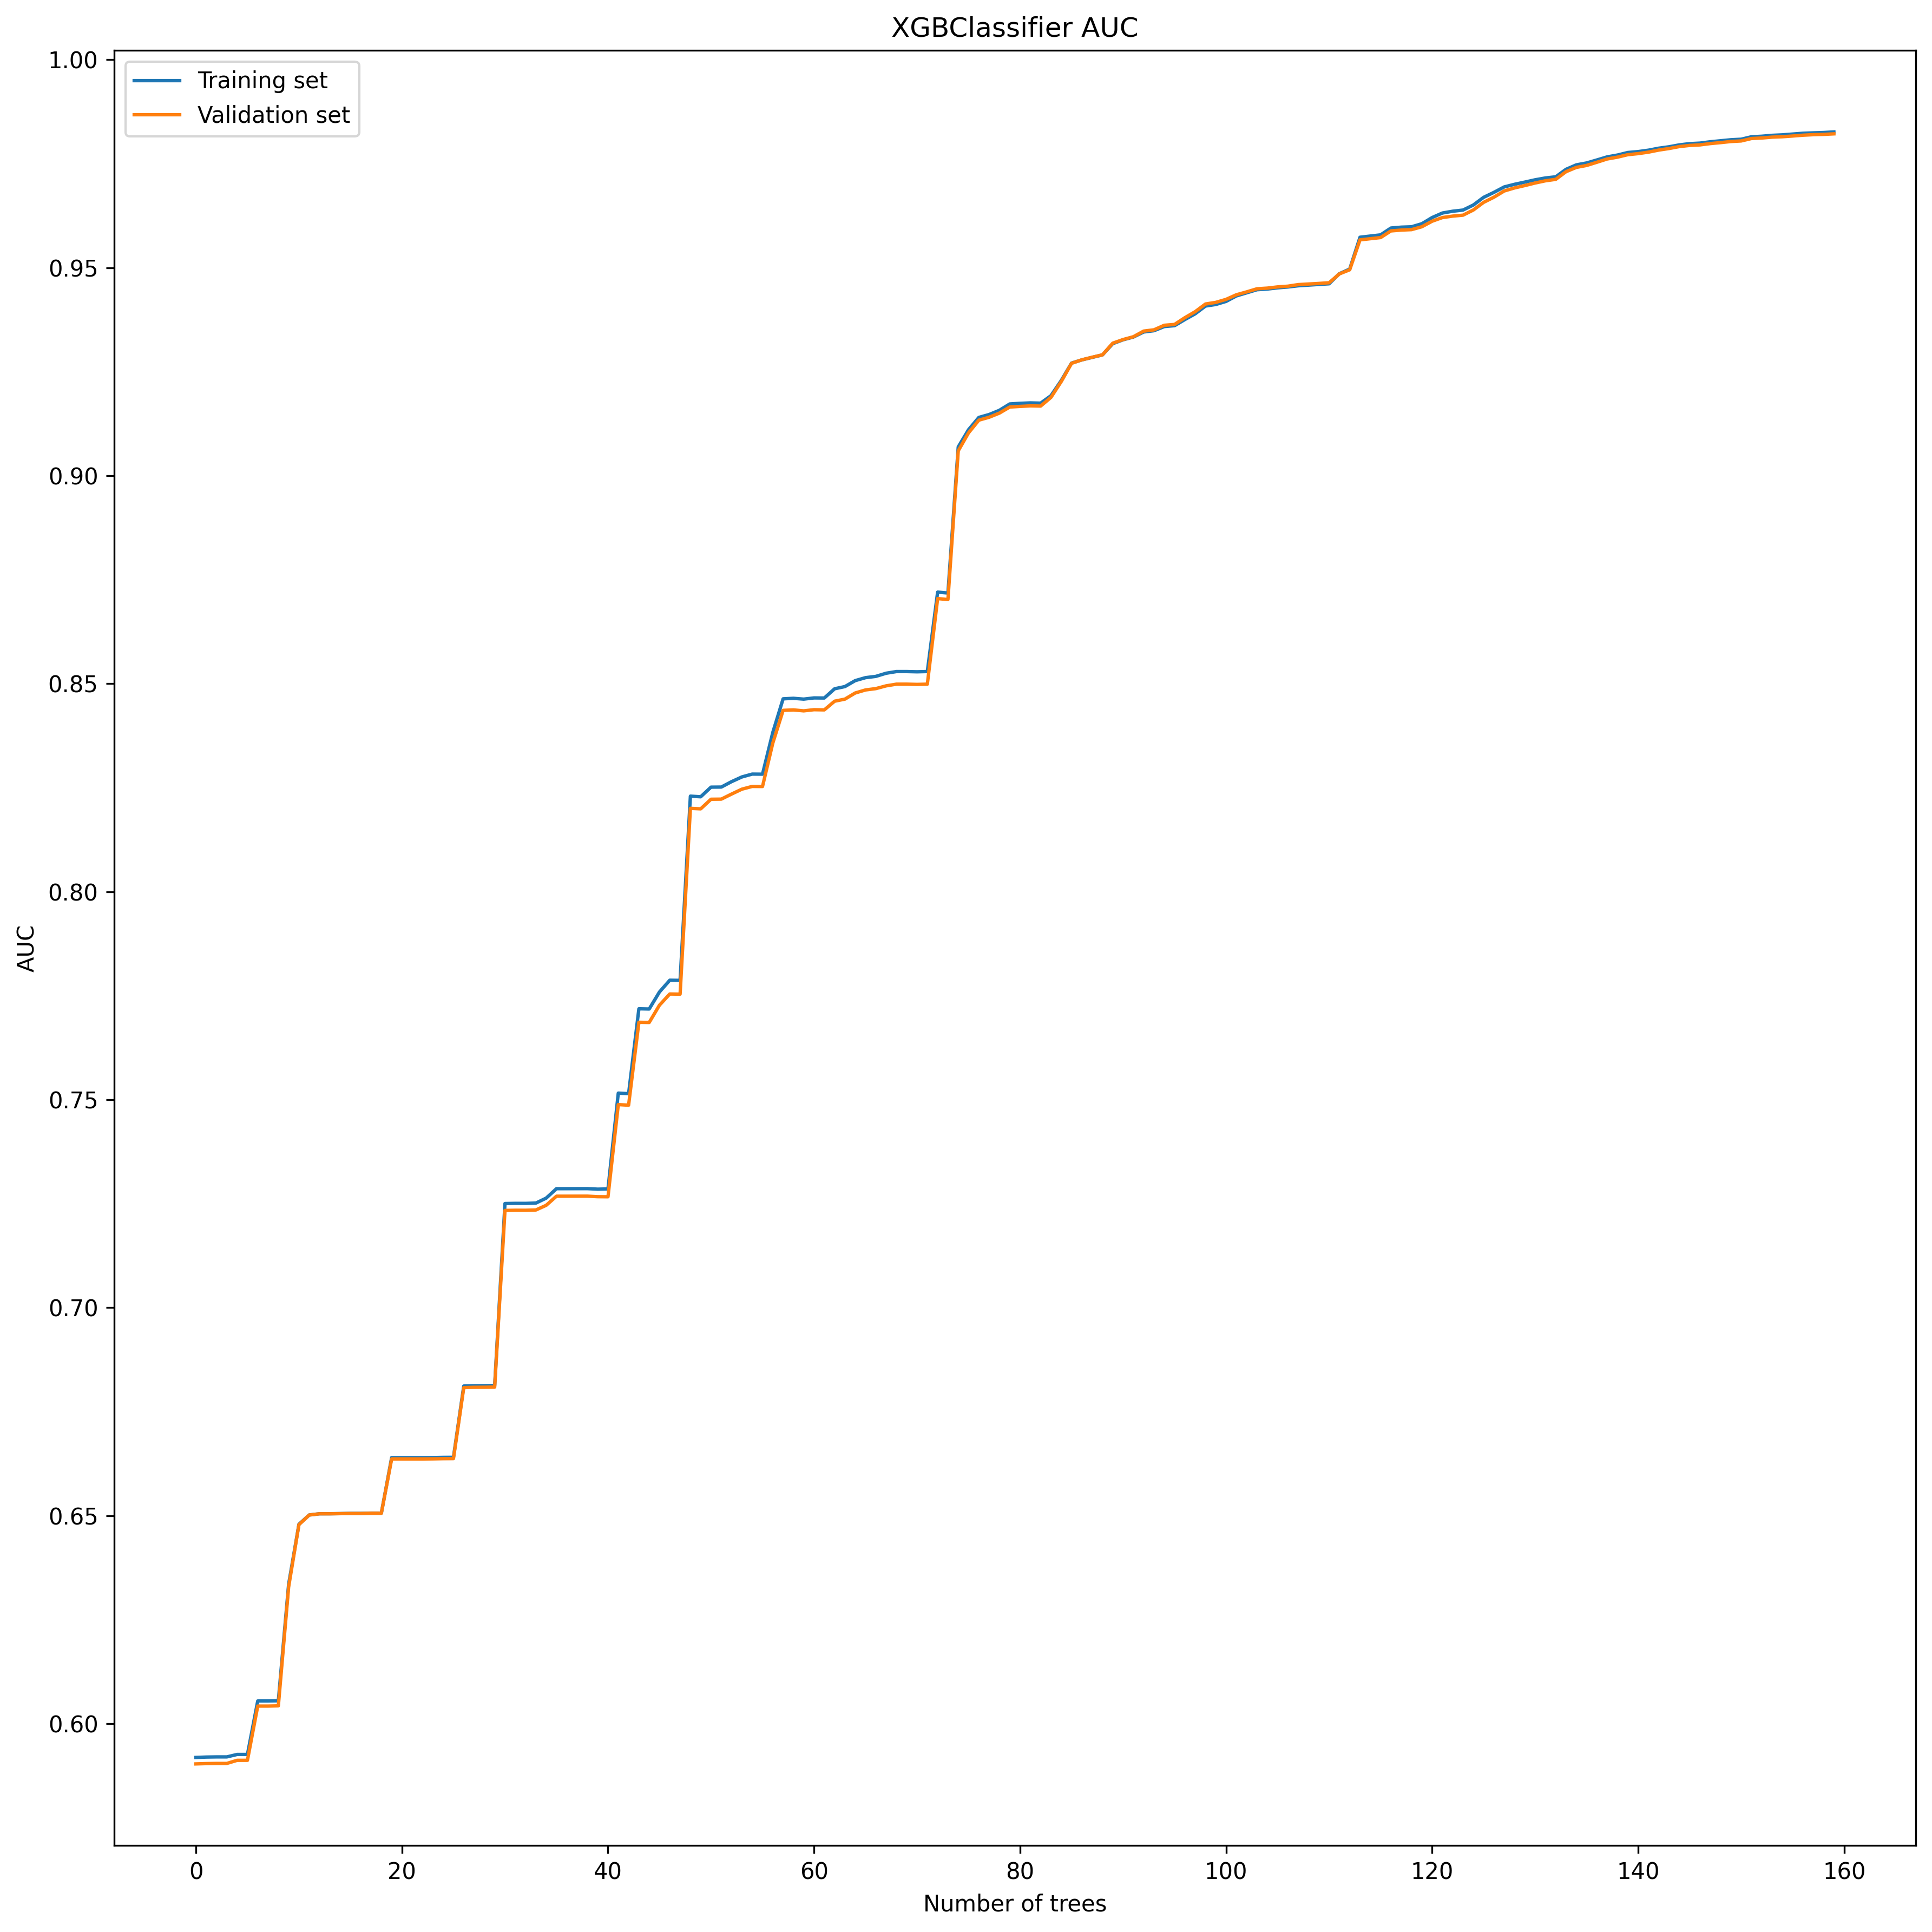

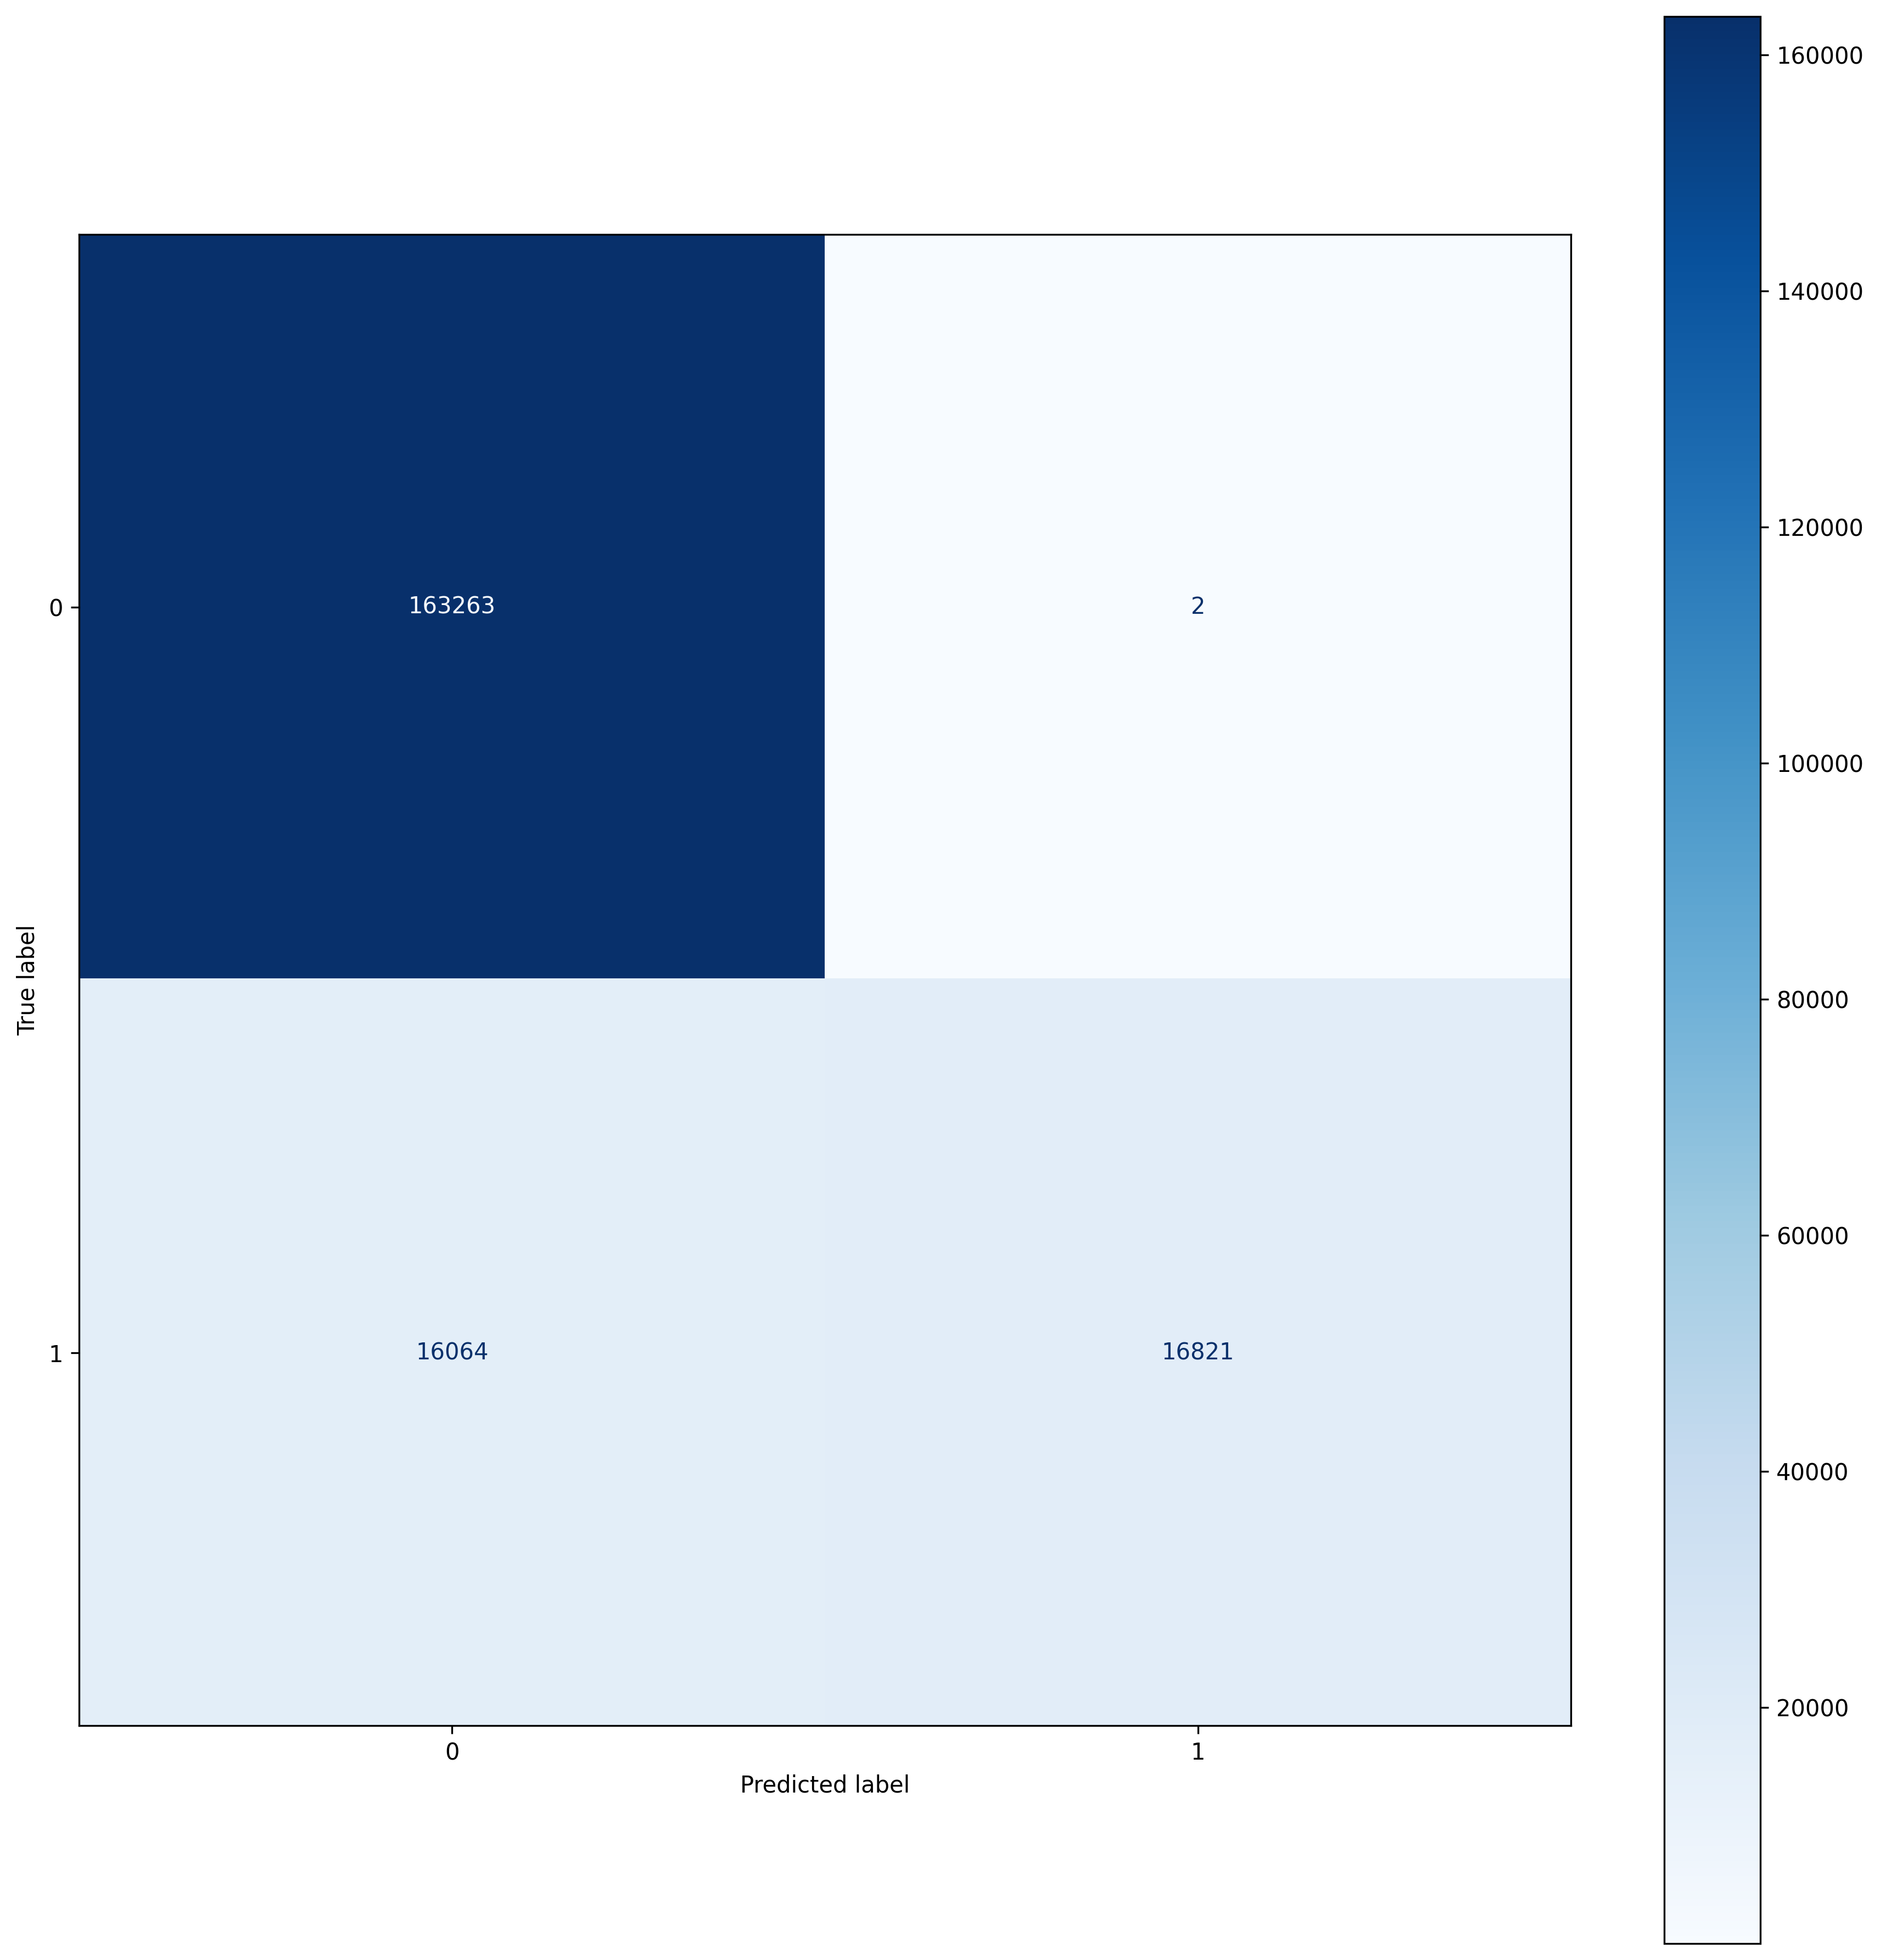

In [98]:
ValidateModel_advanced(X_test, Y_test, model)

## XGBoost model Tuning

In [99]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, log_loss

def FETA_Score(estimator, X, y):
    # Getting predictions
    y_pred = estimator.predict(X)
    y_pred_proba = estimator.predict_proba(X)
    
    # Calculating precision
    precision = precision_score(y, y_pred)
    
    # Calculating recall
    recall = recall_score(y, y_pred)
    
    # Calculating F1-score
    f1 = f1_score(y, y_pred)
    
    # Calculating FPR
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # Calculating Log Loss
    logloss = log_loss(y, y_pred_proba)
    
    # Estimating overfitting
    train_score = estimator.score(X_train, y_train) 
    validation_score = estimator.score(X, y) 
    overfitting = train_score - validation_score
    
    # Assigning weights
    w_precision = 0.1     # Precision
    w_recall = 0.1        # Recall
    w_f1 = 0.6            # F1
    w_fpr = -0.0          # Negative because lower FPR is better
    w_logloss = -0.0      # Negative because lower log loss is better
    w_overfitting = -0.2  # Negative because lower overfitting is better
    
    #w_precision = 0.0     # Precision
    #w_recall = 0.5        # Recall
    #w_f1 = 0.5            # F1
    #w_fpr = -0.0          # Negative because lower FPR is better
    #w_logloss = -0.1      # Negative because lower log loss is better
    #w_overfitting = -0.0  # Negative because lower overfitting is better
    
    # Assigning weights
    #w_precision = 0.1     # Precision
    #w_recall = 0.1        # Recall
    #w_f1 = 0.4            # F1
    #w_fpr = -0.1          # Negative because lower FPR is better
    #w_logloss = -0.1      # Negative because lower log loss is better
    #w_overfitting = -0.5  # Negative because lower overfitting is better
    
    # Combining metrics with weights
    combined_score = (w_precision * precision + w_recall * recall + w_f1 * f1 + w_fpr * fpr + w_overfitting * overfitting)
    
    return combined_score


In [100]:
xgb_tuning = False

if xgb_tuning:
    from xgboost import XGBClassifier
    from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
    import pandas as pd

    # Assuming df is your DataFrame and class_map maps your classes
    labels = df['label'].apply(lambda x: class_map[x])
    features = df.drop('label', axis=1).copy()

    # Split the dataset
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.3, random_state=42, shuffle=True, stratify=labels)

    params = {        
        "objective": "binary:logistic",
        "tree_method": "gpu_hist",
        "sampling_method": "gradient_based",
        "max_depth": 9, 
        "eta": 0.04, 
        "min_child_weight": 1,
        "subsample": 0.6, 
        "alpha": 0, 
        "gamma": 0.06, 
        "lambda": 2.0, 
        "max_delta_step": 0, 
        "grow_policy": "depthwise",
        "max_bin": 512,
        "n_estimators": 160, 
        "scale_pos_weight": 0.01,
        "random_state": 42  # Set the seed for each run
    }

    
    # XGBoost base model
    xgb = XGBClassifier(**params)
    
    # Grid of parameters to search    
    grid = {
        #'scale_pos_weight': [4, 4.5, 5, 5.2, 6.28, 6, 6.71],
        'max_depth': [8, 9, 10],
        'n_estimators': [130, 140, 150, 160],
        #'scale_pos_weight': [6.35],
        # Add other parameters here if needed
    }
    

    # Stratified K-Folds cross-validator
    cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=7)

    # Grid Search
    grid_search = GridSearchCV(
        estimator=xgb,
        param_grid=grid,
        cv=cv,
        #scoring='f1',  # You can change this to another scoring method if needed
        scoring=FETA_Score,  # Custom metric
        verbose=3,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

    # Best estimator
    best_xgb = grid_search.best_estimator_

    # Results
    scores = pd.DataFrame(grid_search.cv_results_)


In [101]:
a = ''
if xgb_tuning: 
    DisplayTuningGraph(scores)
    a = scores
a

''

## Testing on Validation Dataset

Accuracy: 0.9326612903225806
Weighted Accuracy: 0.7248784984079102
Precision: 0.8551724137931035
Recall: 0.45925925925925926
F1 Score: 0.5975903614457831
False Positive Rate: 0.009502262443438913


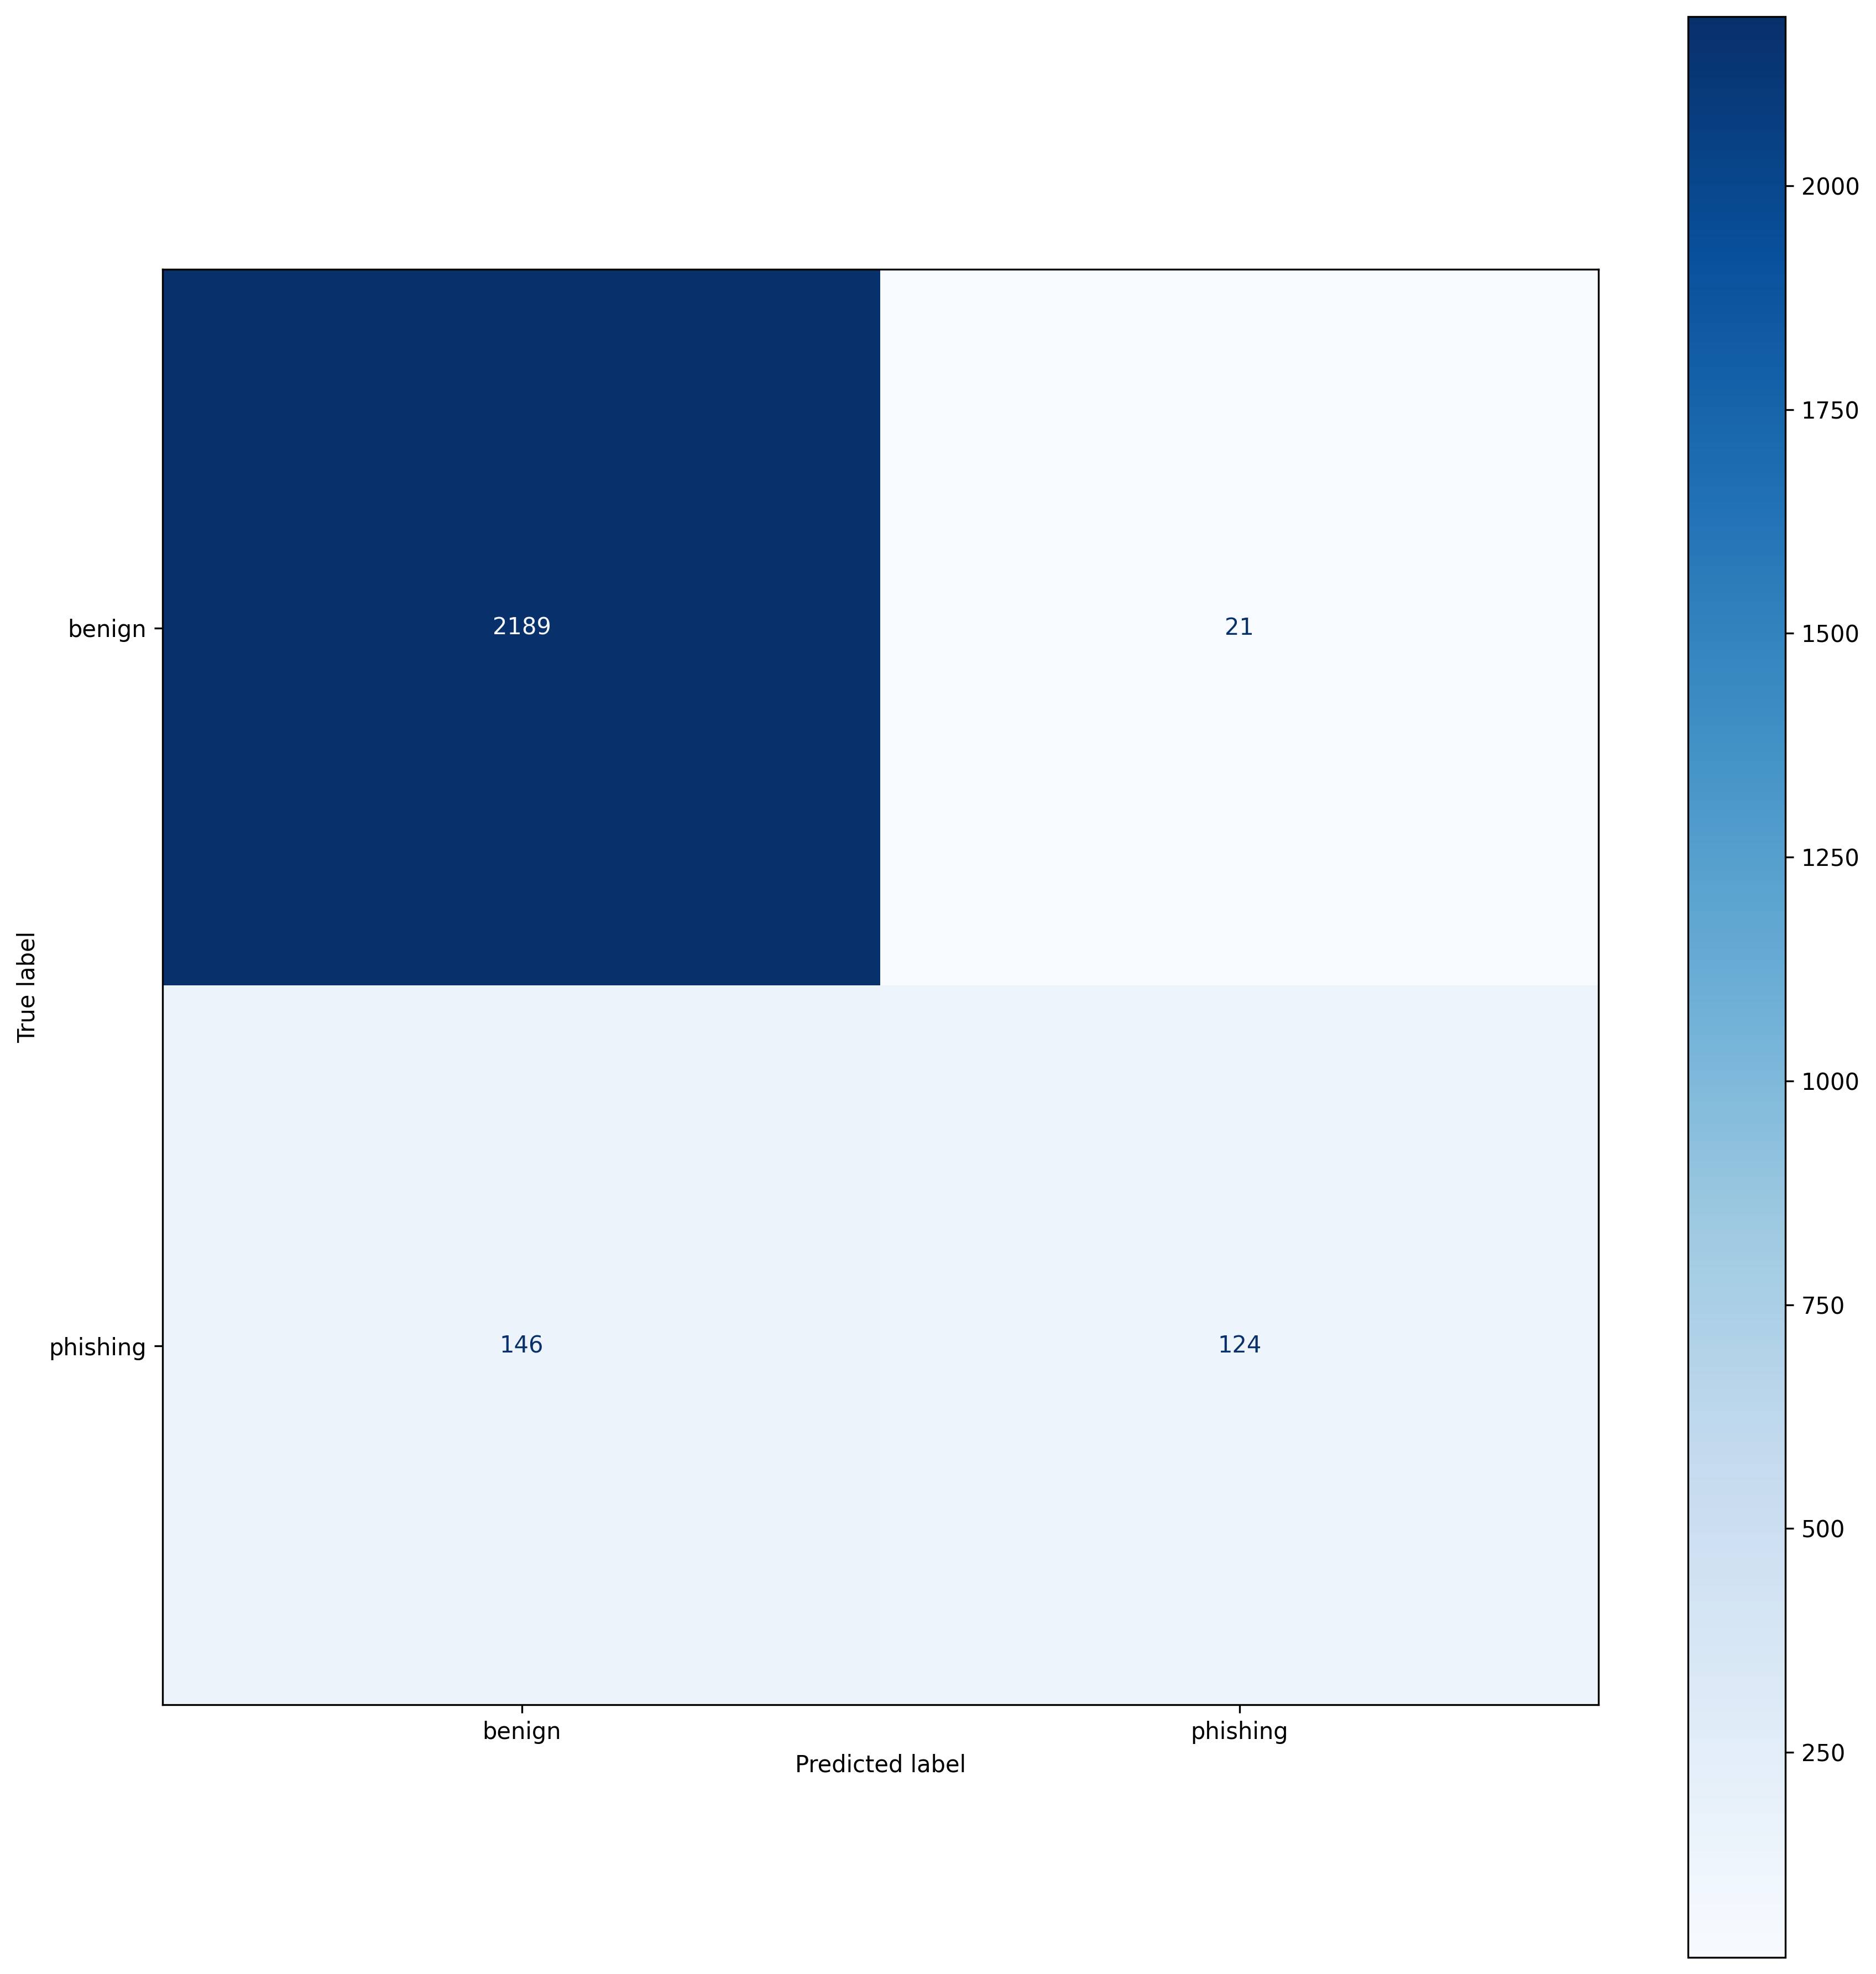

Misclassified domains: ['3793svxn.computer-mod-s.tech', '0162xygl.computer-mod-s.tech', 'steamproxy-hk.imbastar.com', 'www.accouappel.accoutenness.com', 'zurvan-24b-03.top', 'fodi.caijimoyu.eu.org', '1456ubmz.computer-mod-s.tech', '0fd.me', 'livewalletconnect.blogspot.co.il', '9172mzgd.computer-mod-s.tech', 'sjsabb.com', 'spedupcontr0l.github.io', 'a.a1d4ef5d.shop', 'hp18.pages.dev', 'www.streamblasters.fans', '3653.mk', 'reviewholdreviewho.wixsite.com', 'www.magicbath.co.in', 'v2cf01.pages.dev', 'a.eiuyhrhfodj0d11.shop', 'imken.pro', 'liyanchen.pages.dev', 'www.rdmbox.com', 'hty-ce3.pages.dev', '2688tsay.computer-mod-s.tech', 'marutiminchem.com', 'heoo2.511110.xyz', 'f002.backblazeb2.com', 'arbearssgrounds.wixsite.com', 'cf.bmzk.link', 'greenanymorewaytogo.florece4.workers.dev', 'fuorifrigo.com', 'telegprxm.work', 'namaskarmahra.com', 'zdy.yong96.link', 'account-monetization-violation.vercel.app', 'a6-d9r.pages.dev', 'mswap.bbd.sh', 'wuyier102.pxrocgr.workers.dev', 'securitycheckios.c

In [102]:
import pyarrow.parquet as pq
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib
import shap
from pandas.core.dtypes import common as com
import numpy as np

def cast_timestamp(df: pd.DataFrame):
    """
    Cast timestamp fields to seconds since epoch.
    """
    for col in df.columns:
        if com.is_timedelta64_dtype(df[col]):
            df[col] = df[col].dt.total_seconds()  # This converts timedelta to float (seconds)
        elif com.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].astype(np.int64) // 10**9  # Converts datetime64 to Unix timestamp (seconds)
    return df

# Load the validation dataset
validation_dataset_filename = '../testdata/validation_phishing.parquet'
df_validation = pq.read_table(validation_dataset_filename).to_pandas()

# Cast timestamps and handle NaNs
df_validation = cast_timestamp(df_validation)
df_validation.fillna(-1, inplace=True)

# Remove disqualified columns
for column in disqualified_columns:
    if column in df_validation.columns:
        df_validation.drop(column, axis=1, inplace=True)

# Map the labels
df_validation['label'] = df_validation['label'].map({'benign': 0, 'phishing': 1})

# Extract features and labels
X_val = df_validation.drop(['label', 'domain_name'], axis=1)
y_val = df_validation['label']

# Load the trained model
model = joblib.load('models/' + model_name + '.joblib')

# Make predictions
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_val, y_pred)
weighted_accuracy = (accuracy_score(y_val[y_val == 0], y_pred[y_val == 0]) + accuracy_score(y_val[y_val == 1], y_pred[y_val == 1])) / 2
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
false_positive_rate = fp / (fp + tn)

# Display metrics
print(f'Accuracy: {accuracy}')
print(f'Weighted Accuracy: {weighted_accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'False Positive Rate: {false_positive_rate}')

# Display confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'phishing'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Identify misclassified domain names
misclassified = df_validation[y_val != y_pred]
misclassified_domains = misclassified['domain_name'].tolist()
print(f'Misclassified domains: {misclassified_domains}')

In [13]:
import shap

force_plot_examples = False

def display_shap_for_misclassified(model, misclassified, top_n=10):
    # Select the first N misclassified domains
    misclassified_subset = misclassified.head(top_n)

    # Extract features for the misclassified subset
    X_misclassified = misclassified_subset.drop(['label', 'domain_name'], axis=1)

    # Initialize SHAP explainer
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_misclassified)

    # Plot SHAP values for the misclassified domains
    for i in range(len(misclassified_subset)):
        domain_name = misclassified_subset.iloc[i]['domain_name']
        print(f'Domain: {domain_name}')
        shap.initjs()
        shap.force_plot(explainer.expected_value, shap_values[i], X_misclassified.iloc[i], matplotlib=True)

if force_plot_examples:
    # Display SHAP values for the first N misclassified domains
    display_shap_for_misclassified(model, misclassified, top_n=30)


# Advanced tuning - Training on Training portion, Validation on Validation dataset

In [60]:
advanced_tuning = True

if advanced_tuning:
    import pyarrow.parquet as pq
    import pandas as pd
    import numpy as np
    from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit
    from xgboost import XGBClassifier
    import joblib
    from pandas.core.dtypes import common as com
    import matplotlib.pyplot as plt

    # ----------------------
    # Shared helpers
    # ----------------------
    def cast_timestamp(df: pd.DataFrame):
        for col in df.columns:
            if com.is_timedelta64_dtype(df[col]):
                df[col] = df[col].dt.total_seconds()
            elif com.is_datetime64_any_dtype(df[col]):
                df[col] = df[col].astype(np.int64) // 10**9
        return df

    # ----------------------
    # 1) Rebuild TRAIN split deterministically
    # ----------------------
    # Same as your training pipeline
    benign_dataset_filenames = [
        '../feature-extraction/floor/benign_2312.parquet',
        '../feature-extraction/floor/umbrella_benign_FINISHED.parquet'
    ]
    malicious_dataset_filenames = [
        '../feature-extraction/floor/phishing_2406_strict.parquet',
    ]
    benign_label = "benign"
    malicious_label = "phishing"
    class_map = {benign_label: 0, malicious_label: 1}

    # Load schema from first malicious file (as you do)
    schema = pq.read_table(malicious_dataset_filenames[0]).schema
    benign_tables = [pq.read_table(f).cast(schema) for f in benign_dataset_filenames]
    malicious_tables = [pq.read_table(f).cast(schema) for f in malicious_dataset_filenames]

    # Your union logic
    import pyarrow as pa
    def union_tables(tables: [pa.Table]) -> pa.Table:
        union_table = tables[0]
        for table in tables[1:]:
            right_not_in_union = union_table.join(
                right_table=table, keys='domain_name', join_type='right anti',
                coalesce_keys=True, use_threads=True
            )
            union_table = pa.concat_tables([union_table, right_not_in_union])
        return union_table

    benign = union_tables(benign_tables)
    malicious = union_tables(malicious_tables)

    df_benign = benign.to_pandas()
    df_malicious = malicious.to_pandas()
    df_benign["label"] = benign_label
    df_malicious["label"] = malicious_label
    df_train_full = pd.concat([df_benign, df_malicious], ignore_index=True)

    # Drop domain_name BEFORE casting, as in your pipeline
    if 'domain_name' in df_train_full.columns:
        df_train_full.drop(columns='domain_name', inplace=True)

    # Cast/Fill
    df_train_full = cast_timestamp(df_train_full)
    df_train_full.fillna(-1, inplace=True)

    # Remove disqualified columns
    for c in disqualified_columns:
        if c in df_train_full.columns:
            df_train_full.drop(columns=c, inplace=True)

    # Build features/labels
    labels = df_train_full['label'].map(class_map).astype(int)
    features = df_train_full.drop(columns=['label'])

    # Split deterministically (use SAME params as earlier training)
    X_train, X_test, Y_train, Y_test = train_test_split(
        features, labels, test_size=0.2, random_state=42, shuffle=True, stratify=labels
    )

    print("Rebuilt training split:",
          "X_train", X_train.shape, "Y_train", len(Y_train),
          "X_test", X_test.shape,   "Y_test", len(Y_test))

    # ----------------------
    # 2) Load VALIDATION and align to training columns
    # ----------------------
    validation_dataset_filename = '../testdata/validation_phishing.parquet'
    df_val = pq.read_table(validation_dataset_filename).to_pandas()

    # Drop disqualified columns (columns only)
    for c in disqualified_columns:
        if c in df_val.columns:
            df_val.drop(columns=c, inplace=True)

    # Cast/Fill
    df_val = cast_timestamp(df_val)
    df_val.fillna(-1, inplace=True)

    # Map labels and keep only mapped
    label_map = {'benign': 0, 'phishing': 1}
    df_val['label_mapped'] = df_val['label'].map(label_map)
    unmapped = df_val['label_mapped'].isna().sum()
    if unmapped:
        # If you expect *only* benign/phishing, fail loudly so you can fix the labels
        raise ValueError(f"Validation has {unmapped} rows with unmapped labels. Check df_val['label'].value_counts().")
    df_val['label_mapped'] = df_val['label_mapped'].astype(int)

    # Build X_val with EXACT training columns
    desired_cols = list(X_train.columns)
    X_val = df_val.drop(columns=['label', 'label_mapped', 'domain_name'], errors='ignore')
    X_val = X_val.reindex(columns=desired_cols, fill_value=-1)
    y_val = df_val['label_mapped'].reset_index(drop=True)

    print("Validation shapes:", X_val.shape, len(y_val))

    # ----------------------
    # 3) Combine + PredefinedSplit
    # ----------------------
    X_combined = pd.concat(
        [X_train.reset_index(drop=True), X_val.reset_index(drop=True)],
        axis=0, ignore_index=True
    )
    y_combined = pd.concat(
        [Y_train.reset_index(drop=True), y_val.reset_index(drop=True)],
        axis=0, ignore_index=True
    )

    assert len(X_combined) == len(y_combined), \
        f"Length mismatch: X={len(X_combined)} vs y={len(y_combined)}"

    test_fold = np.r_[
        -1 * np.ones(len(X_train), dtype=int),  # training rows
         0 * np.ones(len(X_val),   dtype=int)   # validation rows
    ]
    ps = PredefinedSplit(test_fold=test_fold)

    # ----------------------
    # 4) Grid search (fresh estimator)
    # ----------------------
    base_params = {
        "objective": "binary:logistic",
        "tree_method": "gpu_hist",
        "sampling_method": "gradient_based",
        "max_depth": 9,
        "eta": 0.05,
        "min_child_weight": 1,
        "subsample": 0.6,
        "alpha": 0,
        "gamma": 0.05,
        "lambda": 1.7,
        "max_delta_step": 0,
        "grow_policy": "depthwise",
        "max_bin": 512,
        "n_estimators": 160,
        "scale_pos_weight": 0.01,
        "random_state": 42,
    }
    estimator = XGBClassifier(**base_params)

    grid = {
        #'max_depth': [8, 9, 10, 11, 12],
        #'n_estimators': [150, 160,180, 200, 300],
        #"eta": [0.03, 0.04, 0.05, 0.06],
        "lambda": [1.5, 1.6, 1.7, 1.8],
        #"gamma": [0.04, 0.05, 0.06],
        #"min_child_weight": [0, 1, 2, 3],
    }

    gs = GridSearchCV(
        estimator=estimator,
        param_grid=grid,
        cv=ps,
        scoring='f1',
        verbose=3,
        return_train_score=True
    )
    gs.fit(X_combined, y_combined)

    best = gs.best_estimator_
    joblib.dump(best, f'models/{model_name}_best_xgboost.joblib')

    print("Best parameters:", gs.best_params_)
    print("Best score:", gs.best_score_)
    
    scores = (
        pd.DataFrame(gs.cv_results_)
          .reset_index(drop=True)   # ensure IDs 0..N-1
          .round(4)
    )

    
    # Optional: round for nicer viewing
    scores = scores.round(4)


Rebuilt training split: X_train (784599, 166) Y_train 784599 X_test (196150, 166) Y_test 196150
Validation shapes: (2480, 166) 2480
Fitting 1 folds for each of 4 candidates, totalling 4 fits
[CV 1/1] END ....lambda=1.5;, score=(train=0.866, test=0.737) total time=  10.0s
[CV 1/1] END ....lambda=1.6;, score=(train=0.865, test=0.741) total time=  10.1s
[CV 1/1] END ....lambda=1.7;, score=(train=0.864, test=0.741) total time=  10.0s
[CV 1/1] END ....lambda=1.8;, score=(train=0.863, test=0.736) total time=  10.0s
Best parameters: {'lambda': 1.7}
Best score: 0.7410071942446043


In [61]:
def DisplayTuningGraph2(scores, metric="mean_test_score"):
    """
    Plot train/test scores vs integer IDs, annotate *all* points with ID and score.
    Highlight the best test score with a red dot.
    Works regardless of which params were tuned.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # Reset index so IDs go 0..N-1
    s = scores.copy().reset_index(drop=True)
    s["ID"] = np.arange(len(s))

    fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
    ax.plot(s["ID"], s["mean_train_score"], marker="o", label="mean_train_score")
    ax.plot(s["ID"], s[metric],             marker="o", label=metric)

    # Annotate every point with value and ID
    for _, row in s.iterrows():
        ax.annotate(f"{row[metric]:.3f}_ID={row['ID']}",
                    (row["ID"], row[metric]),
                    xytext=(6, 6), textcoords="offset points", fontsize=8)

    # Highlight the best test score (highest value of `metric`)
    best_idx = s[metric].idxmax()
    best_id  = int(s.loc[best_idx, "ID"])
    best_val = float(s.loc[best_idx, metric])
    ax.scatter([best_id], [best_val], color="red", s=120, zorder=5, label="best")

    ax.set_xlabel("ID")
    ax.set_ylabel("score")
    ax.set_xticks(s["ID"])              # ensure x-axis ticks 0..N-1
    ax.set_ylim(0, 1)                    # for F1/accuracy; remove if not desired
    ax.grid(True)
    ax.legend()

    # Print ID → params table (unsorted, natural ID order)
    param_cols = [c for c in s.columns if c.startswith("param_") or c == "n_estimators"]
    extra_cols = [c for c in ["rank_test_score", "mean_fit_time"] if c in s.columns]
    cols_to_show = ["ID"] + param_cols + ["mean_train_score", metric] + extra_cols
    print(s[cols_to_show].to_string(index=False))

    return fig, ax

 ID  param_lambda  mean_train_score  mean_test_score  rank_test_score  mean_fit_time
  0           1.5            0.8659           0.7368                3        10.0020
  1           1.6            0.8654           0.7406                2        10.0319
  2           1.7            0.8645           0.7410                1        10.0128
  3           1.8            0.8628           0.7361                4         9.9592


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lambda,params,split0_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,mean_train_score,std_train_score
0,10.0020,0.0,0.0291,0.0,1.5,{'lambda': 1.5},0.7368,0.7368,0.0,3,0.8659,0.8659,0.0
1,10.0319,0.0,0.0305,0.0,1.6,{'lambda': 1.6},0.7406,0.7406,0.0,2,0.8654,0.8654,0.0
2,10.0128,0.0,0.0293,0.0,1.7,{'lambda': 1.7},0.7410,0.7410,0.0,1,0.8645,0.8645,0.0
3,9.9592,0.0,0.0285,0.0,1.8,{'lambda': 1.8},0.7361,0.7361,0.0,4,0.8628,0.8628,0.0


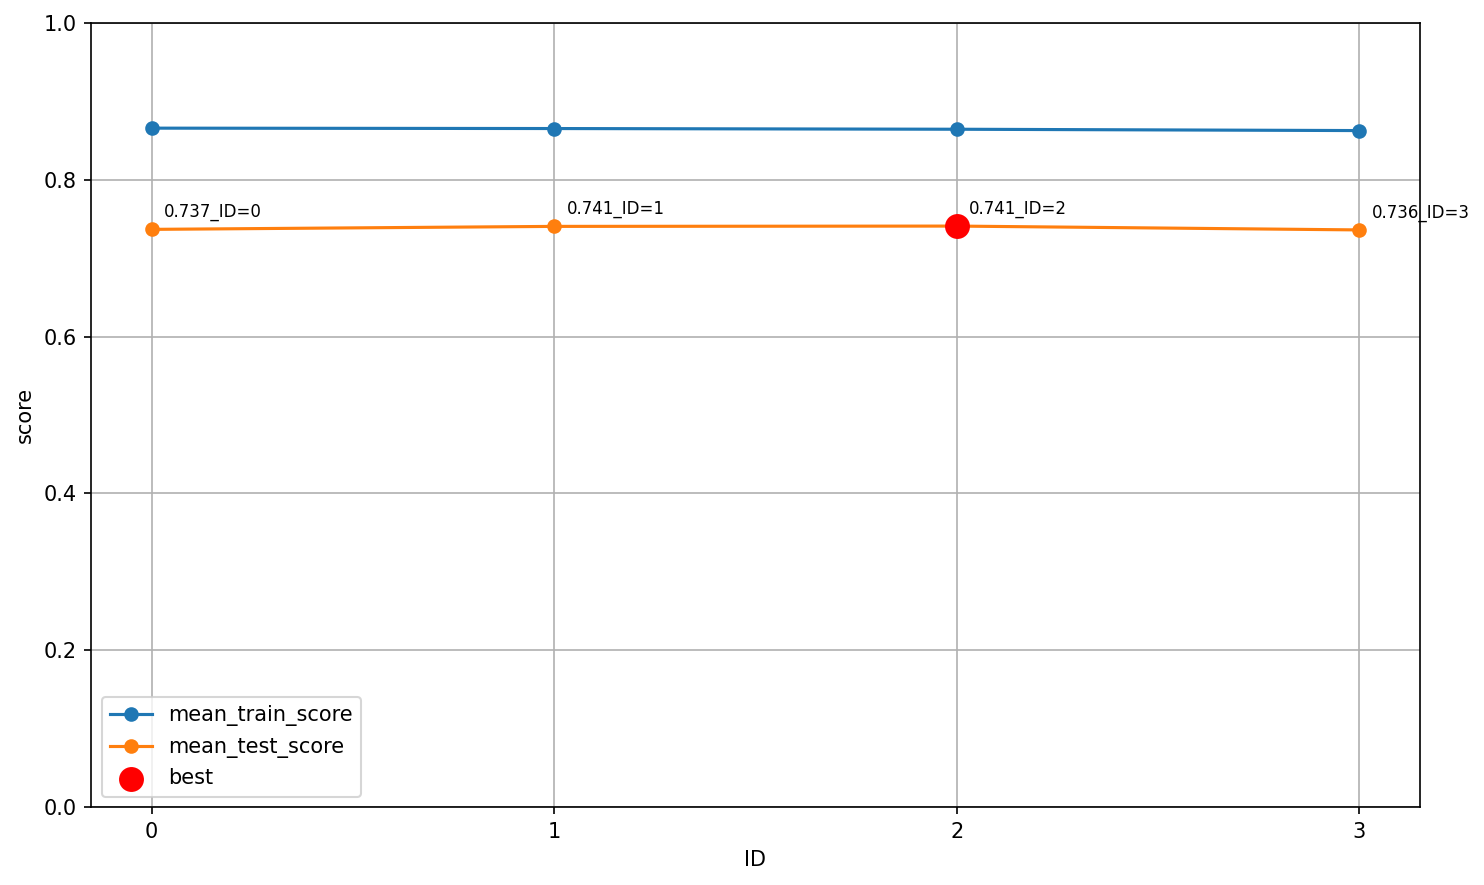

In [62]:
display = ''
if advanced_tuning:
    DisplayTuningGraph2(scores)
    display = scores
display

# FP Debug

In [110]:
#FP DATASET
fp_dataset = '../testdata/xyz.parquet'
correct_label = 'benign'

In [111]:

# ---------- helper functions ----------
def cast_timestamp(df: pd.DataFrame):
    """Cast timestamp fields to seconds since epoch."""
    for col in df.columns:
        if com.is_timedelta64_dtype(df[col]):
            df[col] = df[col].dt.total_seconds()
        elif com.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].astype(np.int64) // 10**9
    return df

def _get_model_feature_names(model):
    try:
        booster = model.get_booster()
        if getattr(booster, "feature_names", None):
            return list(booster.feature_names)
    except Exception:
        pass
    if hasattr(model, "feature_name_"):
        return list(model.feature_name_)
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)
    if hasattr(model, "steps"):
        try:
            return _get_model_feature_names(model.steps[-1][1])
        except Exception:
            pass
    return None

def _align_features(X: pd.DataFrame, required: list, fill_value=-1.0) -> pd.DataFrame:
    X = X.copy()
    if required is None:
        return (X.replace([np.inf, -np.inf], np.nan).fillna(fill_value))
    for f in required:
        if f not in X.columns:
            X[f] = fill_value
    X = X[[f for f in required]]
    X = (X.replace([np.inf, -np.inf], np.nan).fillna(fill_value))
    return X

def display_shap_for_misclassified(model, misclassified_df: pd.DataFrame, top_n=10, positive_class=1, top_k_features=15):
    """Render SHAP force plots for the first N misclassified domains (top-k features only)."""
    if misclassified_df.empty:
        print("No misclassified samples provided.")
        return

    subset = misclassified_df.head(top_n).copy()
    X = subset.drop(columns=[c for c in ['label', 'domain_name'] if c in subset.columns])

    req = _get_model_feature_names(model)
    X = _align_features(X, req, fill_value=-1.0)

    try:
        explainer = shap.TreeExplainer(model)
    except Exception:
        warnings.warn("TreeExplainer failed; using generic shap.Explainer.", RuntimeWarning)
        explainer = shap.Explainer(model, X, feature_names=list(X.columns))

    shap_values = explainer.shap_values(X)

    if isinstance(shap_values, list):
        sv = shap_values[positive_class]
        expected_value = explainer.expected_value[positive_class]
    else:
        sv = shap_values
        expected_value = explainer.expected_value

    shap.initjs()

    for i in range(len(subset)):
        domain = subset.iloc[i]['domain_name'] if 'domain_name' in subset.columns else f"idx {i}"
        print(f"\nDomain: {domain}")

        # pick top-k features by absolute shap value
        vals = sv[i]
        feature_names = X.columns
        top_idx = np.argsort(np.abs(vals))[-top_k_features:]
        top_features = feature_names[top_idx]
        top_vals = vals[top_idx]
        top_sample = X.iloc[i, top_idx]

        # bigger figure
        plt.figure(figsize=(12, 3))
        shap.force_plot(expected_value, top_vals, top_sample, matplotlib=True, show=True)

Mean of empty slice.
invalid value encountered in scalar divide


Accuracy: 0.9652265542676501
Weighted Accuracy: nan
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
False Positive Rate: 0.03477344573234984


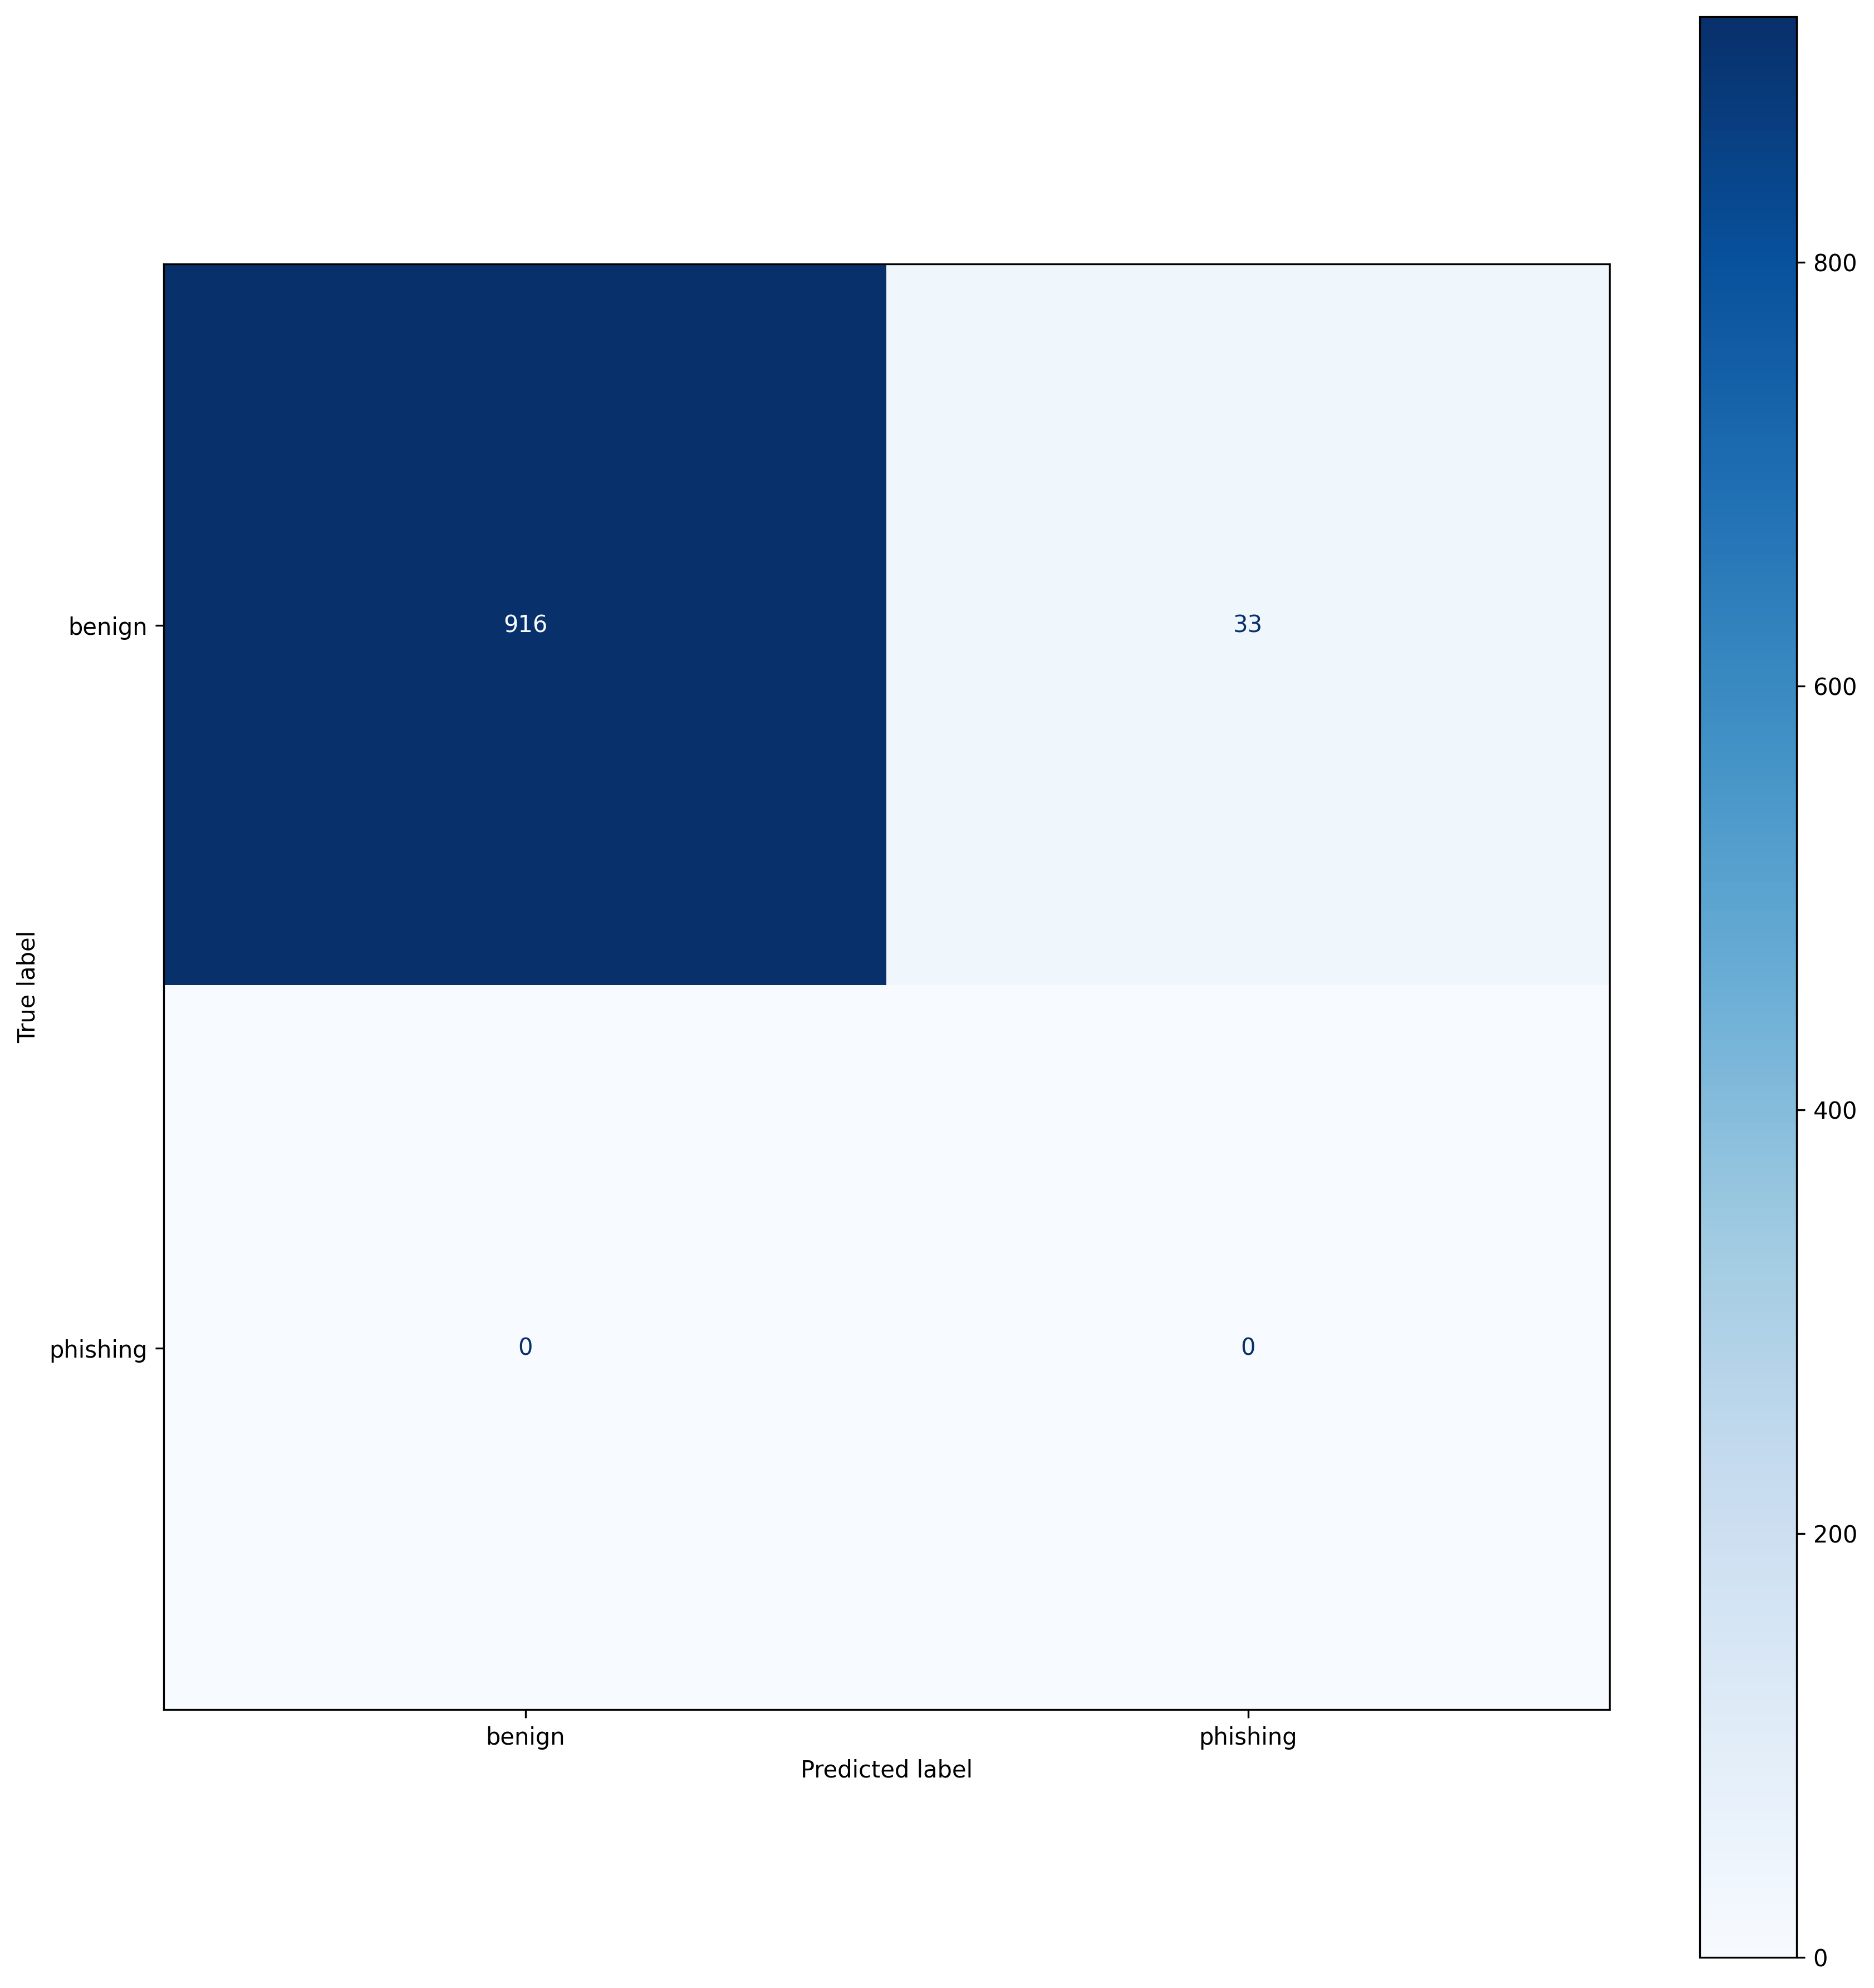

Misclassified domains: ['2588989.com', '95cemara777.com', '99004001.com', 'amarfreelancer.com', 'asharmerac2.com', 'bluesea-croatia.com', 'books-sciknowpub.com', 'bszb309.com', 'charkhasadi.com', 'dhakalmanoj93.com', 'eventwatitoto.com', 'extrememortman.com', 'fixledtv.com', 'genzapikey.com', 'hotrodethanhcong.com', 'jendelaharamain.com', 'joinjb88gdvak.com', 'justwallpapers.com', 'lapulapu-opaopa.com', 'linktong41.com', 'm.thegioteam.com', 'mamakslotamp.com', 'morningoftheworld.com', 'mssfrc.com', 'musicvibepro.com', 'onlinecasino-russia.com', 'ritualsmagic.com', 'ritualsshift.com', 'rttgg3.com', 'saphire-nails.com', 'sillyglobal.xyz', 'trypoweredbyhue.com', 'vavada-vara.com']



Domain: 2588989.com


<Figure size 3600x900 with 0 Axes>

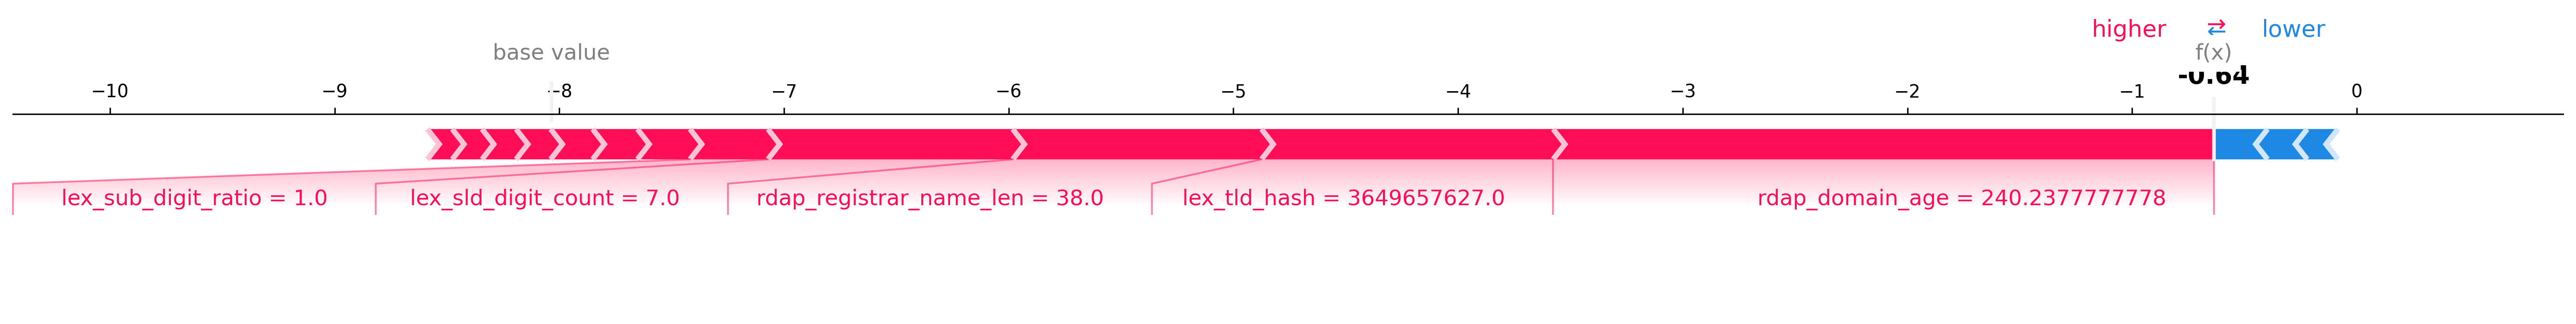


Domain: 95cemara777.com


<Figure size 3600x900 with 0 Axes>

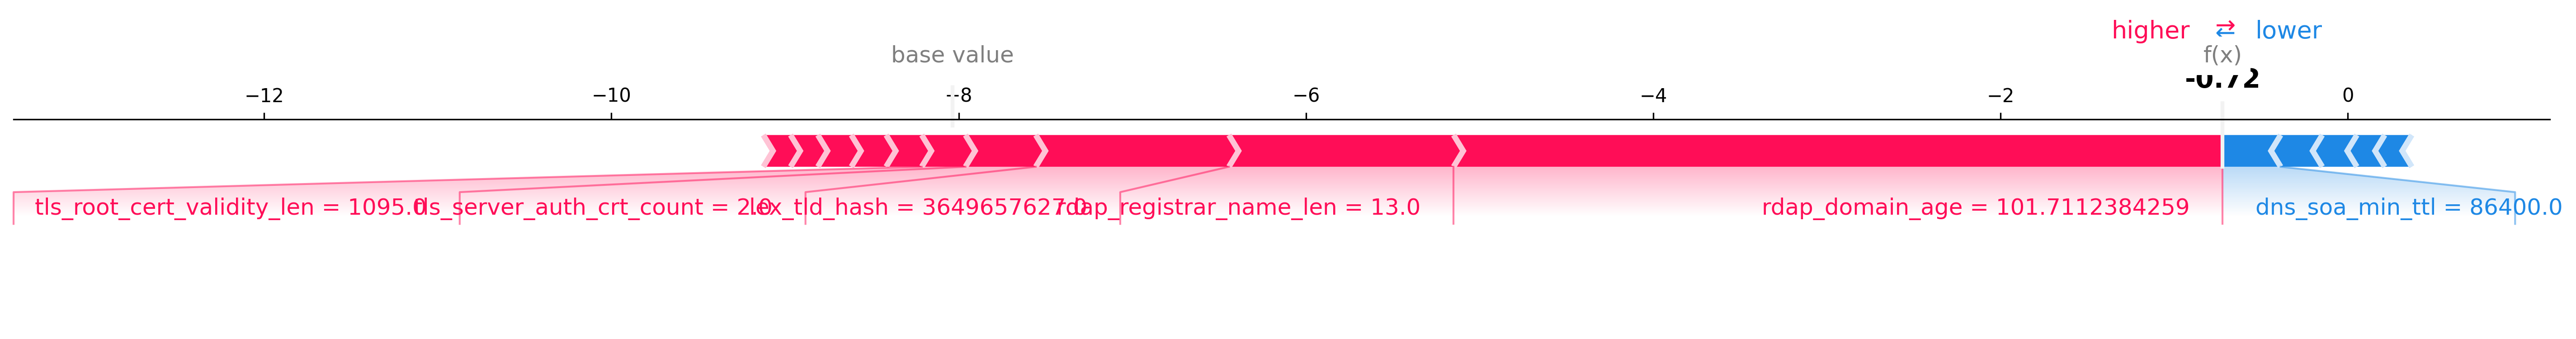


Domain: 99004001.com


<Figure size 3600x900 with 0 Axes>

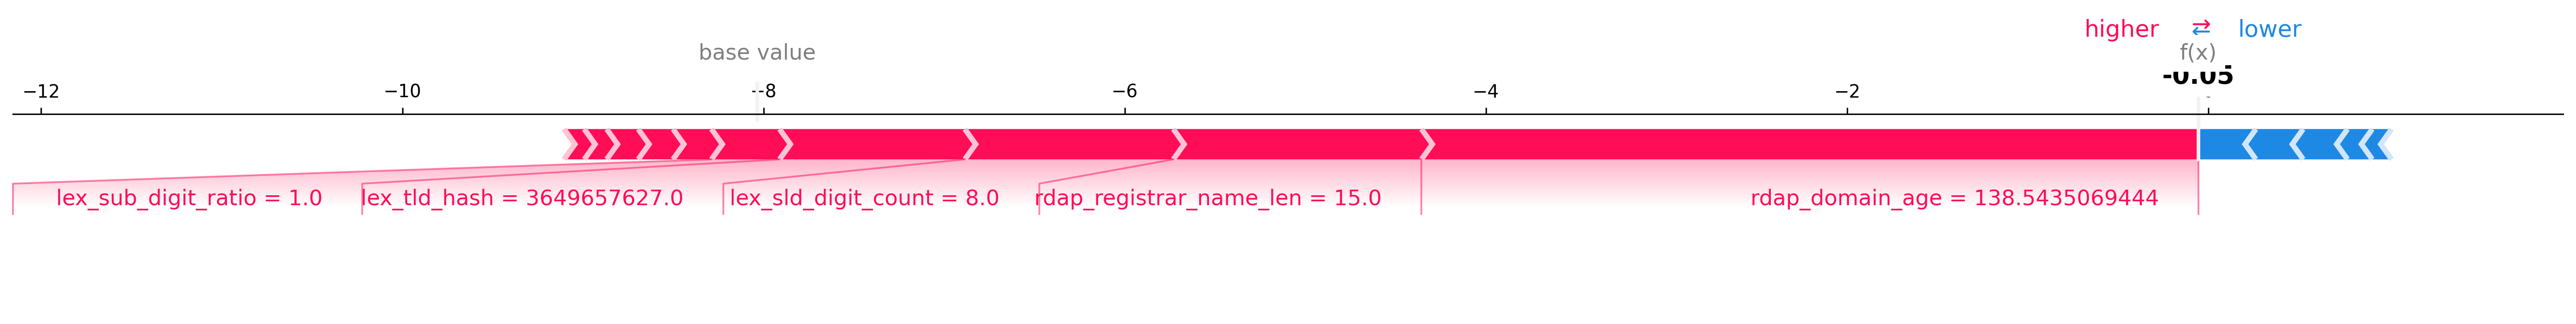


Domain: amarfreelancer.com


<Figure size 3600x900 with 0 Axes>

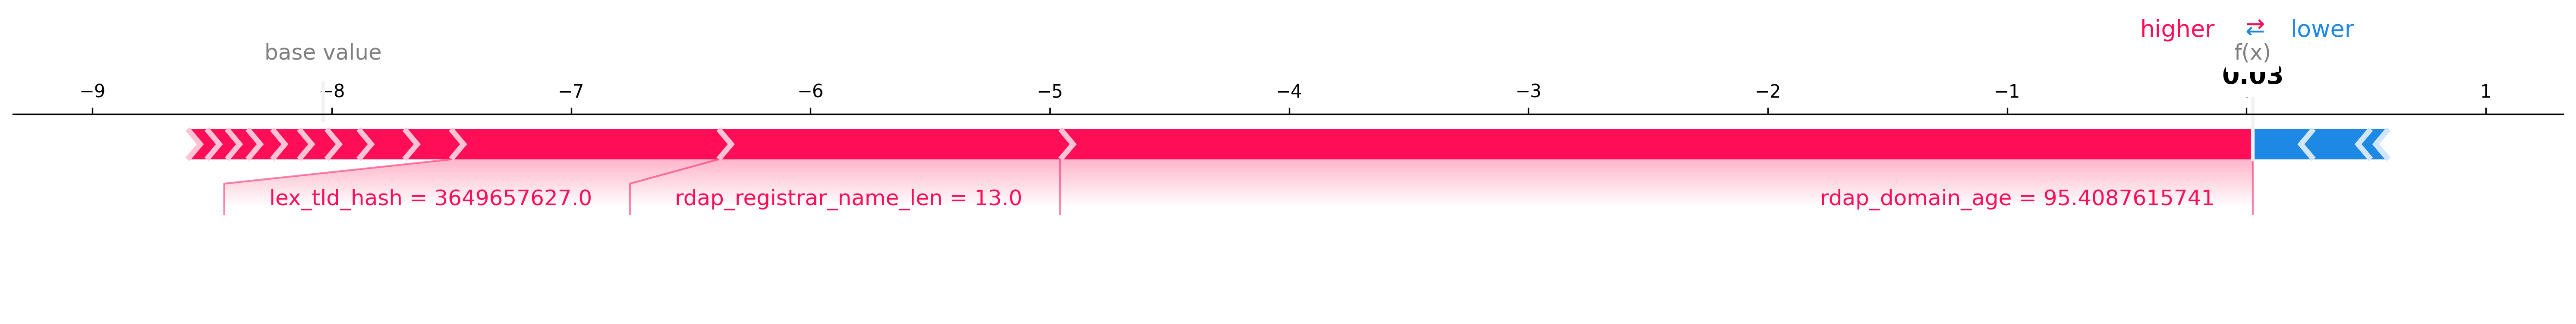


Domain: asharmerac2.com


<Figure size 3600x900 with 0 Axes>

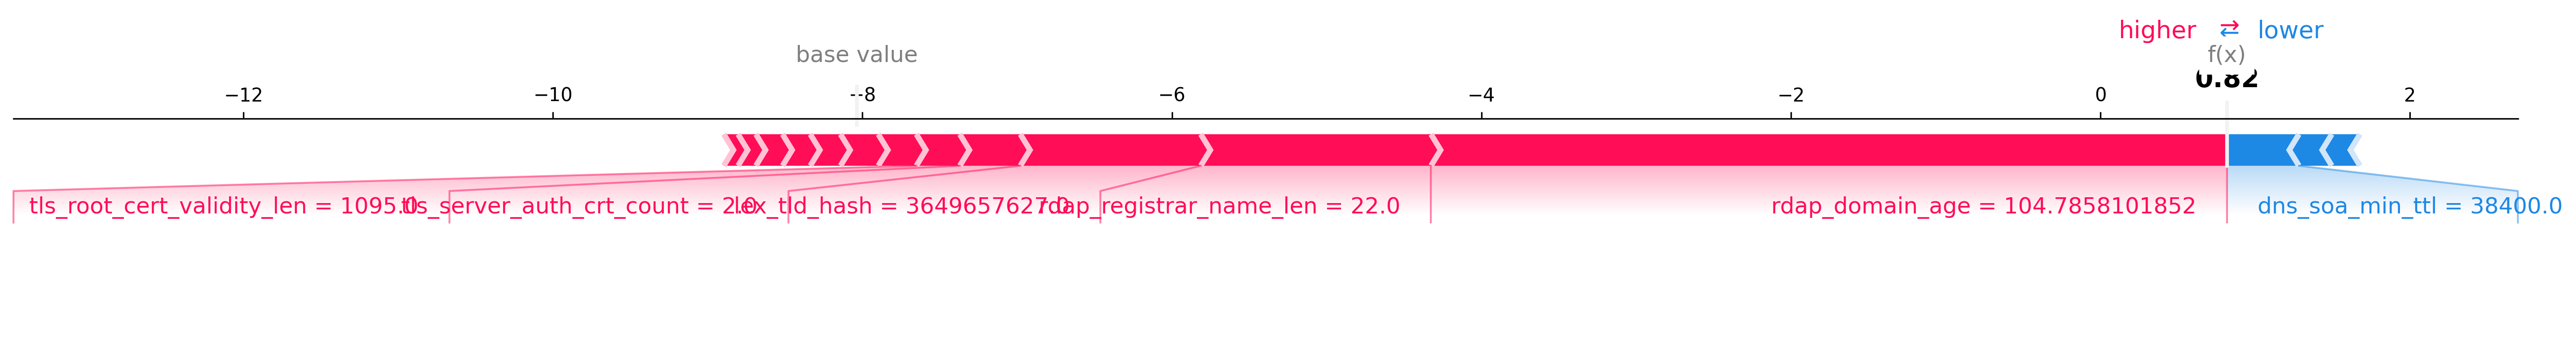


Domain: bluesea-croatia.com


<Figure size 3600x900 with 0 Axes>

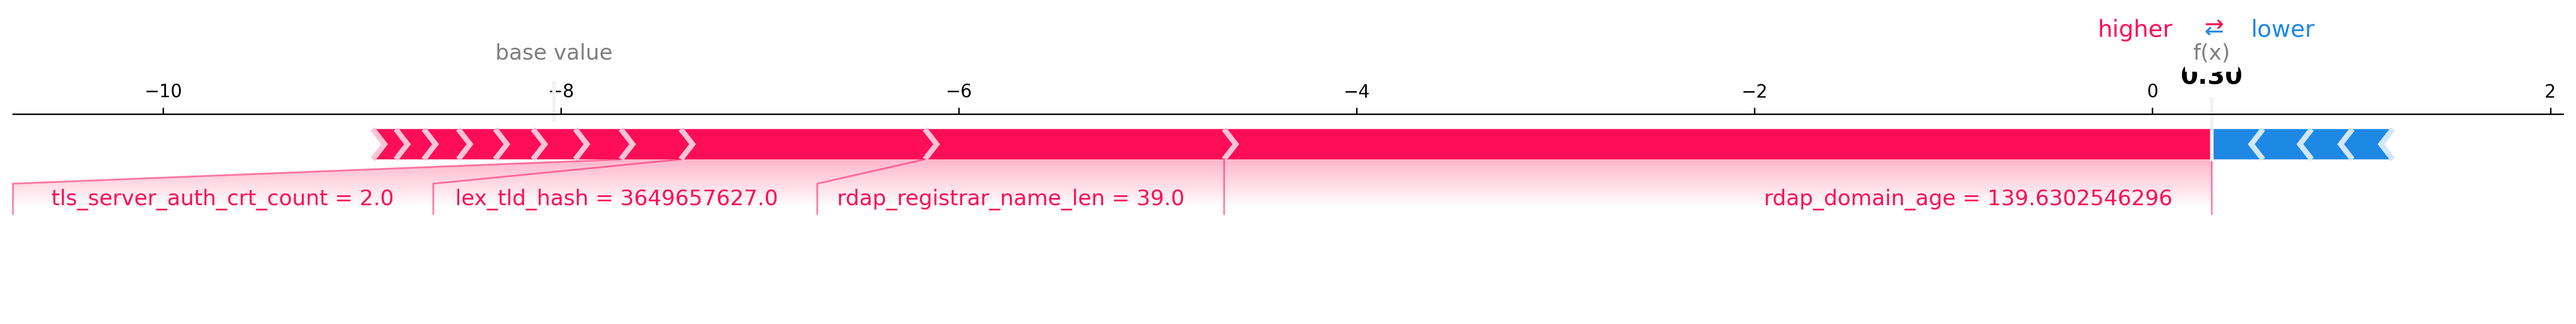


Domain: books-sciknowpub.com


<Figure size 3600x900 with 0 Axes>

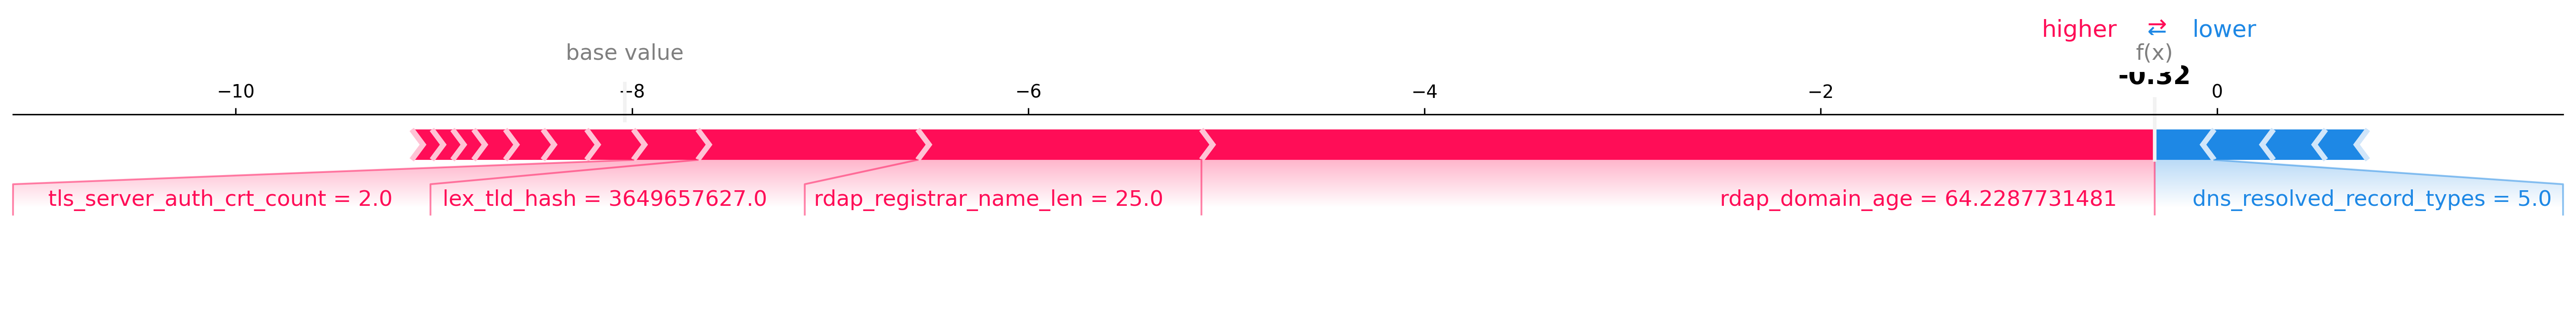


Domain: bszb309.com


<Figure size 3600x900 with 0 Axes>

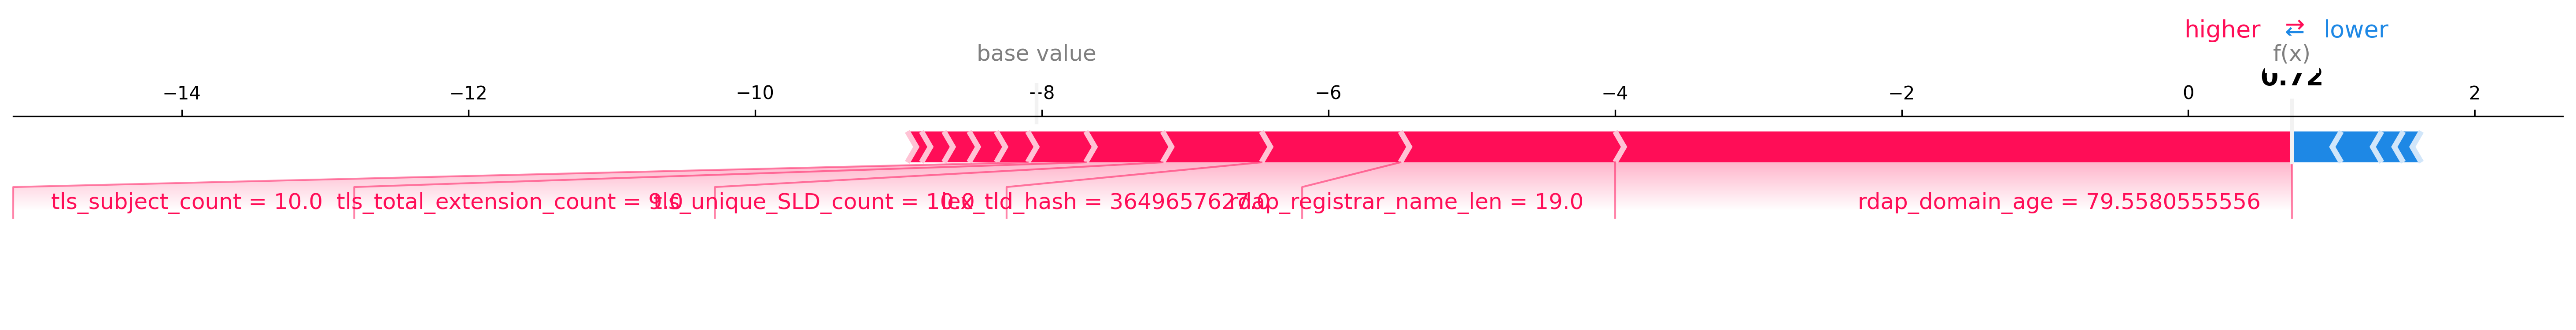


Domain: charkhasadi.com


<Figure size 3600x900 with 0 Axes>

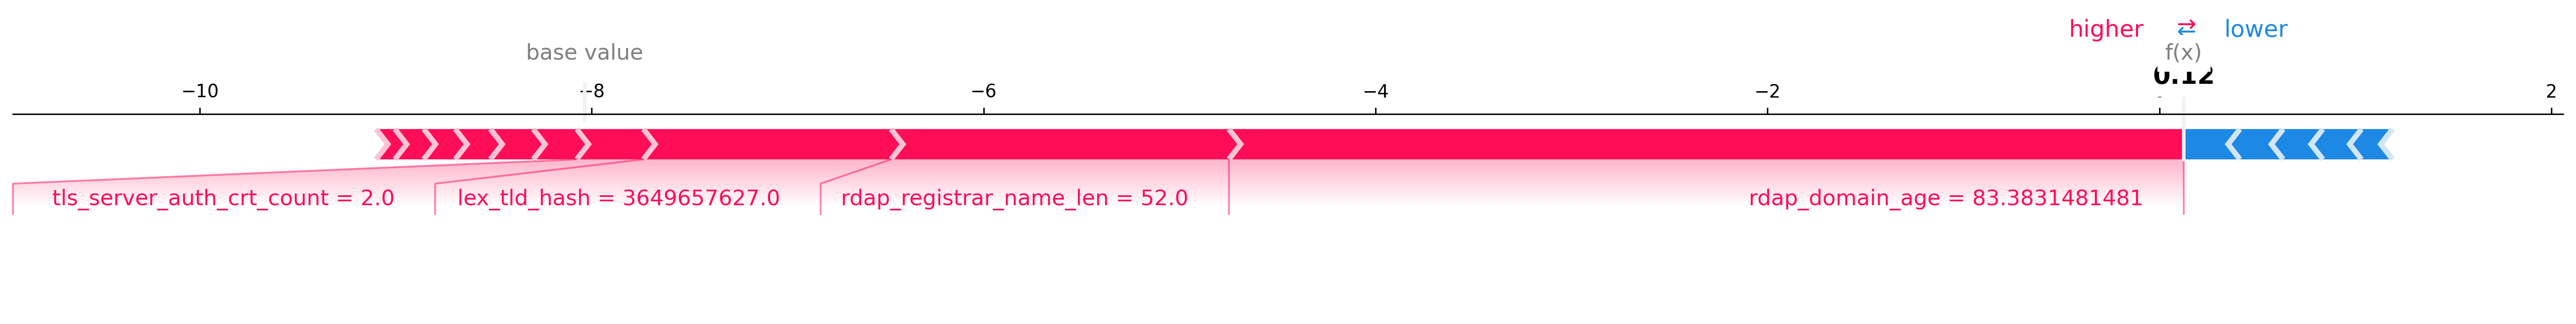


Domain: dhakalmanoj93.com


<Figure size 3600x900 with 0 Axes>

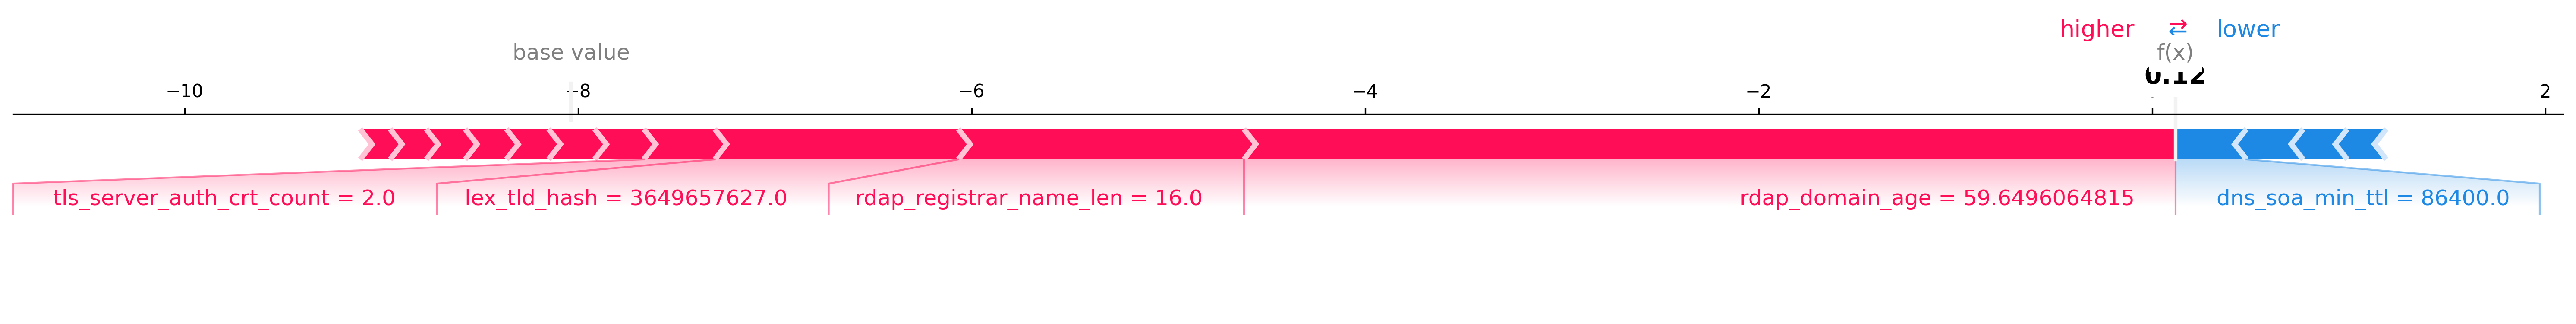


Domain: eventwatitoto.com


<Figure size 3600x900 with 0 Axes>

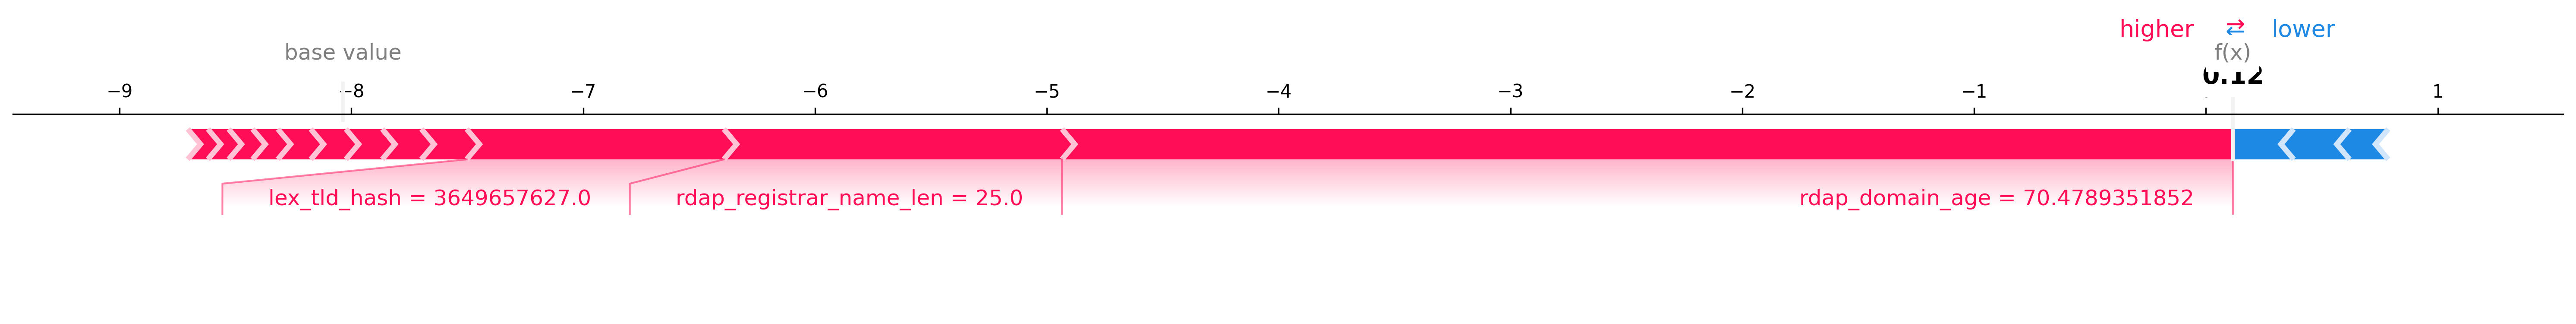


Domain: extrememortman.com


<Figure size 3600x900 with 0 Axes>

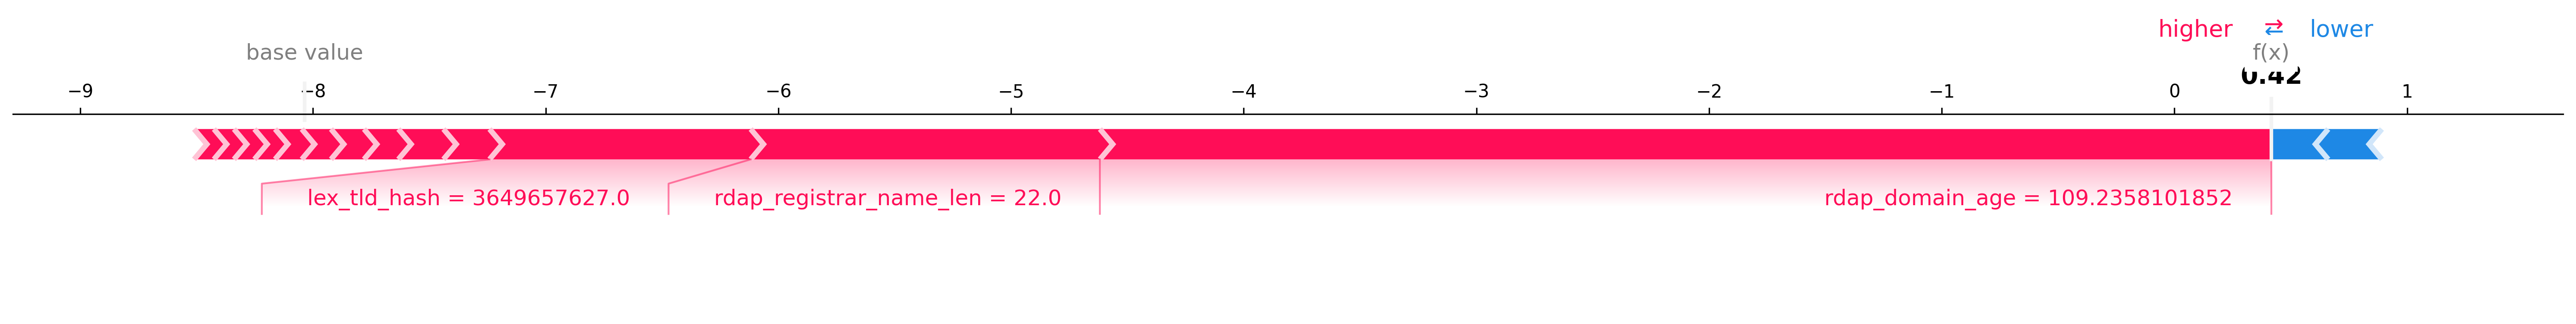


Domain: fixledtv.com


<Figure size 3600x900 with 0 Axes>

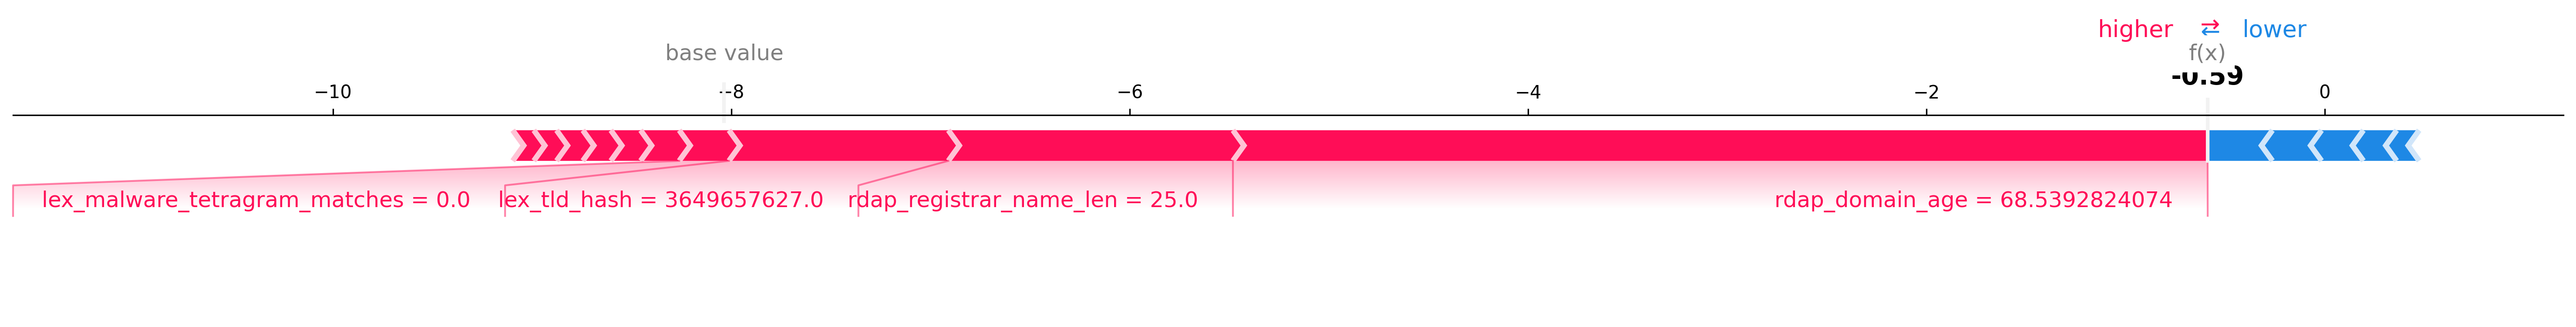


Domain: genzapikey.com


<Figure size 3600x900 with 0 Axes>

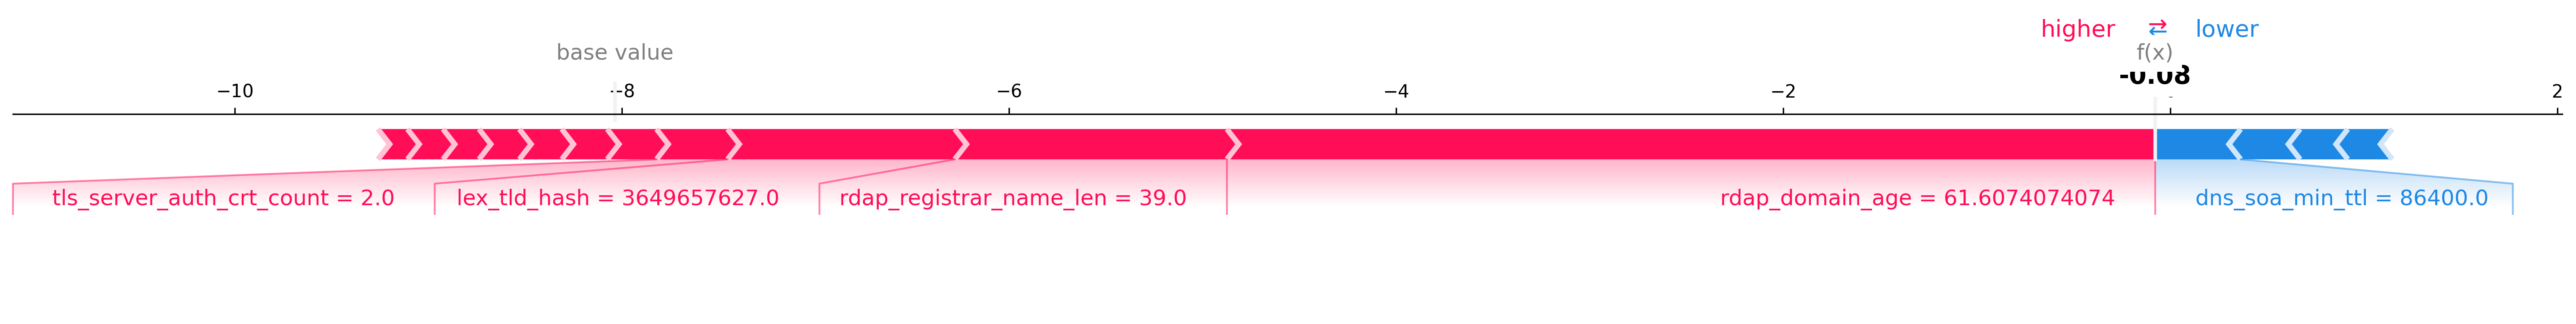


Domain: hotrodethanhcong.com


<Figure size 3600x900 with 0 Axes>

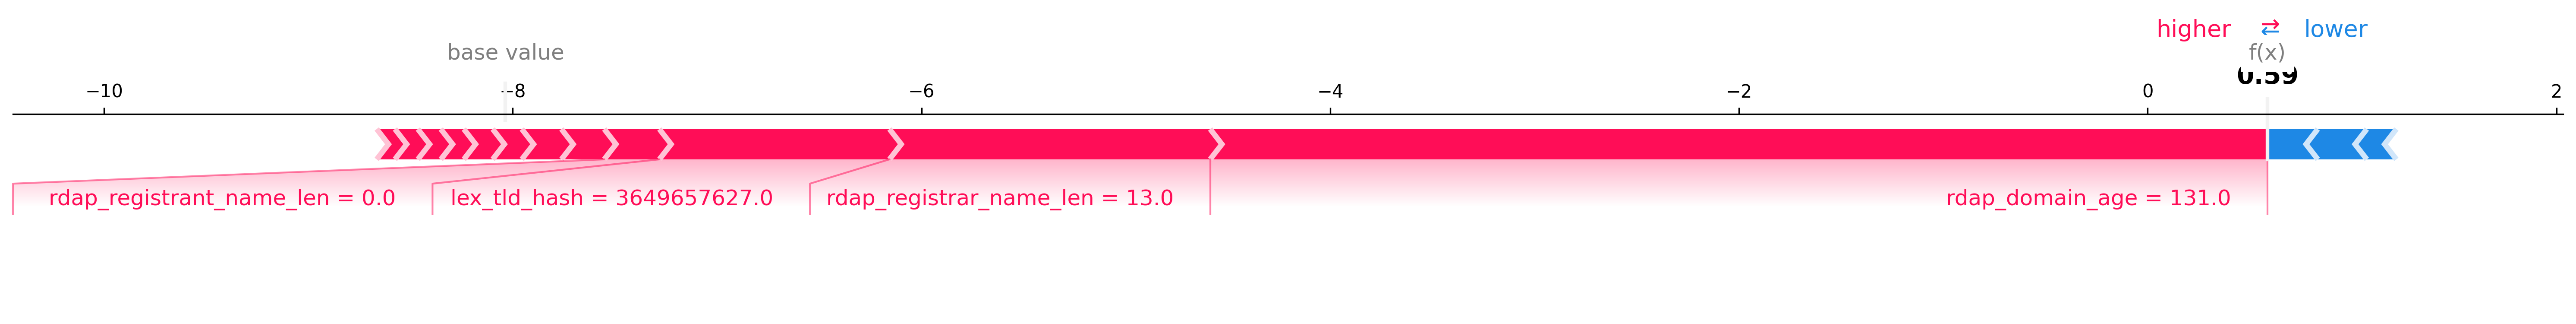


Domain: jendelaharamain.com


<Figure size 3600x900 with 0 Axes>

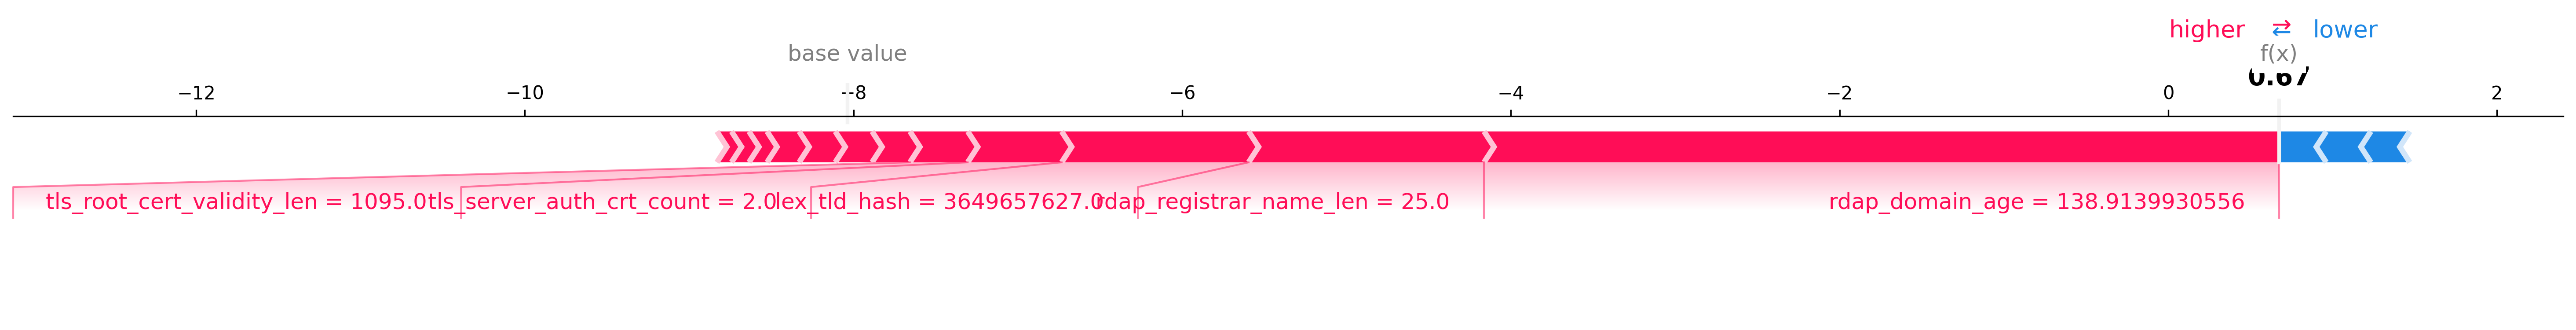


Domain: joinjb88gdvak.com


<Figure size 3600x900 with 0 Axes>

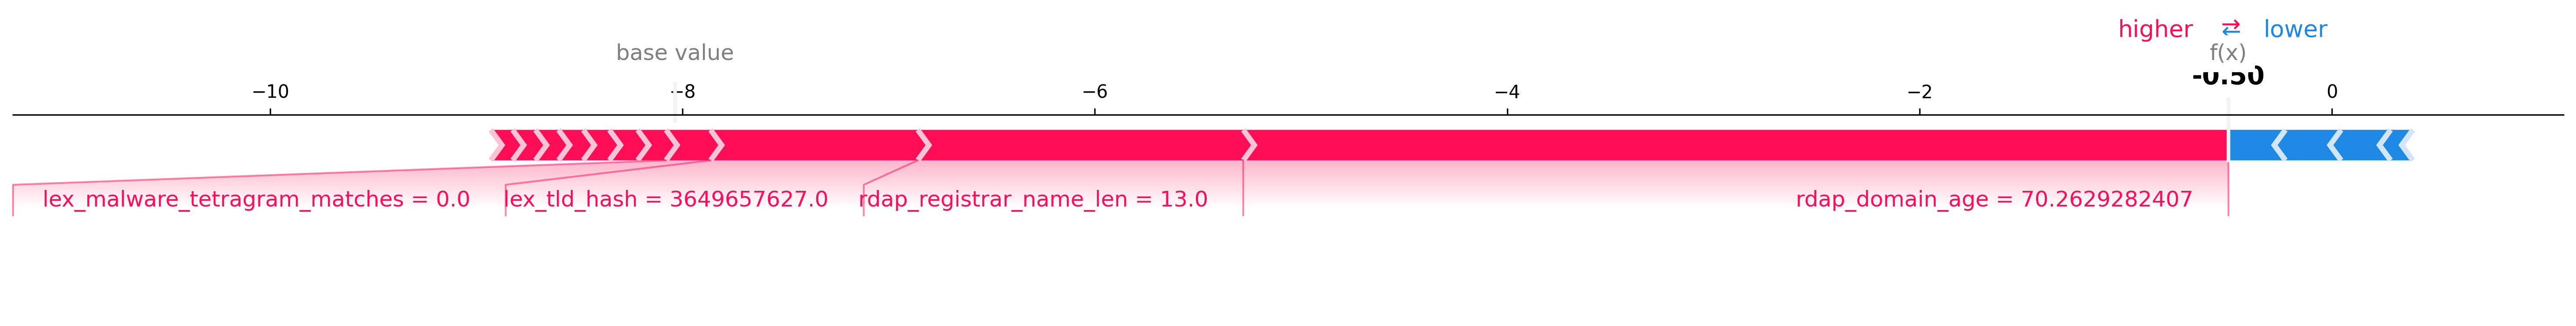


Domain: justwallpapers.com


<Figure size 3600x900 with 0 Axes>

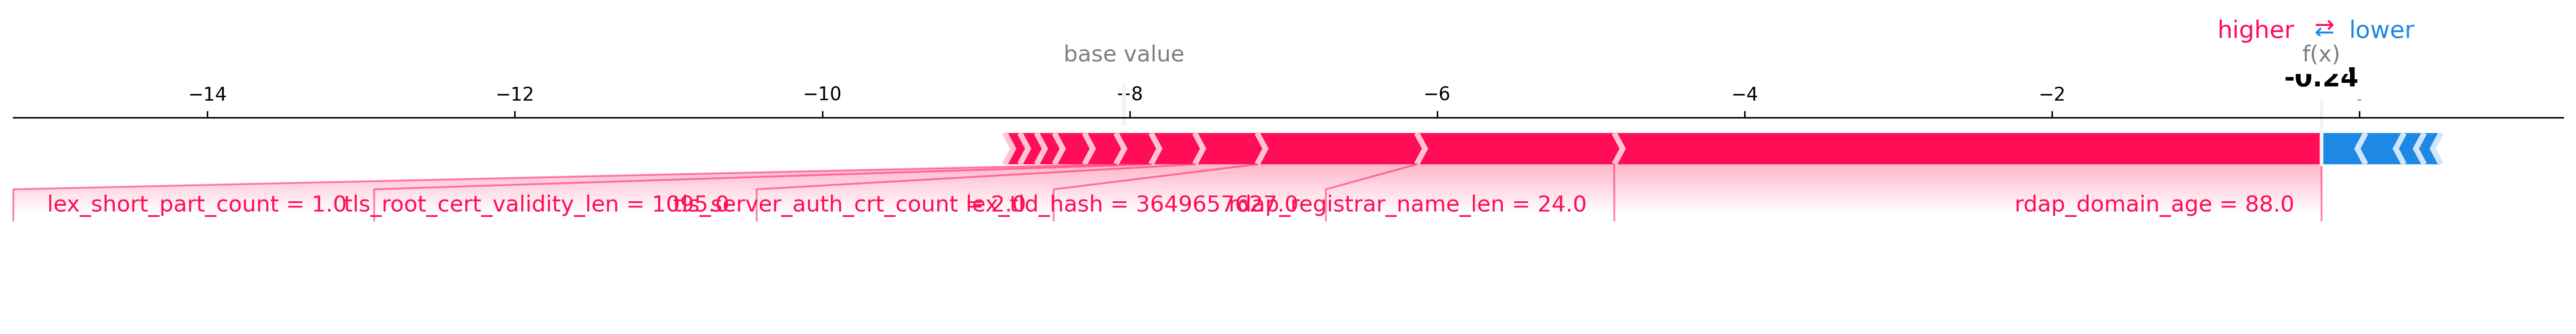


Domain: lapulapu-opaopa.com


<Figure size 3600x900 with 0 Axes>

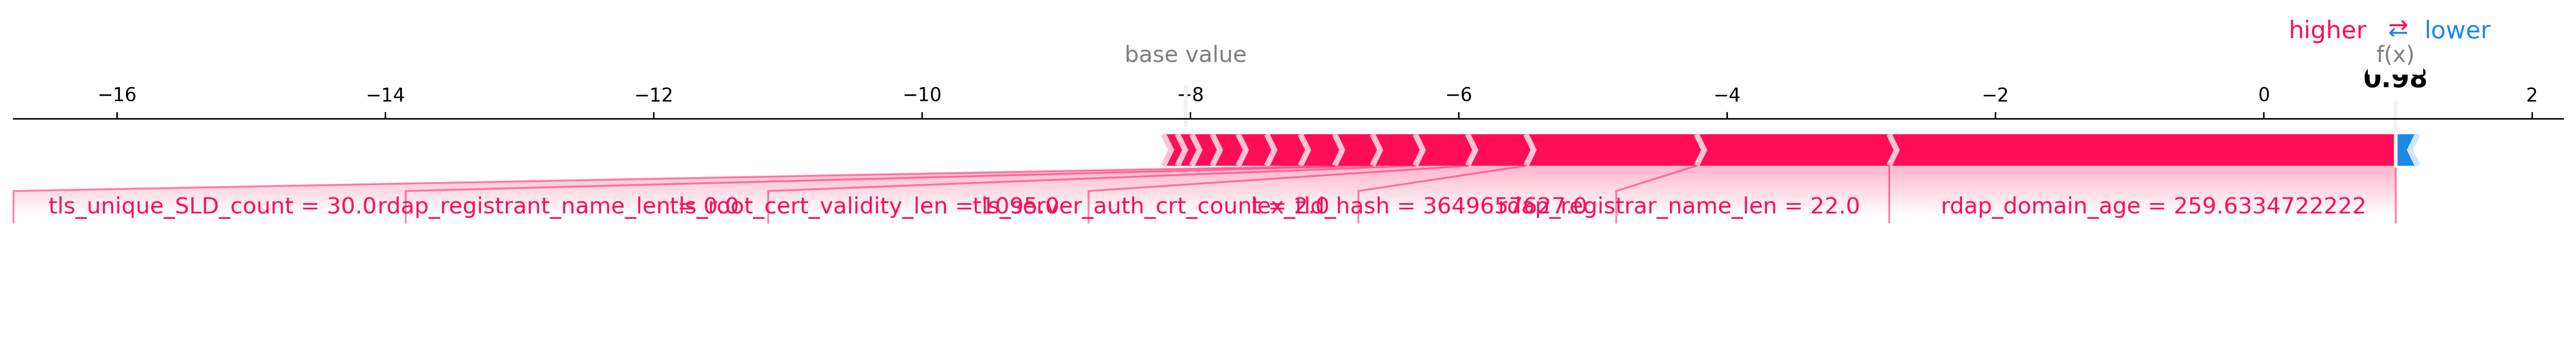


Domain: linktong41.com


<Figure size 3600x900 with 0 Axes>

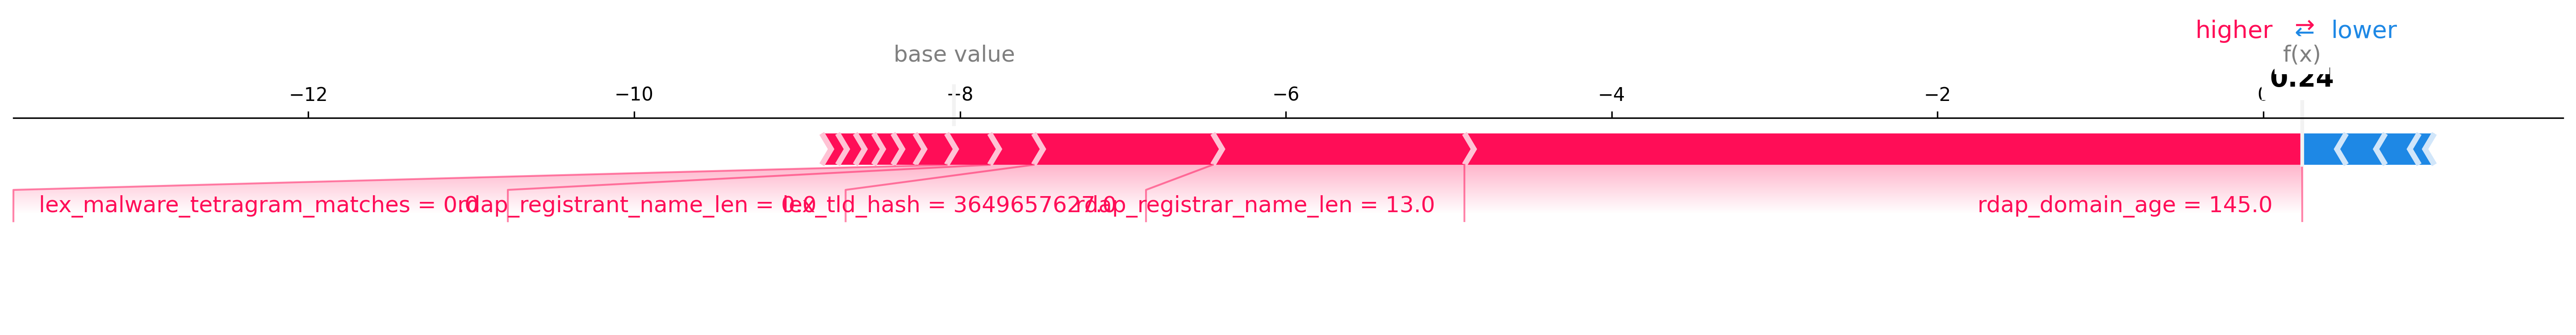

In [109]:
# ---------- main evaluation pipeline ----------
# Load the validation dataset
df_validation = pq.read_table(fp_dataset).to_pandas()
df_validation["label"] = correct_label

# Drop all columns starting with "html_"
df_validation = df_validation.drop(columns=[c for c in df_validation.columns if c.startswith("html_")])

# Cast timestamps and handle NaNs
df_validation = cast_timestamp(df_validation)
df_validation.fillna(-1, inplace=True)

# Remove disqualified columns
for column in disqualified_columns:
    if column in df_validation.columns:
        df_validation.drop(column, axis=1, inplace=True)

# Map the labels
df_validation['label'] = df_validation['label'].map({'benign': 0, 'phishing': 1})

# Extract features and labels
X_val = df_validation.drop(['label', 'domain_name'], axis=1)
y_val = df_validation['label']

# Load the trained model
model = joblib.load('models/' + model_name + '.joblib')

# Align features
required_features = _get_model_feature_names(model)
if required_features is not None:
    X_val = _align_features(X_val, required_features, fill_value=-1.0)
else:
    warnings.warn("Could not determine model feature names automatically; proceeding without reordering.", RuntimeWarning)

# Make predictions
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

# Metrics
accuracy = accuracy_score(y_val, y_pred)
weighted_accuracy = (accuracy_score(y_val[y_val == 0], y_pred[y_val == 0]) +
                     accuracy_score(y_val[y_val == 1], y_pred[y_val == 1])) / 2
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
false_positive_rate = fp / (fp + tn)

print(f'Accuracy: {accuracy}')
print(f'Weighted Accuracy: {weighted_accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print(f'False Positive Rate: {false_positive_rate}')

# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'phishing'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Misclassified domains
misclassified = df_validation[y_val != y_pred]
misclassified_domains = misclassified['domain_name'].tolist()
print(f'Misclassified domains: {misclassified_domains}')

# ---- NEW: SHAP force plots for first 10 misclassified ----
display_shap_for_misclassified(model, misclassified, top_n=20)

In [96]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import warnings

def plot_top_problematic_features(model, misclassified_df: pd.DataFrame, top_k=10, positive_class=1):
    """
    Plot Top-K problematic features for misclassified domains using SHAP.
    'Problematic' = highest average positive SHAP value (push toward class=1) over misclassified samples.

    Assumes your helper functions _get_model_feature_names and _align_features are defined.
    Columns 'label' and 'domain_name' (if present) are excluded from X.
    """

    if misclassified_df.empty:
        print("No misclassified samples to analyze.")
        return

    # Build feature matrix from misclassified rows
    X = misclassified_df.drop(columns=[c for c in ["label", "domain_name"] if c in misclassified_df.columns])

    # Align features to model schema (if known)
    req = _get_model_feature_names(model)
    X = _align_features(X, req, fill_value=-1.0)

    # SHAP explainer (tree models -> TreeExplainer, else generic)
    try:
        explainer = shap.TreeExplainer(model)
    except Exception:
        warnings.warn("TreeExplainer failed; falling back to shap.Explainer.", RuntimeWarning)
        explainer = shap.Explainer(model, X, feature_names=list(X.columns))

    shap_values = explainer.shap_values(X)

    # Handle binary outputs
    if isinstance(shap_values, list):
        sv = np.array(shap_values[positive_class])   # (n_samples, n_features)
    else:
        sv = np.array(shap_values)                   # (n_samples, n_features)

    # We define "problematic" as contribution pushing toward phishing (class 1)
    # -> take only positive SHAP values per feature, average across misclassified samples
    sv_pos = np.where(sv > 0, sv, 0.0)
    mean_pos_contrib = sv_pos.mean(axis=0)  # (n_features,)

    # Find top-K features
    feature_names = np.array(X.columns)
    top_idx = np.argsort(mean_pos_contrib)[-top_k:][::-1]
    top_feats = feature_names[top_idx]
    top_vals  = mean_pos_contrib[top_idx]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.barh(range(len(top_feats)), top_vals)
    plt.yticks(range(len(top_feats)), top_feats)
    plt.gca().invert_yaxis()
    plt.xlabel("Average positive SHAP contribution (push toward phishing)")
    plt.title(f"Top {top_k} problematic features for misclassified domains")
    plt.tight_layout()
    plt.show()

    # Also return a DataFrame for reference / saving
    return pd.DataFrame({"feature": top_feats, "avg_positive_shap": top_vals})

# ---- Usage (after you computed `misclassified` and loaded `model`) ----
# top_df = plot_top_problematic_features(model, misclassified, top_k=10, positive_class=1)
# print(top_df)

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# --- helpers to extract thresholds from tree models ---

def _xgb_feature_thresholds(model, features):
    """Return {feature: [thresholds...]} for XGBoost models."""
    try:
        booster = model.get_booster()
        # trees_to_dataframe is convenient and robust
        df_trees = booster.trees_to_dataframe()
        out = {}
        for feat in features:
            ths = df_trees.loc[df_trees['Feature'] == feat, 'Split'].dropna().astype(float).tolist()
            if ths:
                out[feat] = ths
        return out
    except Exception:
        return {}

def _lgbm_feature_thresholds(model, features):
    """Return {feature: [thresholds...]} for LightGBM models."""
    # accept sklearn.LGBM* or raw Booster
    booster = getattr(model, "booster_", model)
    try:
        dump = booster.dump_model()
        out = {f: [] for f in features}
        for tree in dump.get("tree_info", []):
            # recursive scan of nodes
            stack = [tree.get("tree_structure", {})]
            while stack:
                node = stack.pop()
                if "split_feature" in node:
                    feat_name = node.get("split_feature_name")
                    thr = node.get("threshold")
                    if feat_name in out and thr is not None:
                        try:
                            out[feat_name].append(float(thr))
                        except Exception:
                            pass
                    if "left_child" in node:  stack.append(node["left_child"])
                    if "right_child" in node: stack.append(node["right_child"])
        # drop empties
        out = {k: v for k, v in out.items() if v}
        return out
    except Exception:
        return {}

def extract_feature_thresholds(model, features, agg="median"):
    """
    Extract per-feature decision thresholds from tree splits.
    Returns DataFrame with columns: feature, threshold (aggregated).
    """
    thresholds = {}
    # try XGBoost then LightGBM
    xgb = _xgb_feature_thresholds(model, features)
    lgb = _lgbm_feature_thresholds(model, features)
    # merge (prefer xgb if both present)
    merged = {**lgb, **xgb, **lgb}
    if not merged:
        warnings.warn("Could not extract thresholds from model (non-tree model or unsupported).", RuntimeWarning)
        return pd.DataFrame({"feature": features, "threshold": [np.nan]*len(features)})

    for feat in features:
        vals = merged.get(feat, [])
        if not vals:
            thresholds[feat] = np.nan
        else:
            if   agg == "median": thresholds[feat] = float(np.median(vals))
            elif agg == "mean":  thresholds[feat] = float(np.mean(vals))
            elif agg == "min":   thresholds[feat] = float(np.min(vals))
            elif agg == "max":   thresholds[feat] = float(np.max(vals))
            else:                thresholds[feat] = float(np.median(vals))
    return pd.DataFrame({"feature": list(thresholds.keys()), "threshold": list(thresholds.values())})

# --- your analysis function, now with thresholds overlayed ---

import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# --- canonical analyzer: always returns a DataFrame (with a 'suggestion' column) ---
def analyze_problematic_features(
    model,
    df_validation,
    misclassified,                # can be: DataFrame with misclassified rows, boolean mask, index/ids, or Series
    top_k=10,
    positive_class=1,
    agg_threshold="median",
    return_dict=False,            # set True to get legacy dict shape
):
    """
    Produces a DataFrame with columns:
      ['feature','threshold','phishing_side','mis_mean','correct_mean',
       'mis_on_phishing_side','mis_on_phishing_side_pct','suggestion']

    Compatible with older code:
      - set return_dict=True to get {feature: {...}} dict (with 'suggestion').
      - or call `analysis_to_dict(df_out)` helper below.
    """

    # --- Step 0: normalize `misclassified` into an index and/or DataFrame ---
    if isinstance(misclassified, pd.DataFrame):
        mis_df_all = misclassified.copy()
        mis_idx = mis_df_all.index
    elif isinstance(misclassified, (pd.Series, np.ndarray, list, pd.Index)):
        # boolean mask or index-like
        if isinstance(misclassified, pd.Series) and misclassified.dtype == bool:
            mis_idx = df_validation.index[misclassified.values]
        else:
            mis_idx = pd.Index(misclassified)
        mis_df_all = df_validation.loc[mis_idx]
    else:
        raise TypeError("`misclassified` must be a DataFrame, boolean mask, index/ids, or Series.")

    # --- Step 1: identify top problematic features (uses your existing function) ---
    # Assumes this function exists in your notebook
    top_df = plot_top_problematic_features(model, mis_df_all, top_k=top_k, positive_class=positive_class)
    top_features = top_df["feature"].tolist()

    # --- Step 2: split correctly vs misclassified BENIGN (label==0) ---
    if "label" not in df_validation.columns:
        raise ValueError("df_validation must contain a numeric 'label' column (0/1).")

    benign_all = df_validation[df_validation["label"] == 0]

    # Prefer domain_name if present; else fall back to index diff
    if "domain_name" in df_validation.columns and "domain_name" in mis_df_all.columns:
        benign_misclass = mis_df_all[mis_df_all["label"] == 0]
        benign_correct = benign_all[~benign_all["domain_name"].isin(benign_misclass["domain_name"])]
    else:
        benign_misclass = benign_all.loc[benign_all.index.intersection(mis_idx)]
        benign_correct = benign_all.loc[benign_all.index.difference(mis_idx)]

    # --- Step 3: get model thresholds for these features (your function) ---
    thr_df = extract_feature_thresholds(model, top_features, agg=agg_threshold)
    thr_map = dict(zip(thr_df["feature"], thr_df["threshold"]))

    rows = []
    for feat in top_features:
        if feat not in benign_all.columns:
            warnings.warn(f"Feature '{feat}' not in validation DF; skipping.", RuntimeWarning)
            continue

        vals_corr = pd.to_numeric(benign_correct[feat], errors="coerce").astype(float)
        vals_mis  = pd.to_numeric(benign_misclass[feat], errors="coerce").astype(float)

        mis_mean = float(np.nanmean(vals_mis)) if len(vals_mis) else np.nan
        corr_mean = float(np.nanmean(vals_corr)) if len(vals_corr) else np.nan

        t = thr_map.get(feat, np.nan)

        # Heuristic: if mis_mean > corr_mean, consider ">" the phishing side; otherwise "<="
        phishing_side = ">" if (np.isnan(mis_mean) or np.isnan(corr_mean)) and not np.isnan(t) \
                            else (">" if mis_mean > corr_mean else "<=")

        if np.isnan(t):
            on_phish_side = None
            pct_phish_side = None
        else:
            if phishing_side == ">":
                on_phish_side = int(np.nansum(vals_mis > t))
            else:
                on_phish_side = int(np.nansum(vals_mis <= t))
            denom = int(np.sum(~np.isnan(vals_mis)))
            pct_phish_side = (on_phish_side / denom) if denom else None

        # Build suggestion text (keeps the legacy feel)
        if not np.isnan(t):
            suggestion = (
                f"[{feat}] threshold≈{t:.3g} | phishing side: value {phishing_side} threshold | "
                f"mis_mean={mis_mean:.3g}, correct_mean={corr_mean:.3g} | "
                f"mis on phishing side: {on_phish_side}/{len(vals_mis)} "
                f"({(pct_phish_side or 0)*100:.1f}%)"
            )
        else:
            suggestion = (
                f"[{feat}] No threshold extracted; mis_mean={mis_mean:.3g}, "
                f"correct_mean={corr_mean:.3g}"
            )

        # --- Plot distributions + vertical threshold line ---
        plt.figure(figsize=(8, 4))
        sns.kdeplot(vals_corr.dropna(), label="Correct benign", fill=True, alpha=0.35)
        sns.kdeplot(vals_mis.dropna(),  label="Misclassified benign", fill=True, alpha=0.35)
        if not np.isnan(t):
            plt.axvline(t, linestyle="--", linewidth=2, label=f"Model threshold ≈ {t:.3g}")
            plt.text(t, plt.ylim()[1]*0.9, f"Phishing side: value {phishing_side} threshold",
                     rotation=90, va="top", ha="left")
        plt.title(f"Feature: {feat}")
        plt.legend()
        plt.tight_layout()
        plt.show()

        rows.append({
            "feature": feat,
            "threshold": t,
            "phishing_side": phishing_side,
            "mis_mean": mis_mean,
            "correct_mean": corr_mean,
            "mis_on_phishing_side": on_phish_side,
            "mis_on_phishing_side_pct": float(pct_phish_side) if pct_phish_side is not None else None,
            "suggestion": suggestion,
        })

    df_out = pd.DataFrame(rows, columns=[
        "feature","threshold","phishing_side","mis_mean","correct_mean",
        "mis_on_phishing_side","mis_on_phishing_side_pct","suggestion"
    ])

    if return_dict:
        return analysis_to_dict(df_out)
    return df_out

# --- tiny helpers for full backward-compatibility ---
def analysis_to_dict(analysis_df: pd.DataFrame):
    """Convert the canonical DataFrame into {feature: {...}} (legacy shape)."""
    return (analysis_df.set_index("feature")
                       .apply(lambda r: {k: (None if (isinstance(r[k], float) and np.isnan(r[k])) else r[k])
                                         for k in analysis_df.columns if k != "feature"}, axis=1)
                       .to_dict())

def print_suggestions(analysis):
    """Print suggestions wh



SyntaxError: incomplete input (782059540.py, line 229)

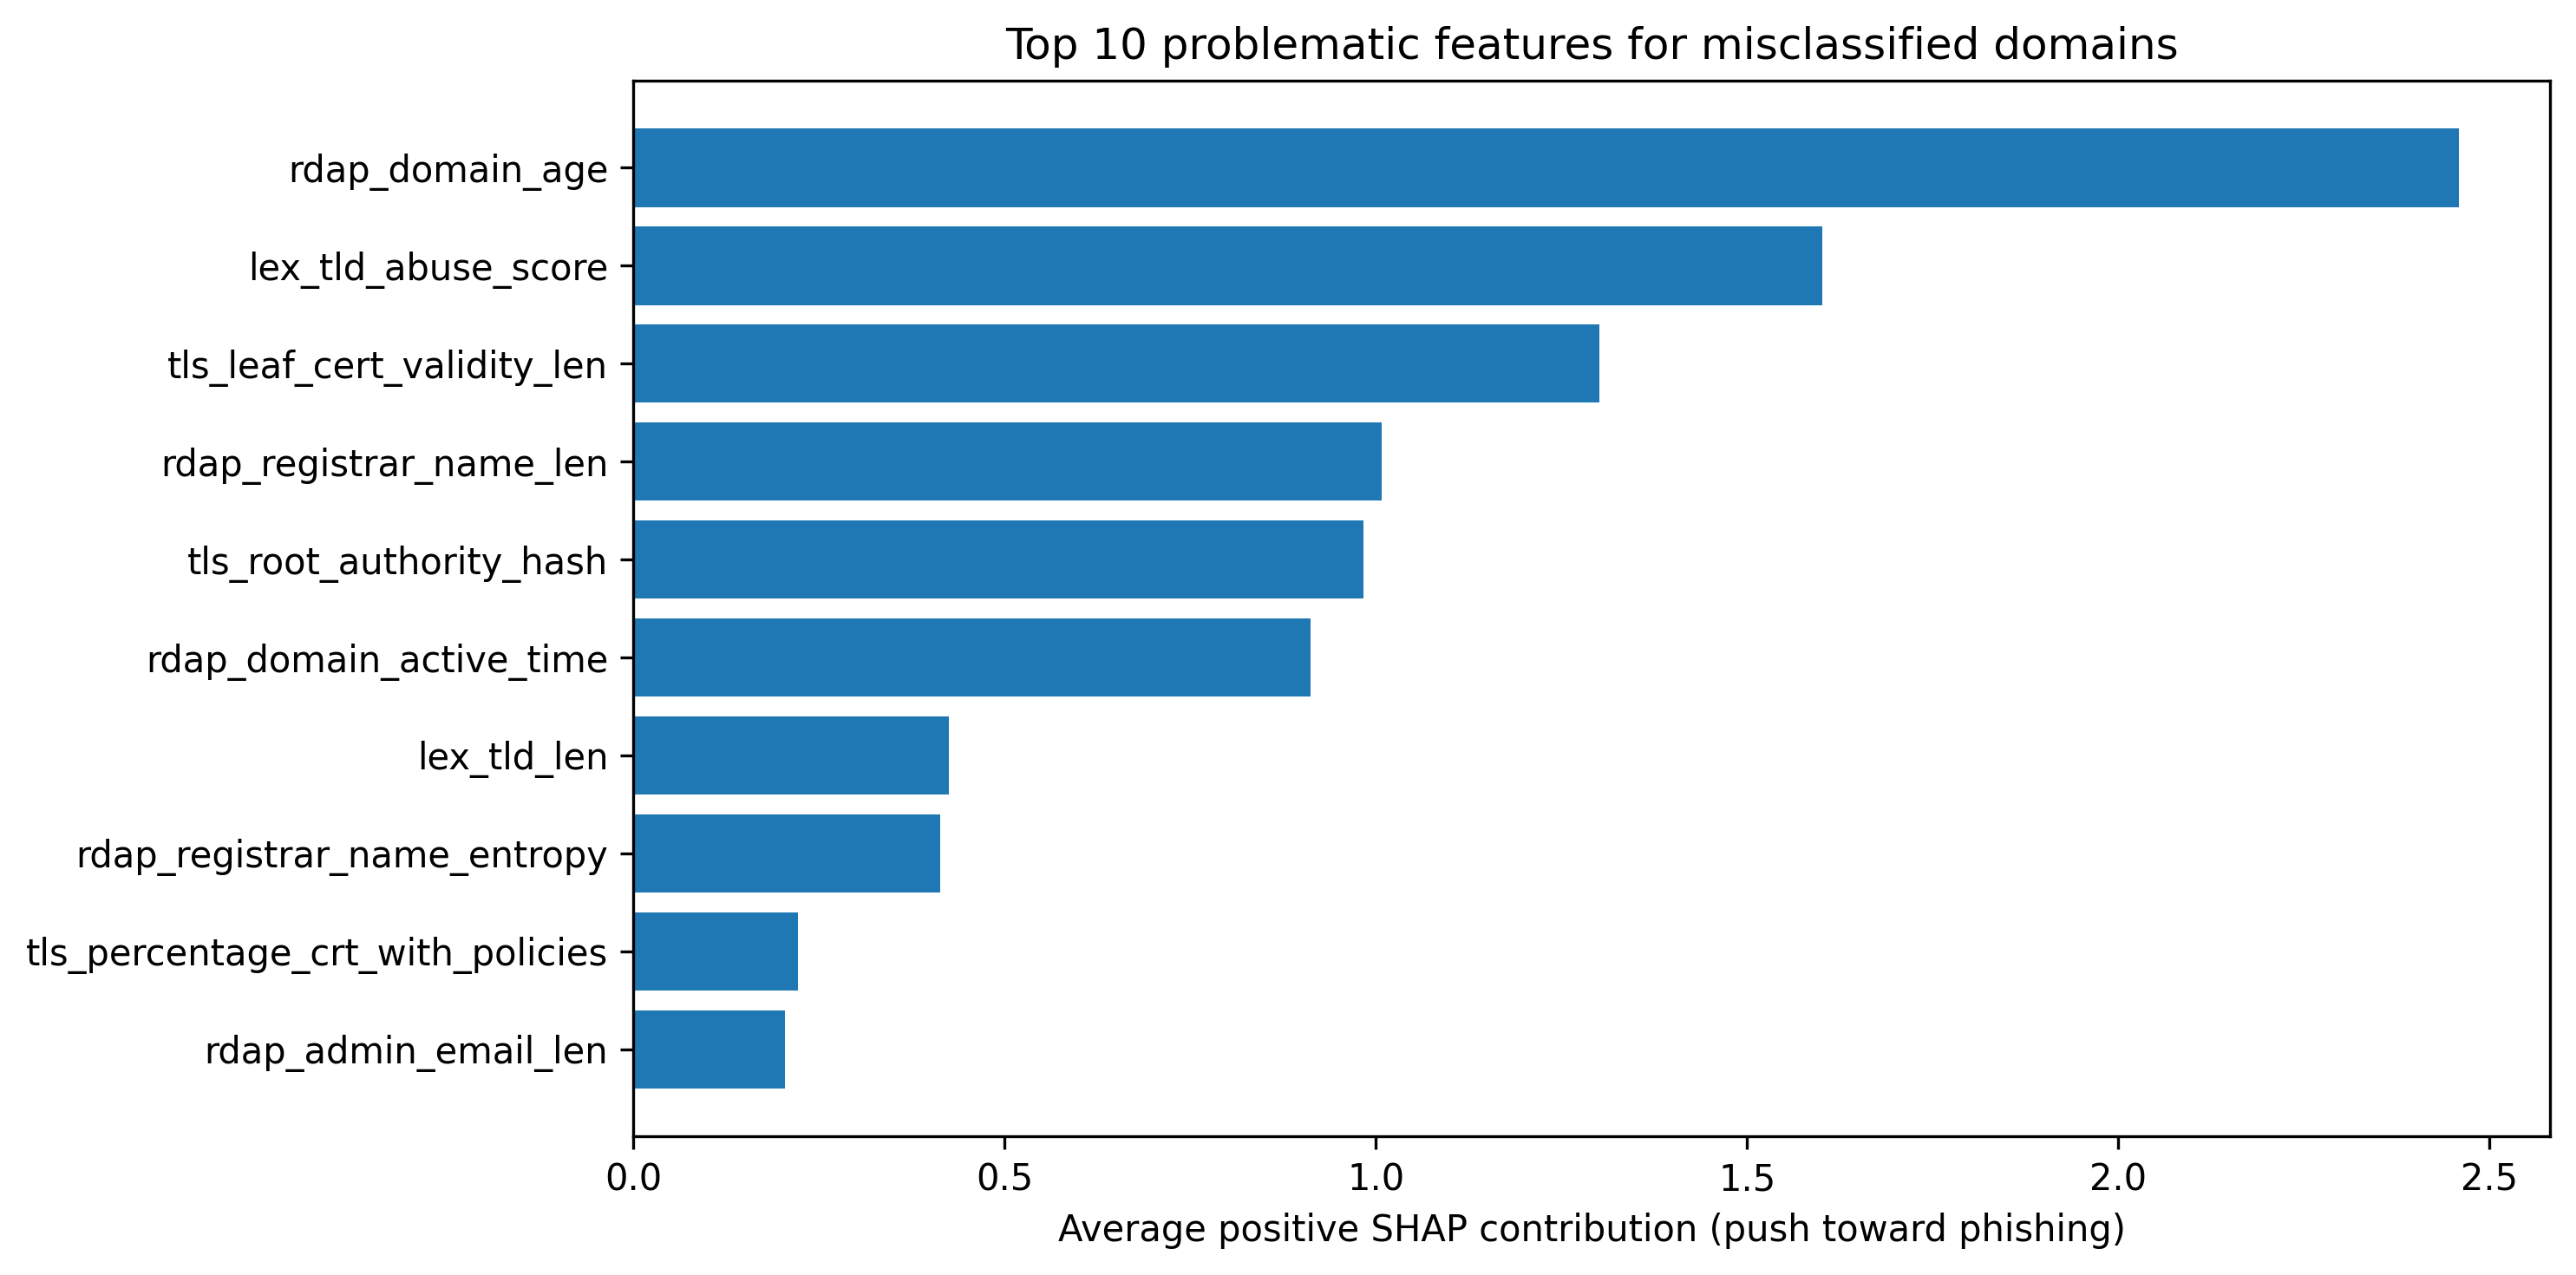

Could not extract thresholds from model (non-tree model or unsupported).


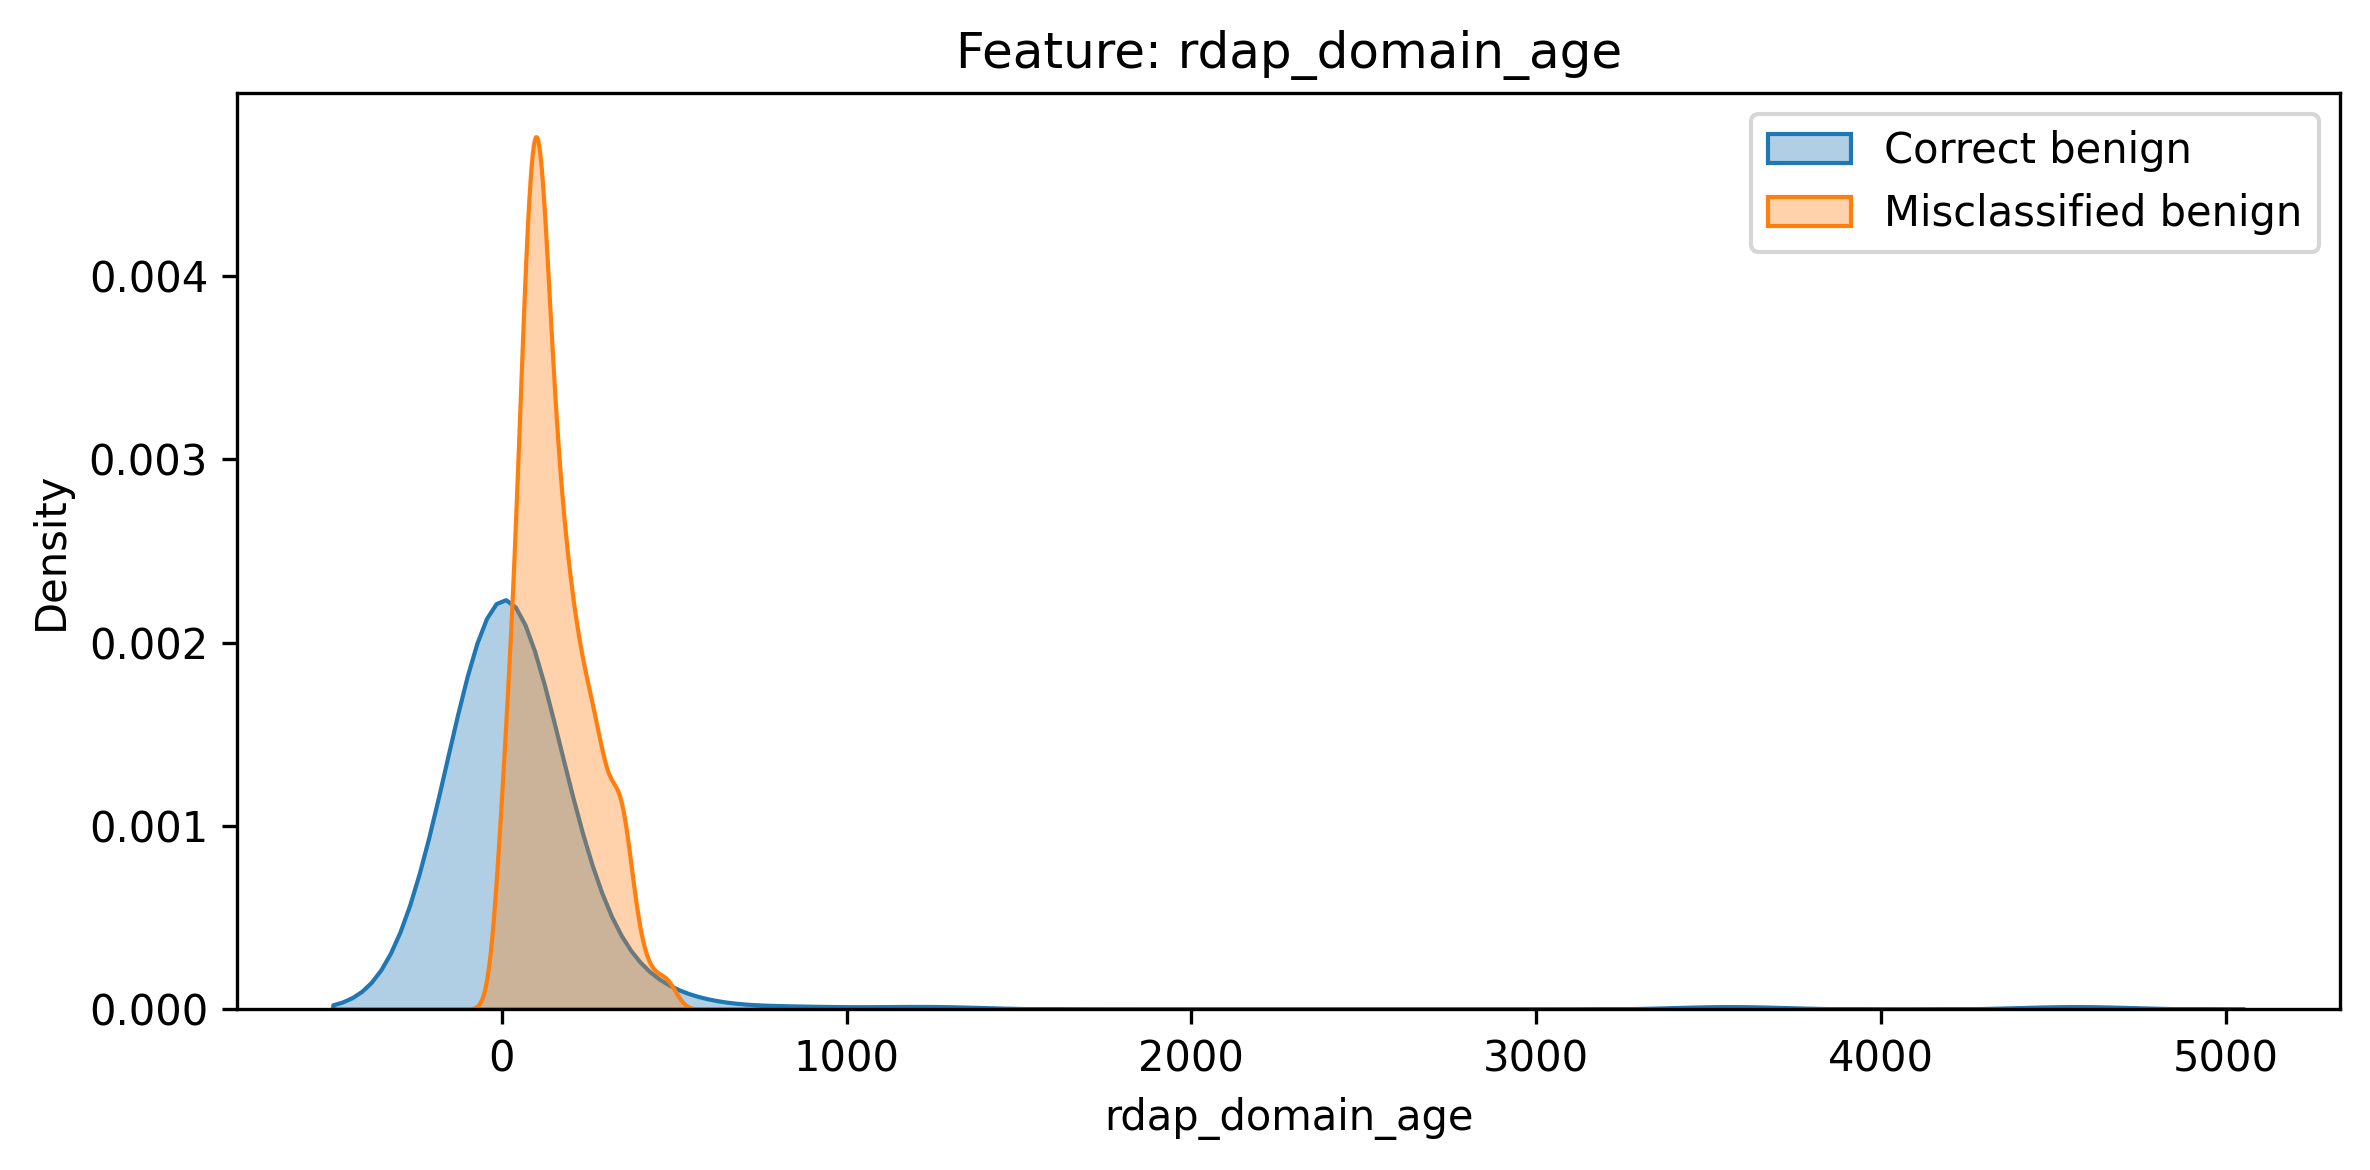

[rdap_domain_age] No threshold extracted; mis_mean=159, correct_mean=84.7


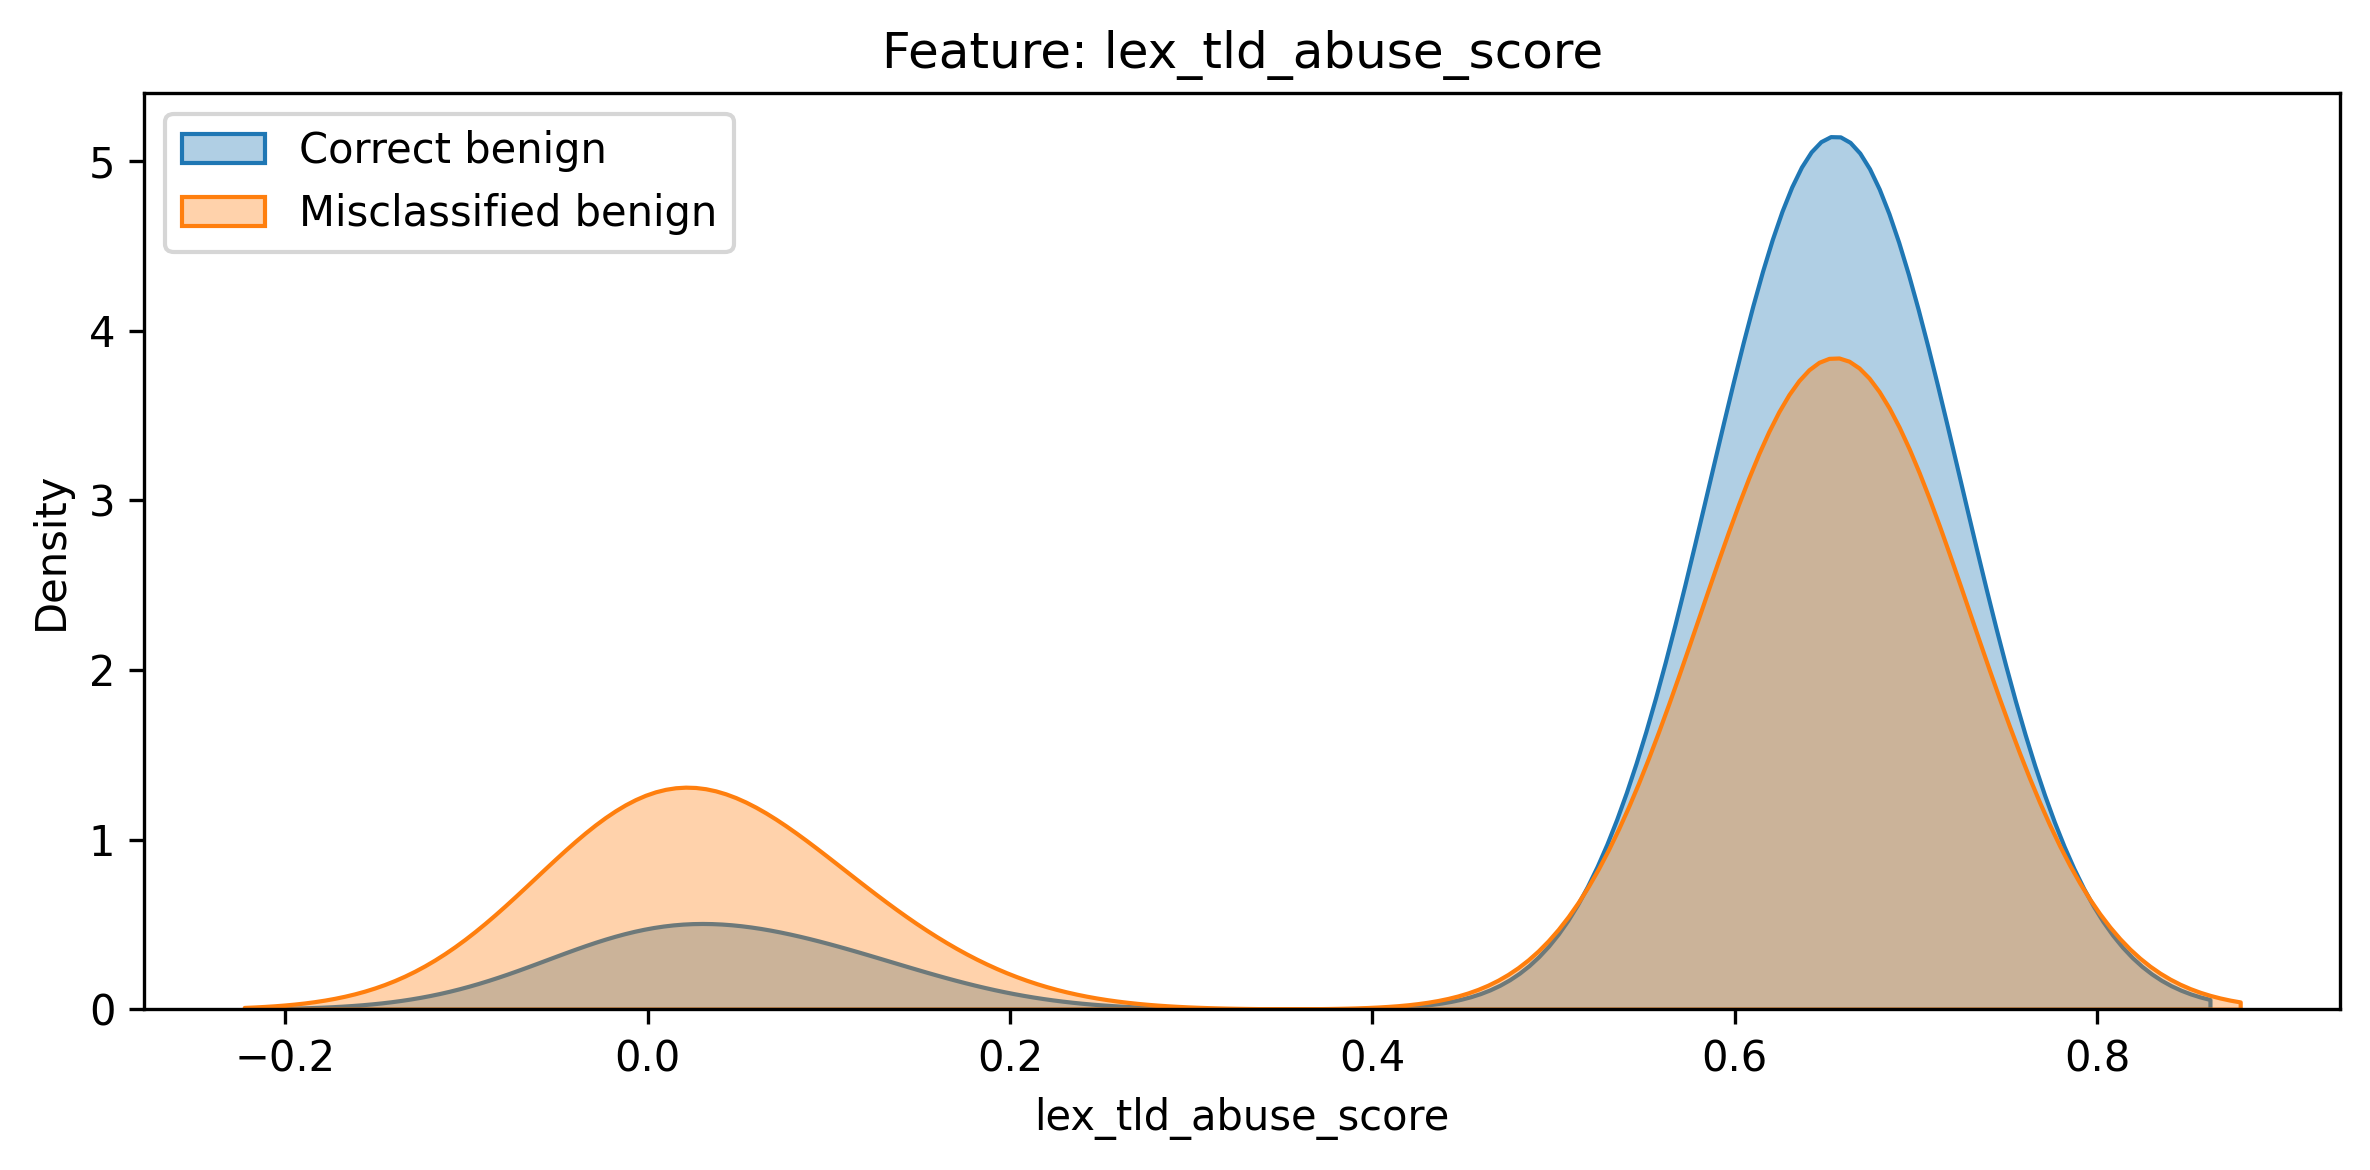

[lex_tld_abuse_score] No threshold extracted; mis_mean=0.479, correct_mean=0.588


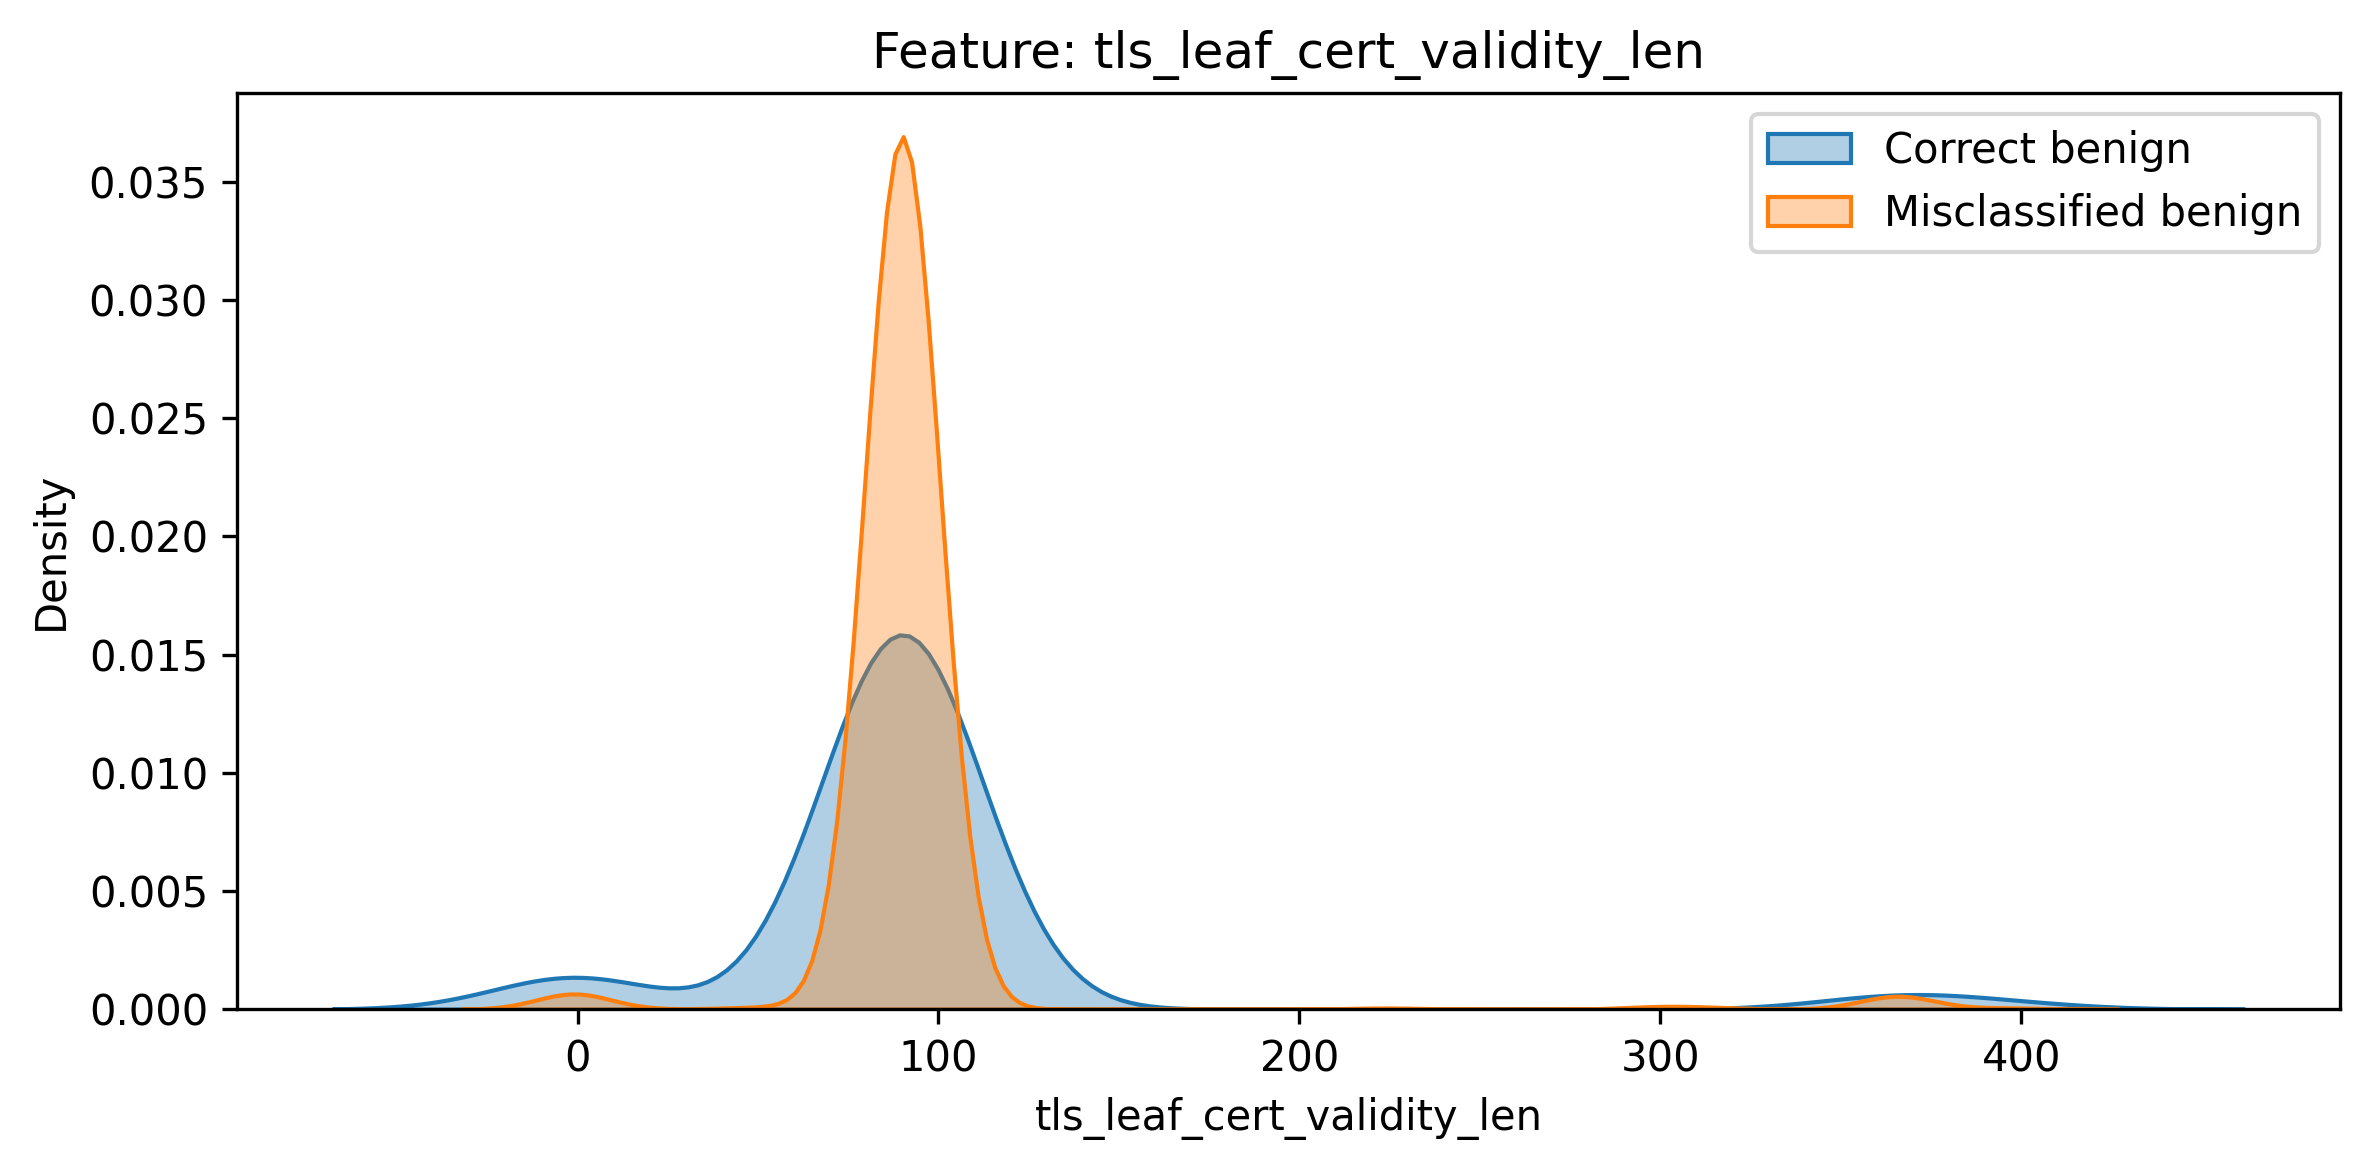

[tls_leaf_cert_validity_len] No threshold extracted; mis_mean=93.7, correct_mean=94.7


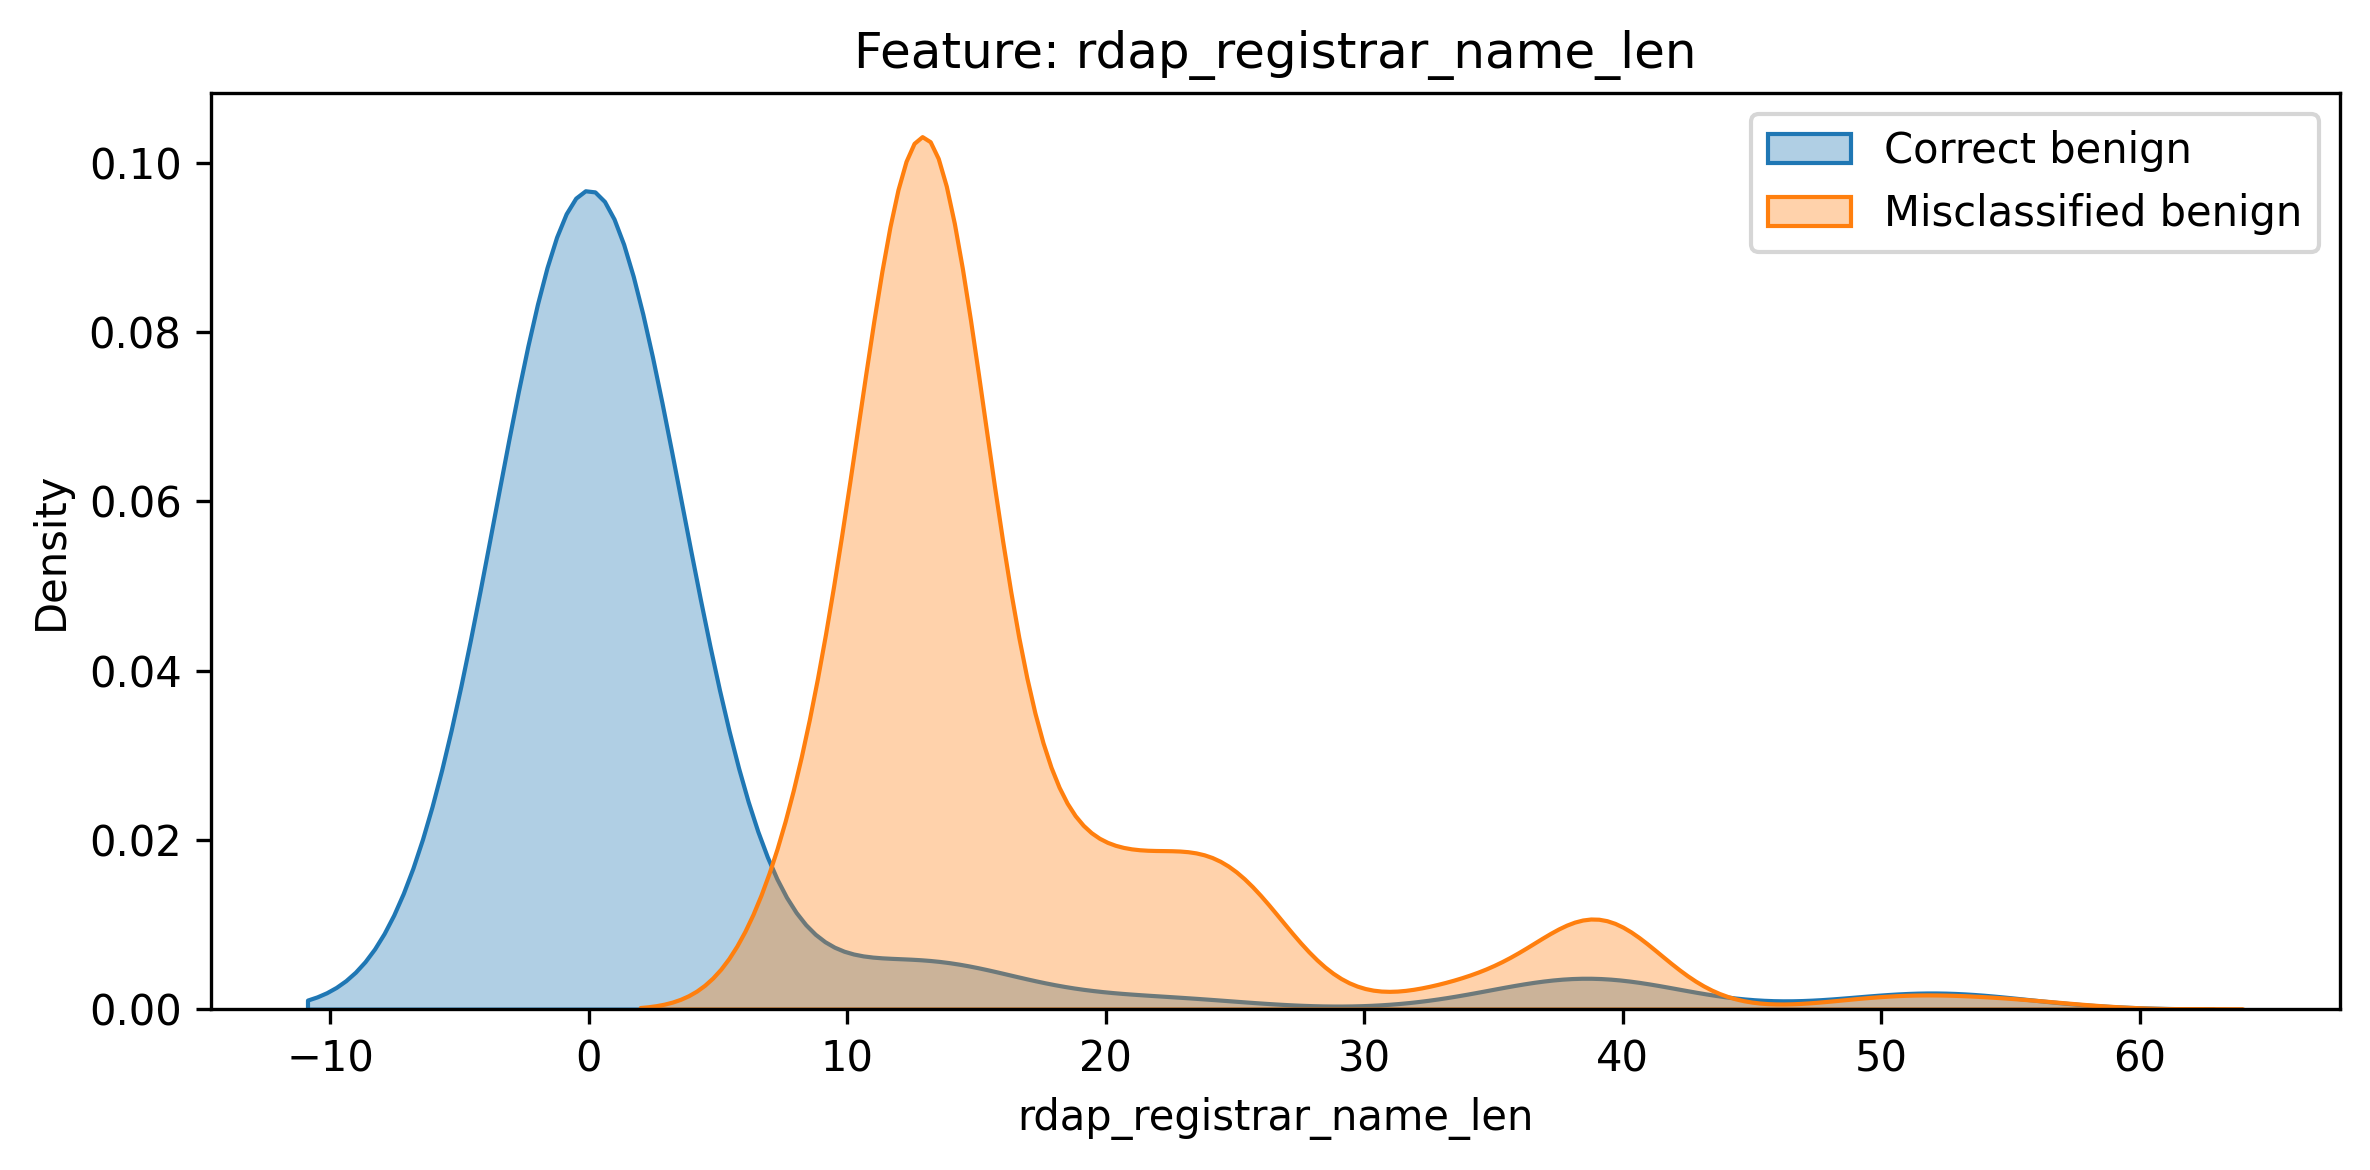

[rdap_registrar_name_len] No threshold extracted; mis_mean=17.1, correct_mean=3.2


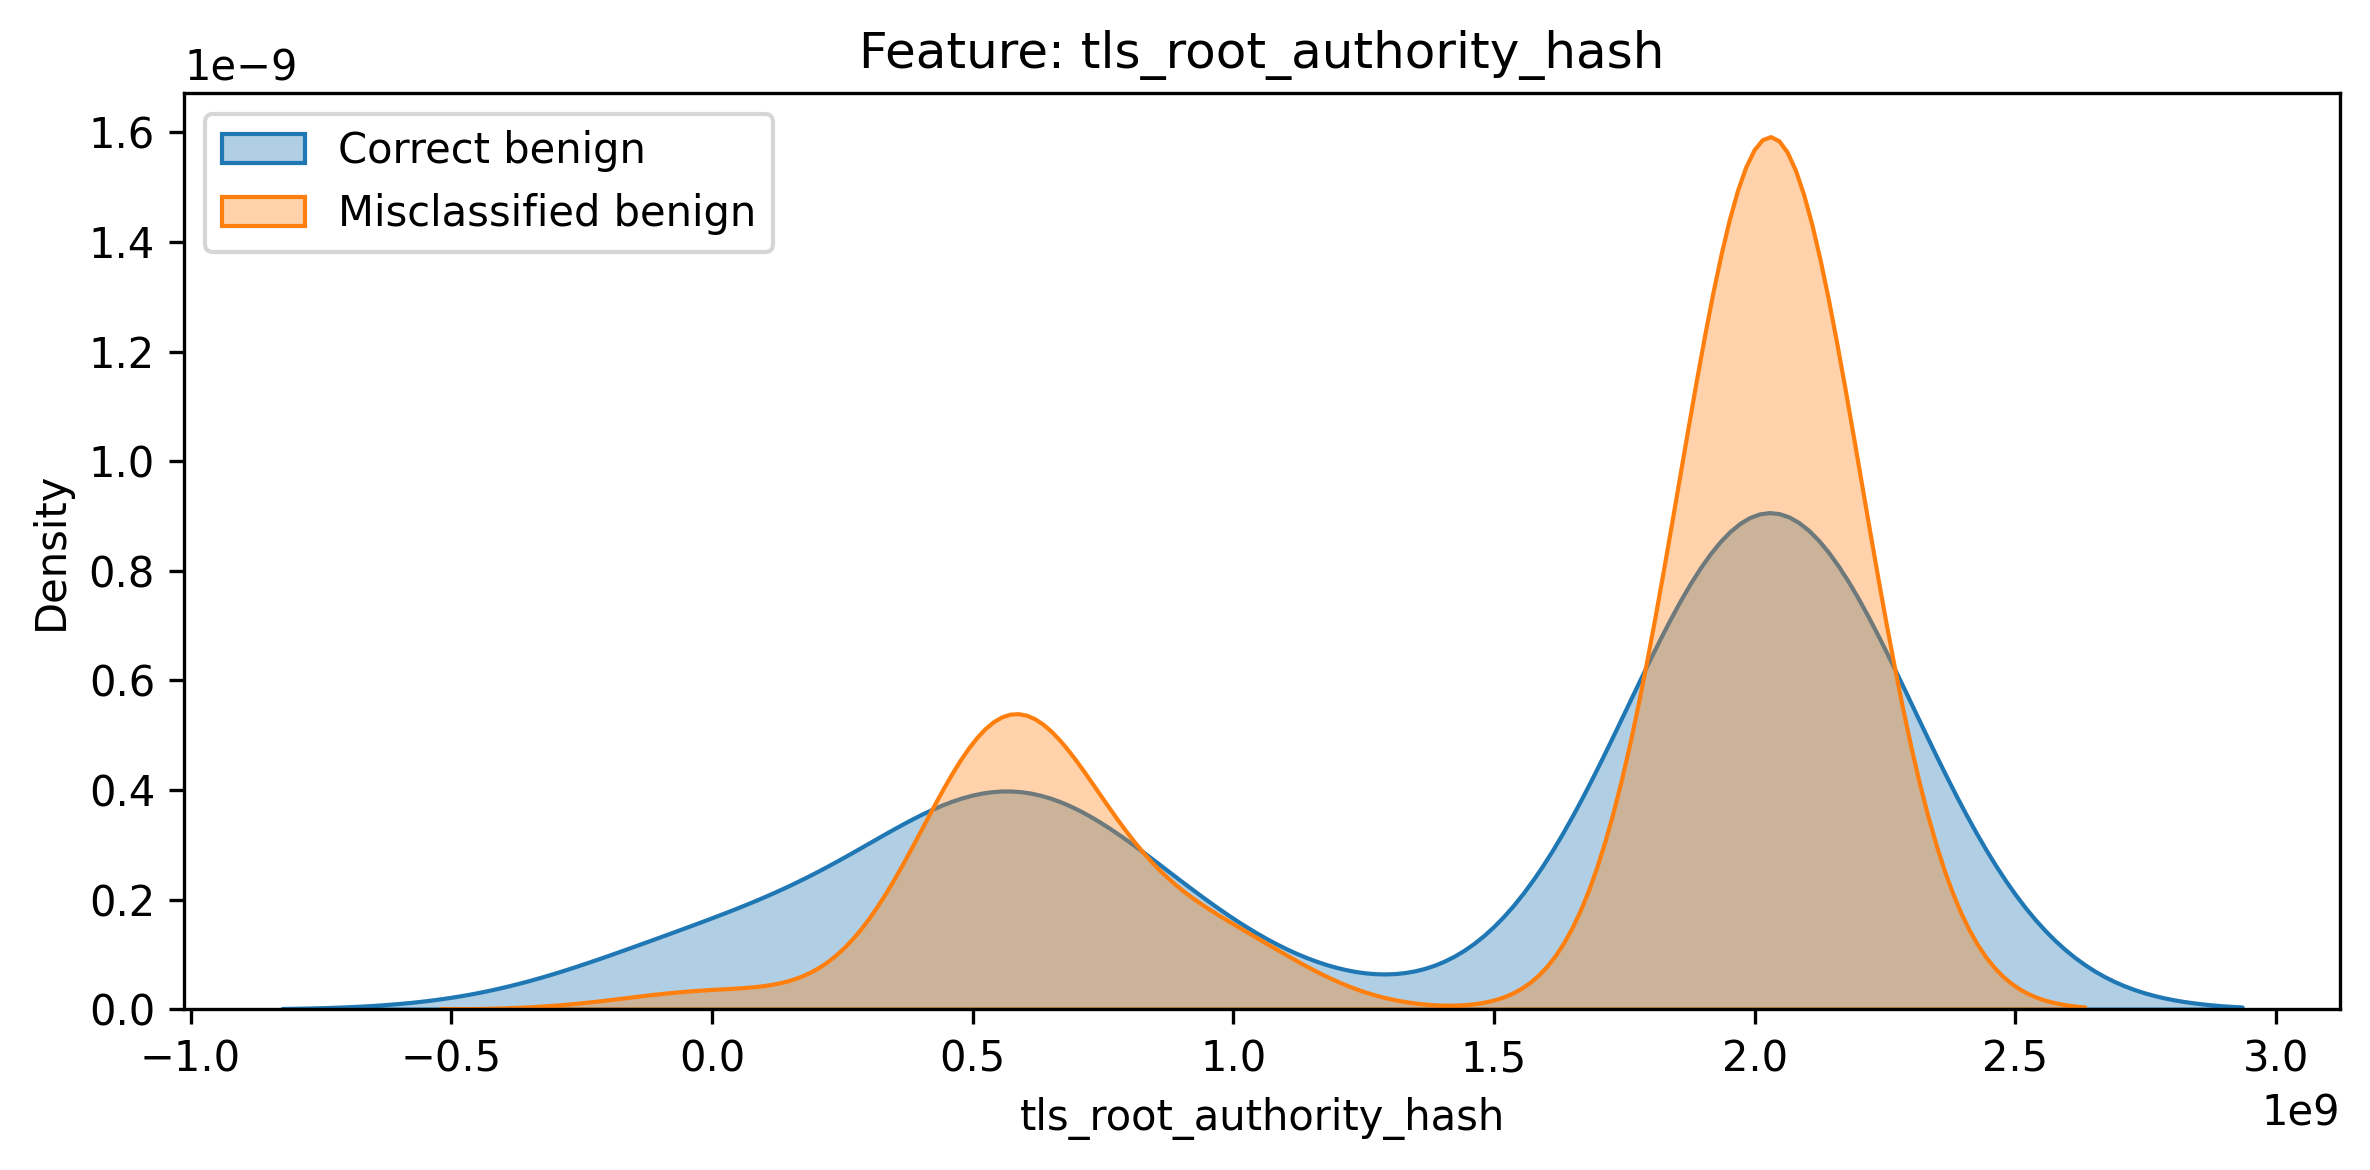

[tls_root_authority_hash] No threshold extracted; mis_mean=1.6e+09, correct_mean=1.45e+09


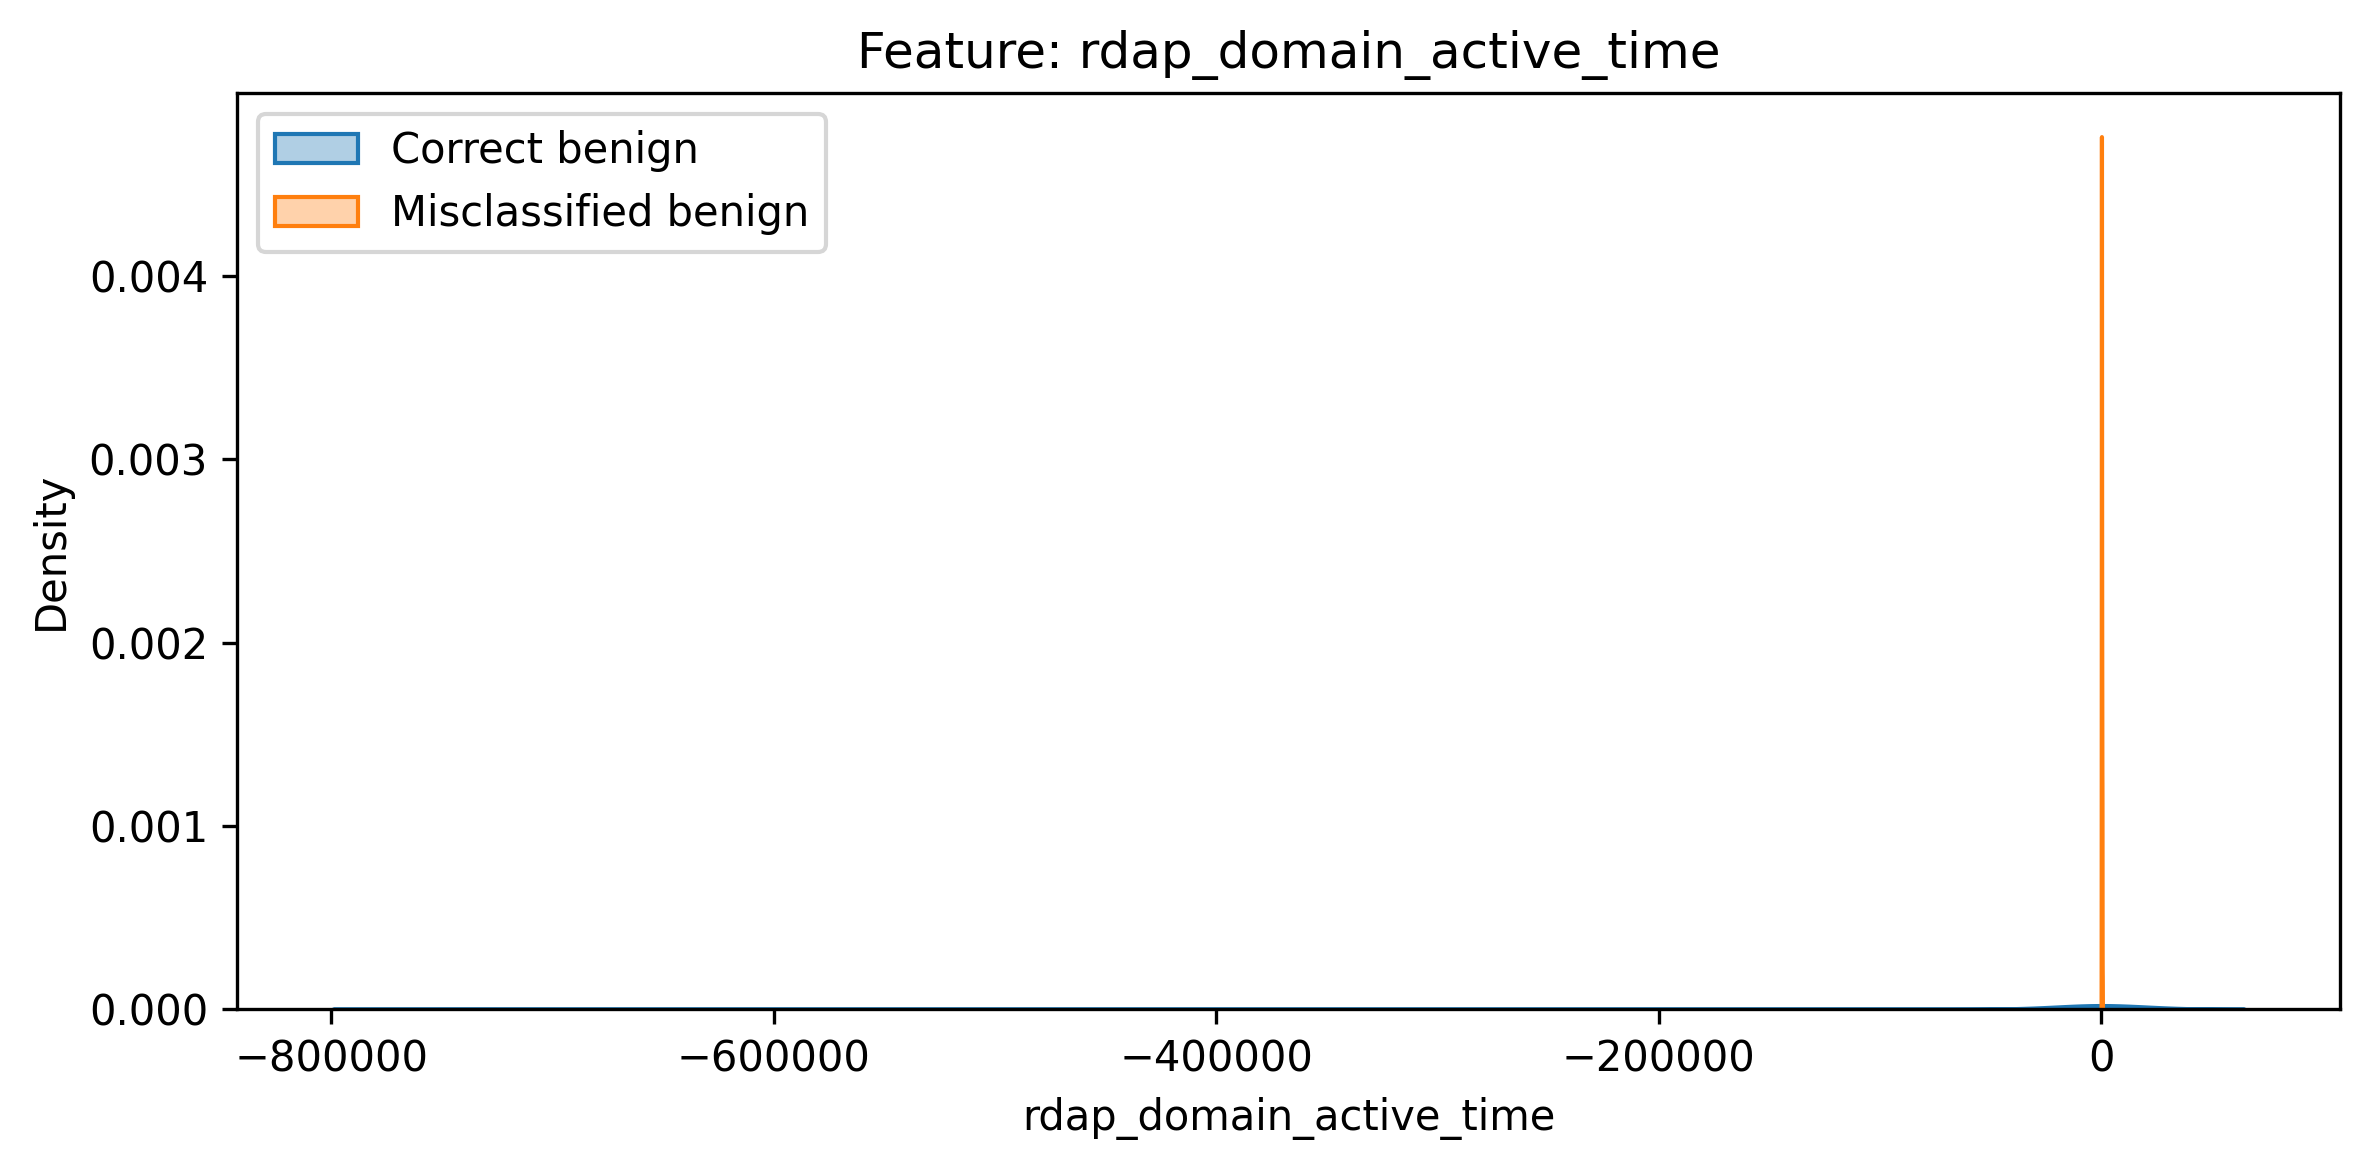

[rdap_domain_active_time] No threshold extracted; mis_mean=159, correct_mean=-4.19e+03


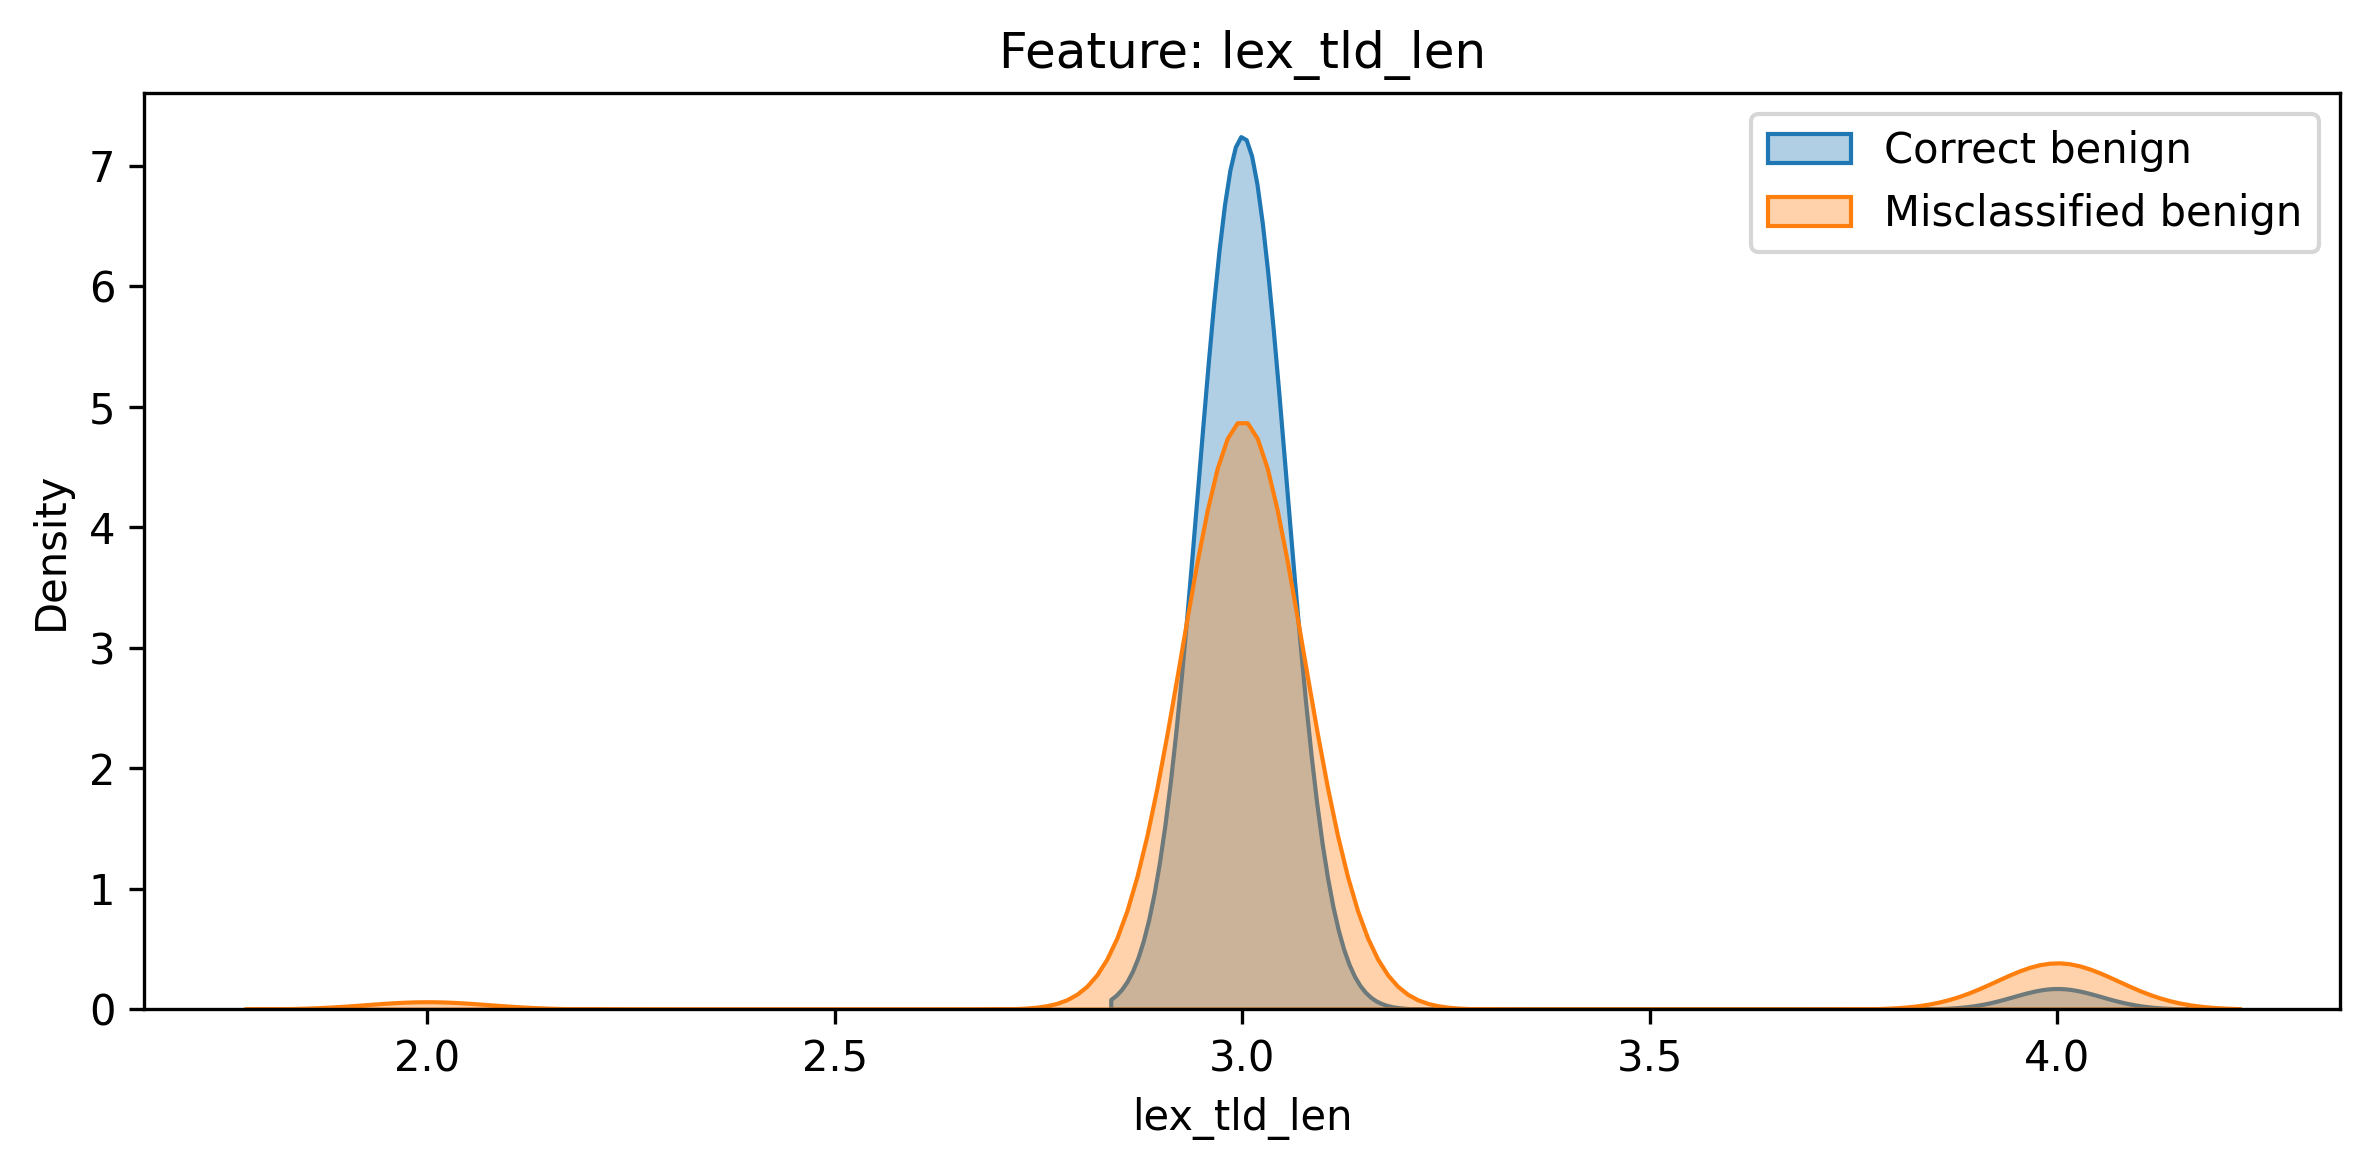

[lex_tld_len] No threshold extracted; mis_mean=3.06, correct_mean=3.02


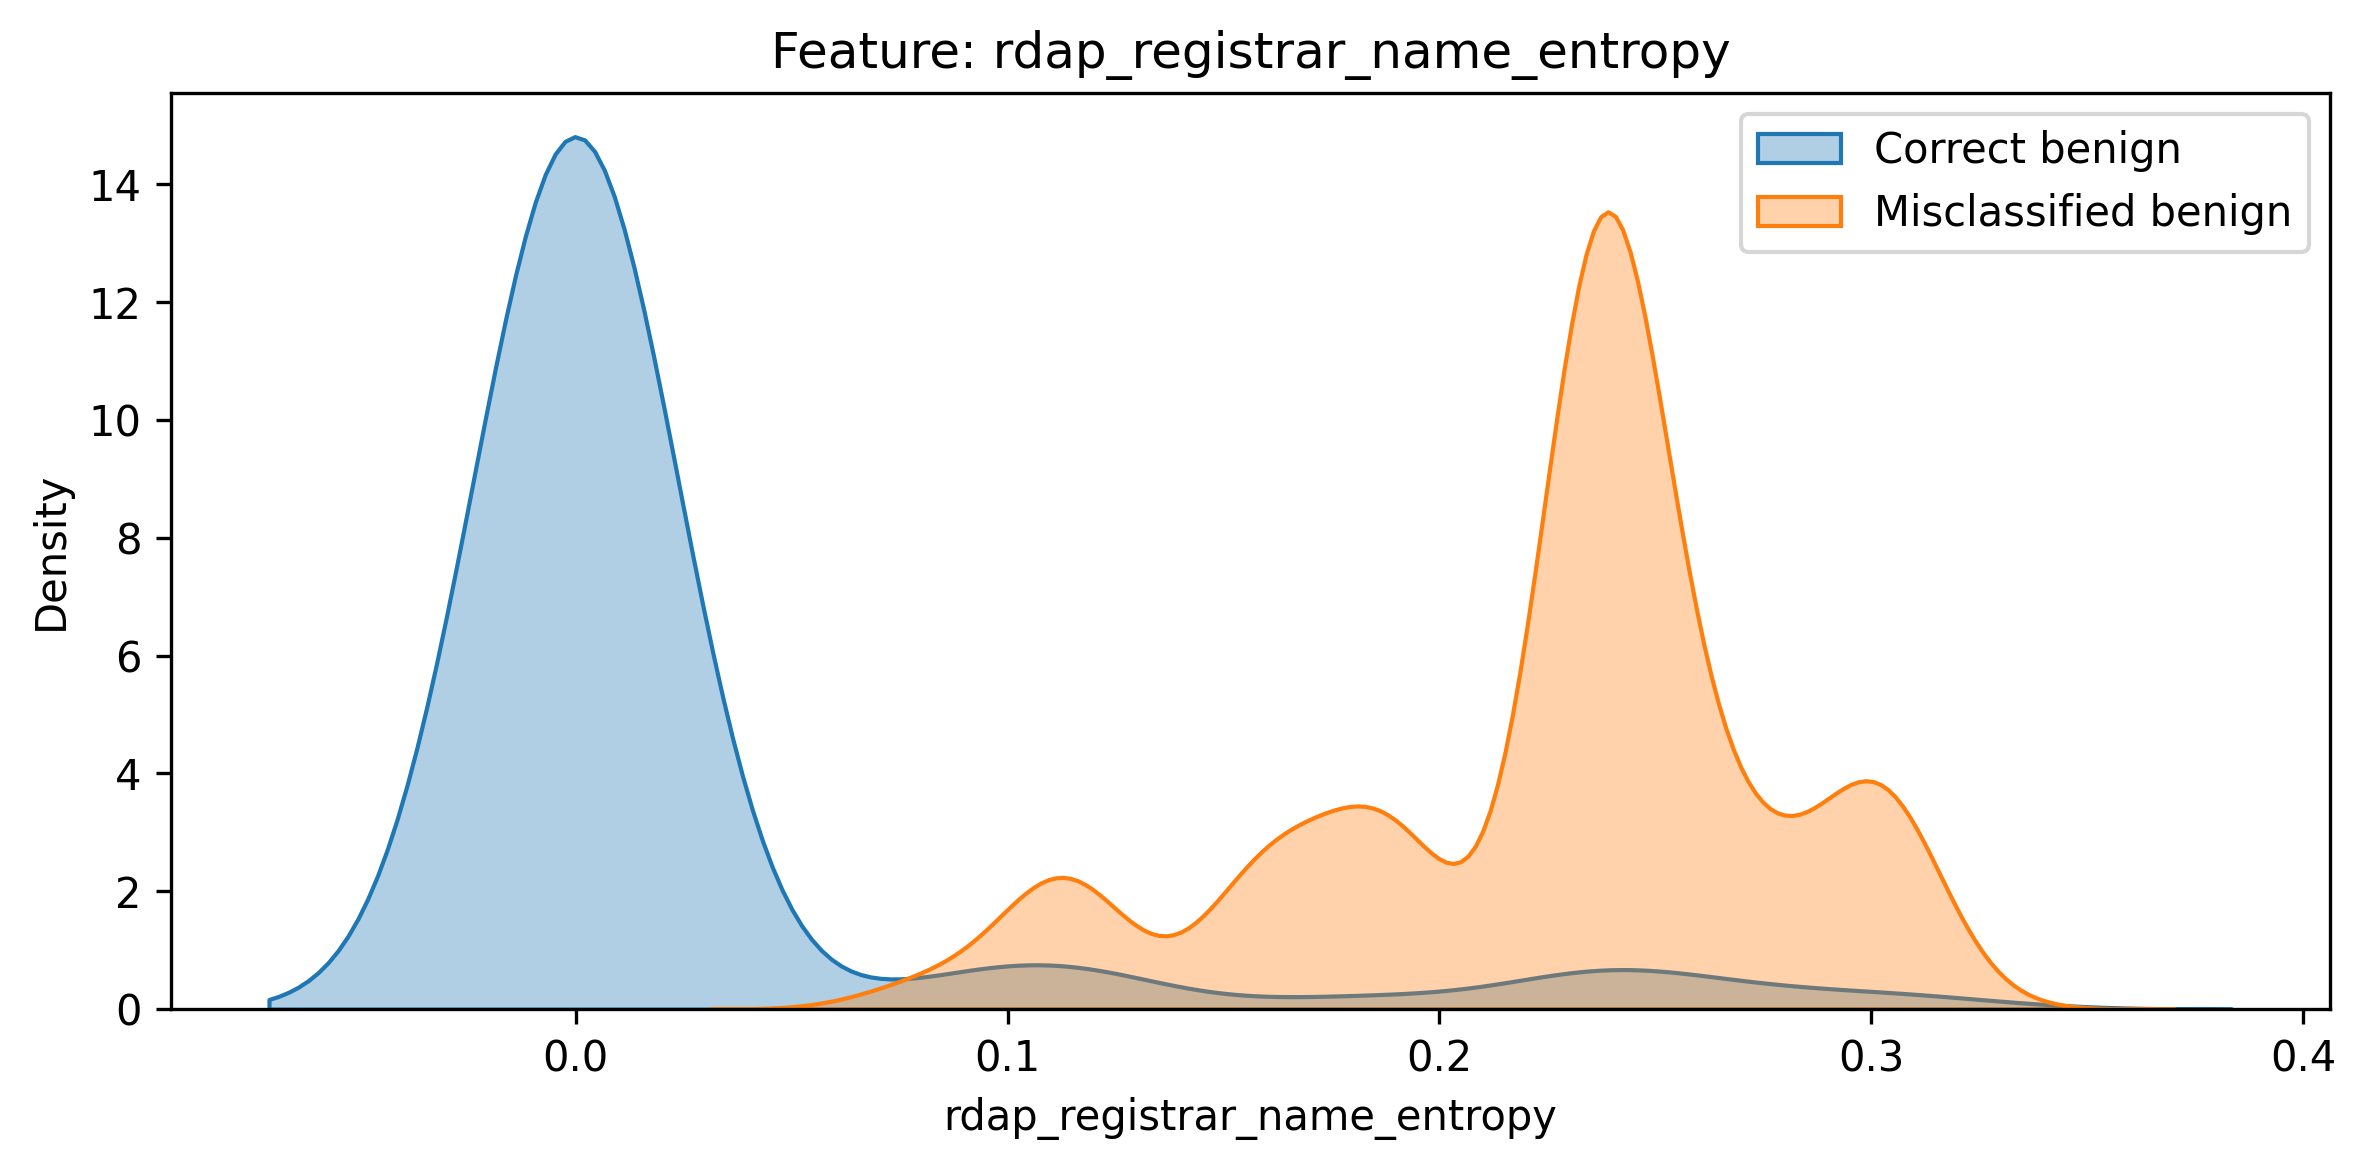

[rdap_registrar_name_entropy] No threshold extracted; mis_mean=0.225, correct_mean=0.0225


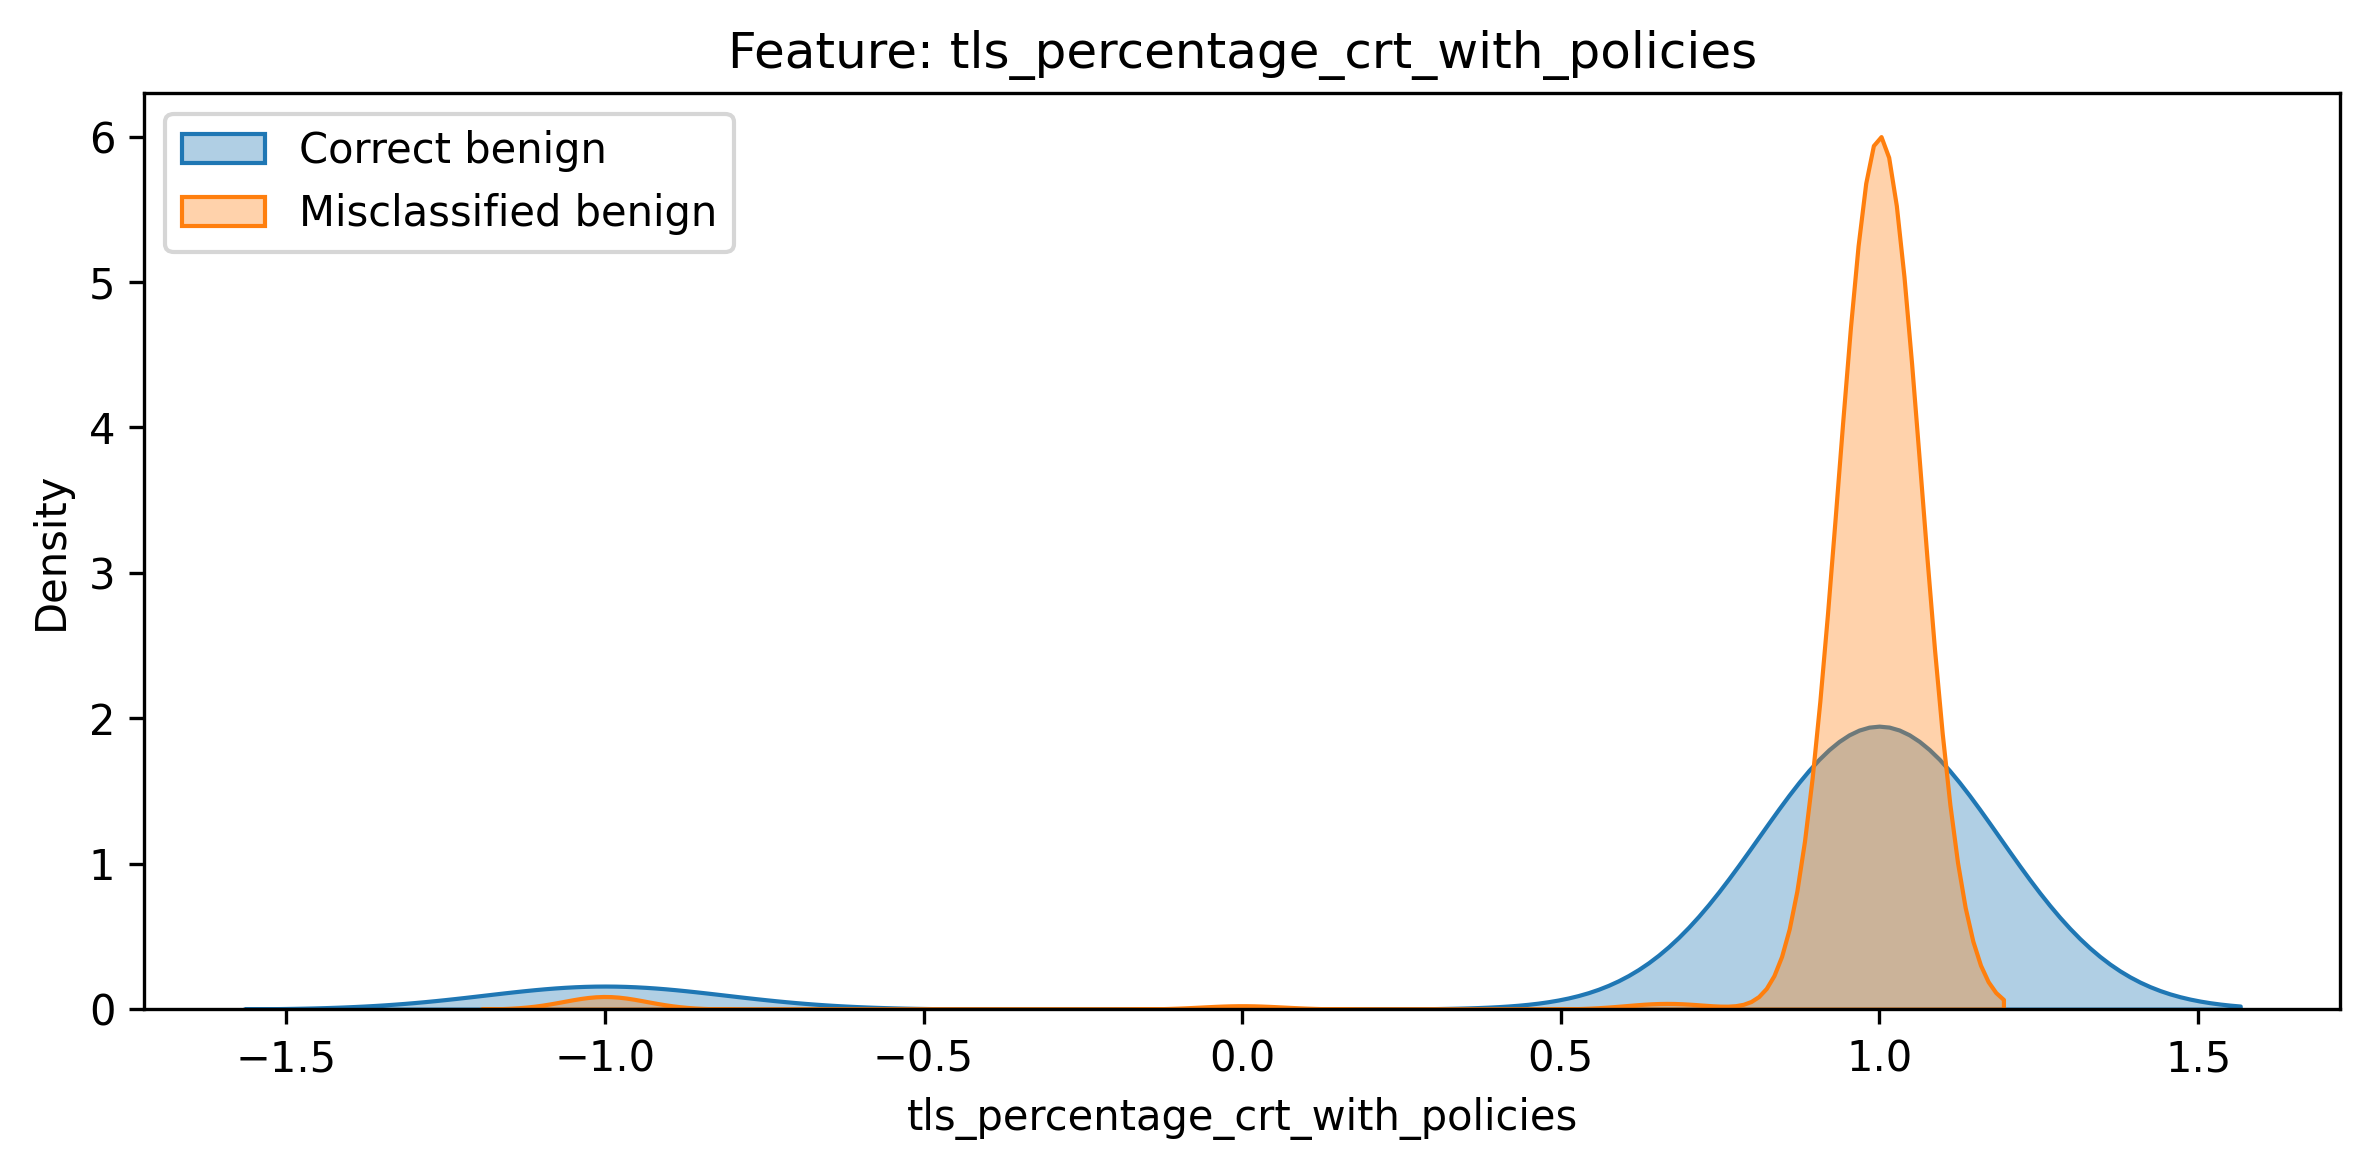

[tls_percentage_crt_with_policies] No threshold extracted; mis_mean=0.966, correct_mean=0.848


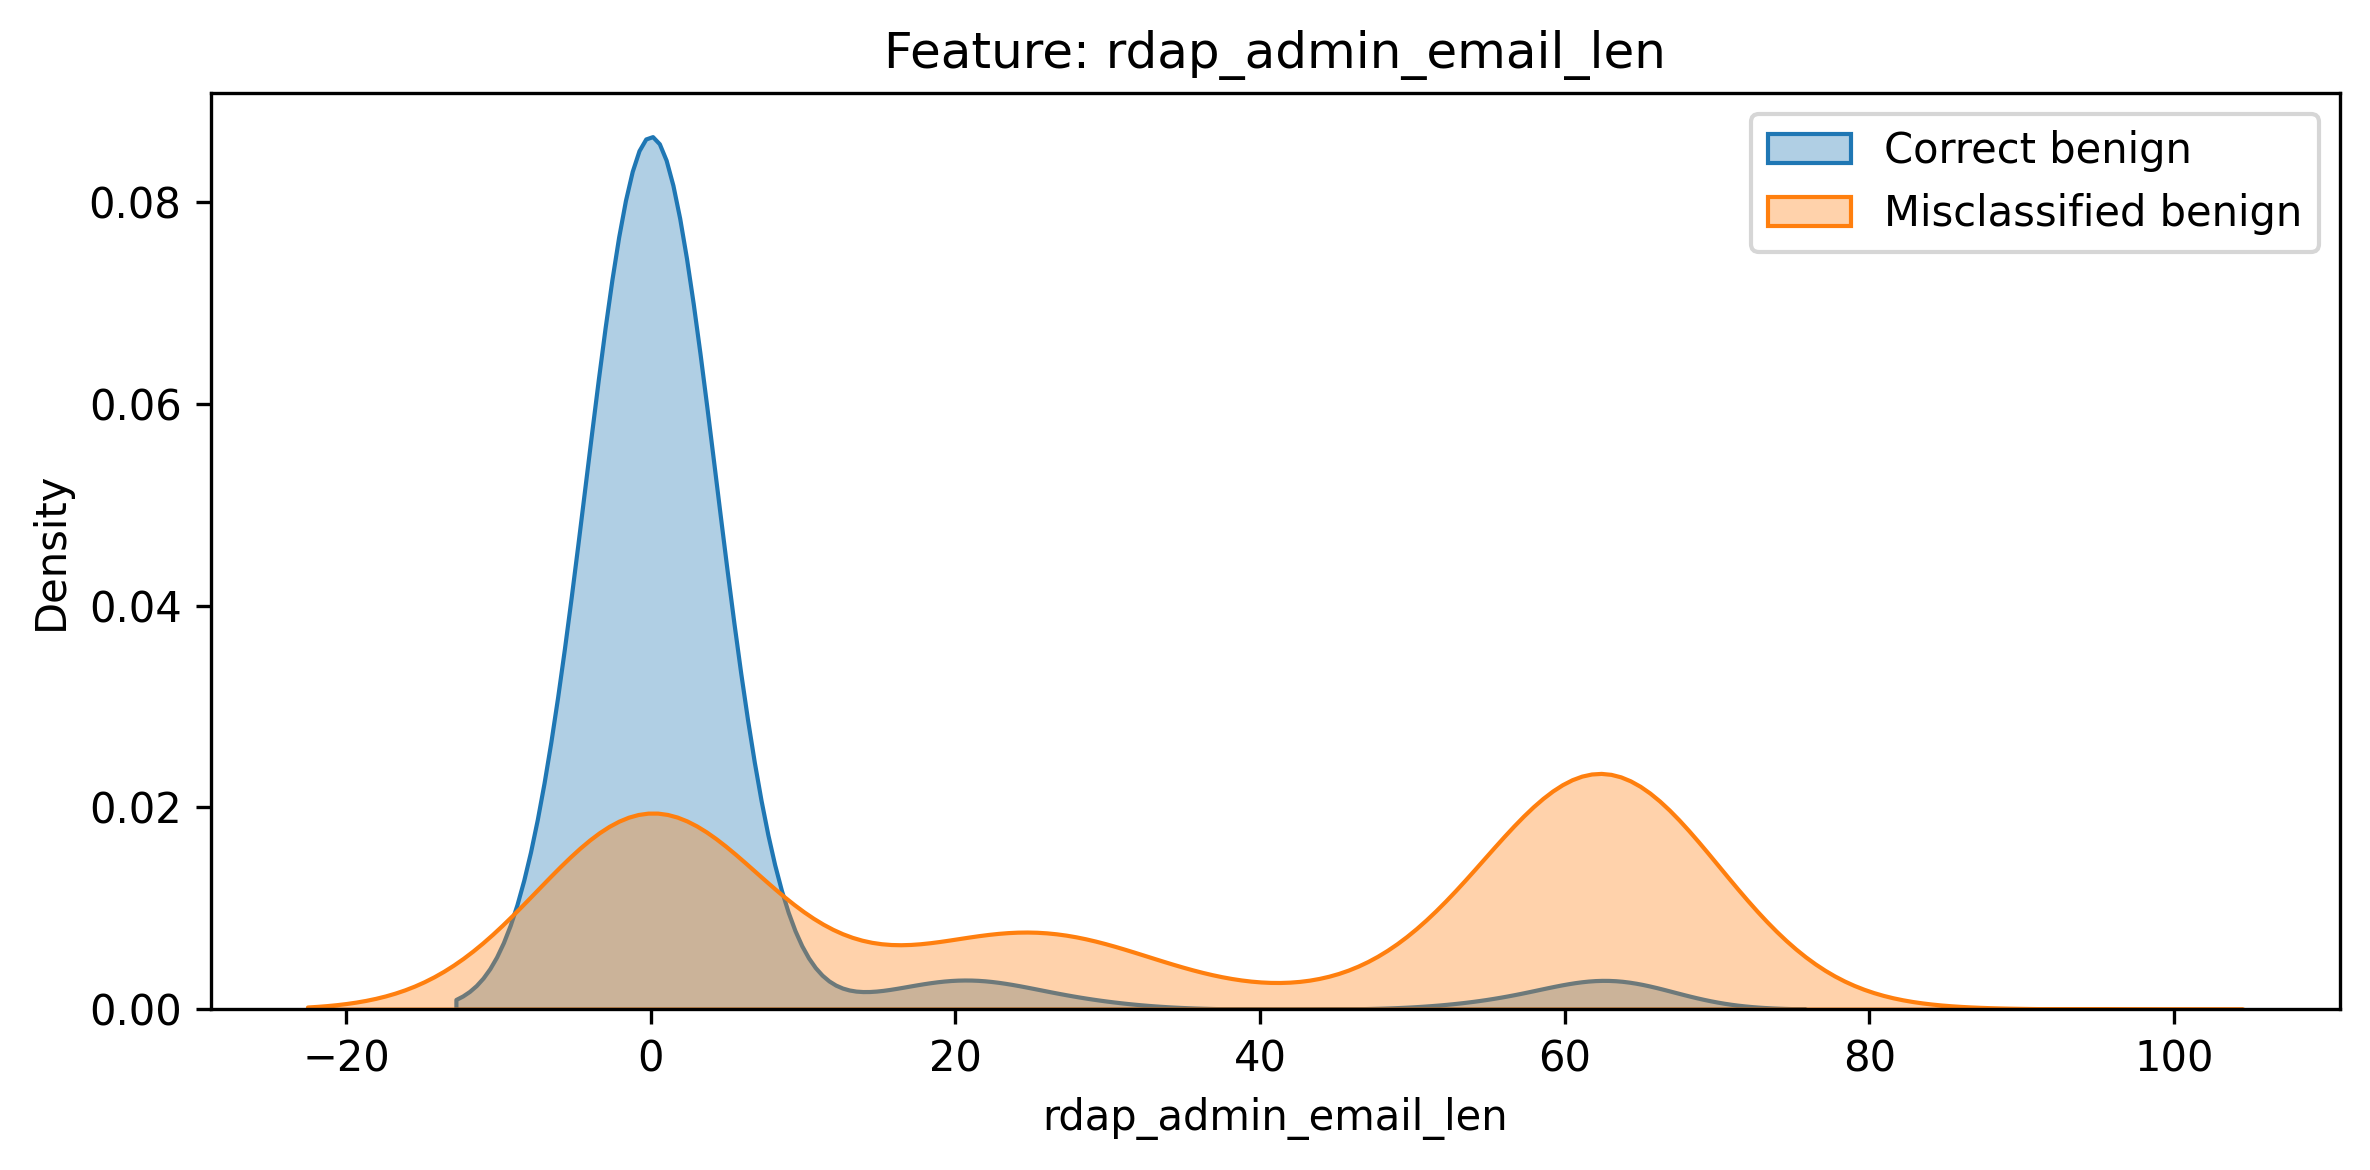

[rdap_admin_email_len] No threshold extracted; mis_mean=33.3, correct_mean=2.99


KeyError: 'suggestion'

In [23]:
analysis = analyze_problematic_features(model, df_validation, misclassified, top_k=10)
for feat, info in analysis.items():
    print(info["suggestion"])


In [ ]:
# TODO: MOST FREQUENT BAD FEATURES

In [ ]:
# Filter rows where value < 0
bad_rows = df_validation[df_validation["rdap_registrar_name_len"] < 0]

print(bad_rows[["domain_name", "rdap_registrar_name_len"]])

In [24]:
import pyarrow.parquet as pq
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def compare_with_external_benign(model, misclassified_df, top_features, benign_file, top_k=10):
    """
    Compare distribution of misclassified benign (FP) vs. external benign dataset
    for top features. Overlay model thresholds.
    
    Parameters
    ----------
    model : trained classifier (tree-based recommended: XGBoost/LightGBM)
    misclassified_df : pd.DataFrame with at least ['domain_name','label'] + features
    top_features : list of features (from SHAP or analysis)
    benign_file : str, path to external benign parquet dataset
    top_k : int, number of features to plot
    """
    # Load external benign set
    df_benign_ext = pq.read_table(benign_file).to_pandas()
    if "label" not in df_benign_ext.columns:
        df_benign_ext["label"] = 0  # ensure benign label

    # Align features if needed
    available_features = [f for f in top_features if f in df_benign_ext.columns and f in misclassified_df.columns]
    print(f"Comparing {len(available_features)} features present in both datasets.")

    # Extract thresholds for plotting
    thr_df = extract_feature_thresholds(model, available_features, agg="median")
    thr_map = dict(zip(thr_df["feature"], thr_df["threshold"]))

    results = {}
    for feat in available_features[:top_k]:
        vals_mis = misclassified_df[misclassified_df["label"] == 0][feat].astype(float)
        vals_corr = df_benign_ext[feat].astype(float)

        t = thr_map.get(feat, np.nan)

        mis_mean, corr_mean = vals_mis.mean(), vals_corr.mean()
        phishing_side = ">" if mis_mean > corr_mean else "<="

        # Plot KDE
        plt.figure(figsize=(8, 4))
        sns.kdeplot(vals_corr, label="External benign", fill=True, alpha=0.35, color="green")
        sns.kdeplot(vals_mis,  label="Misclassified benign", fill=True, alpha=0.35, color="red")
        if not np.isnan(t):
            plt.axvline(t, linestyle="--", linewidth=2, label=f"Model threshold ≈ {t:.3g}")
        plt.title(f"Feature: {feat}")
        plt.legend()
        plt.tight_layout()
        plt.show()

        results[feat] = {
            "threshold": t,
            "phishing_side": phishing_side,
            "mis_mean": float(mis_mean),
            "external_benign_mean": float(corr_mean),
            "diff": float(mis_mean - corr_mean)
        }

    return pd.DataFrame.from_dict(results, orient="index").reset_index(names="feature")


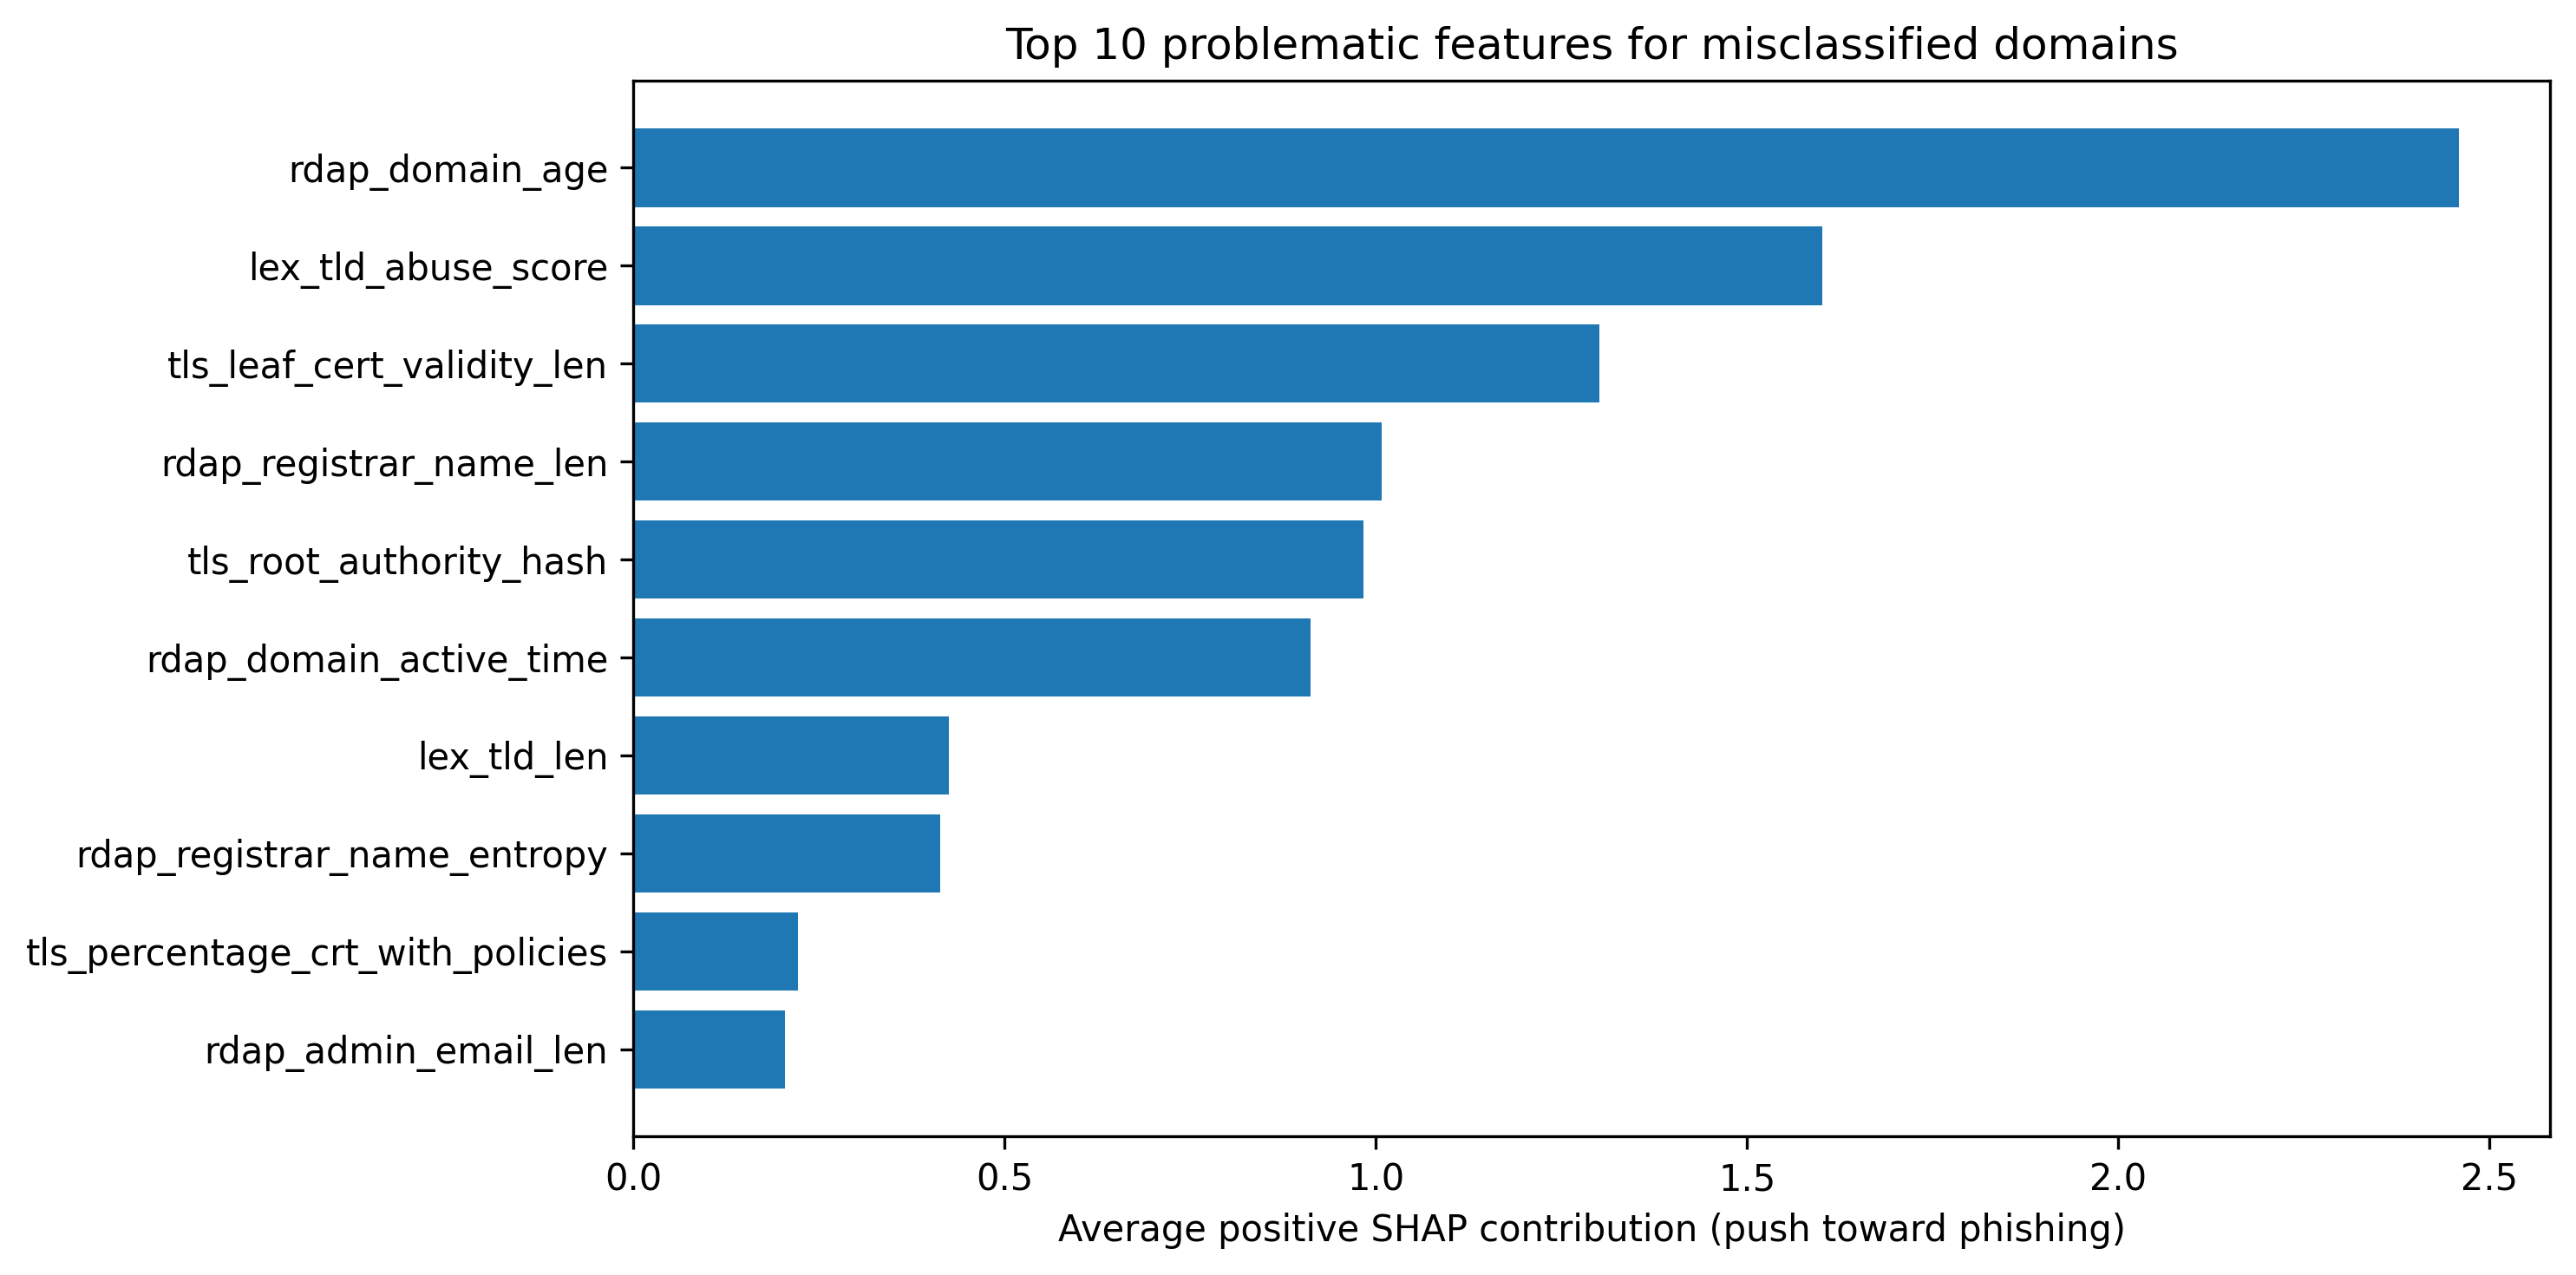

Comparing 10 features present in both datasets.


Could not extract thresholds from model (non-tree model or unsupported).


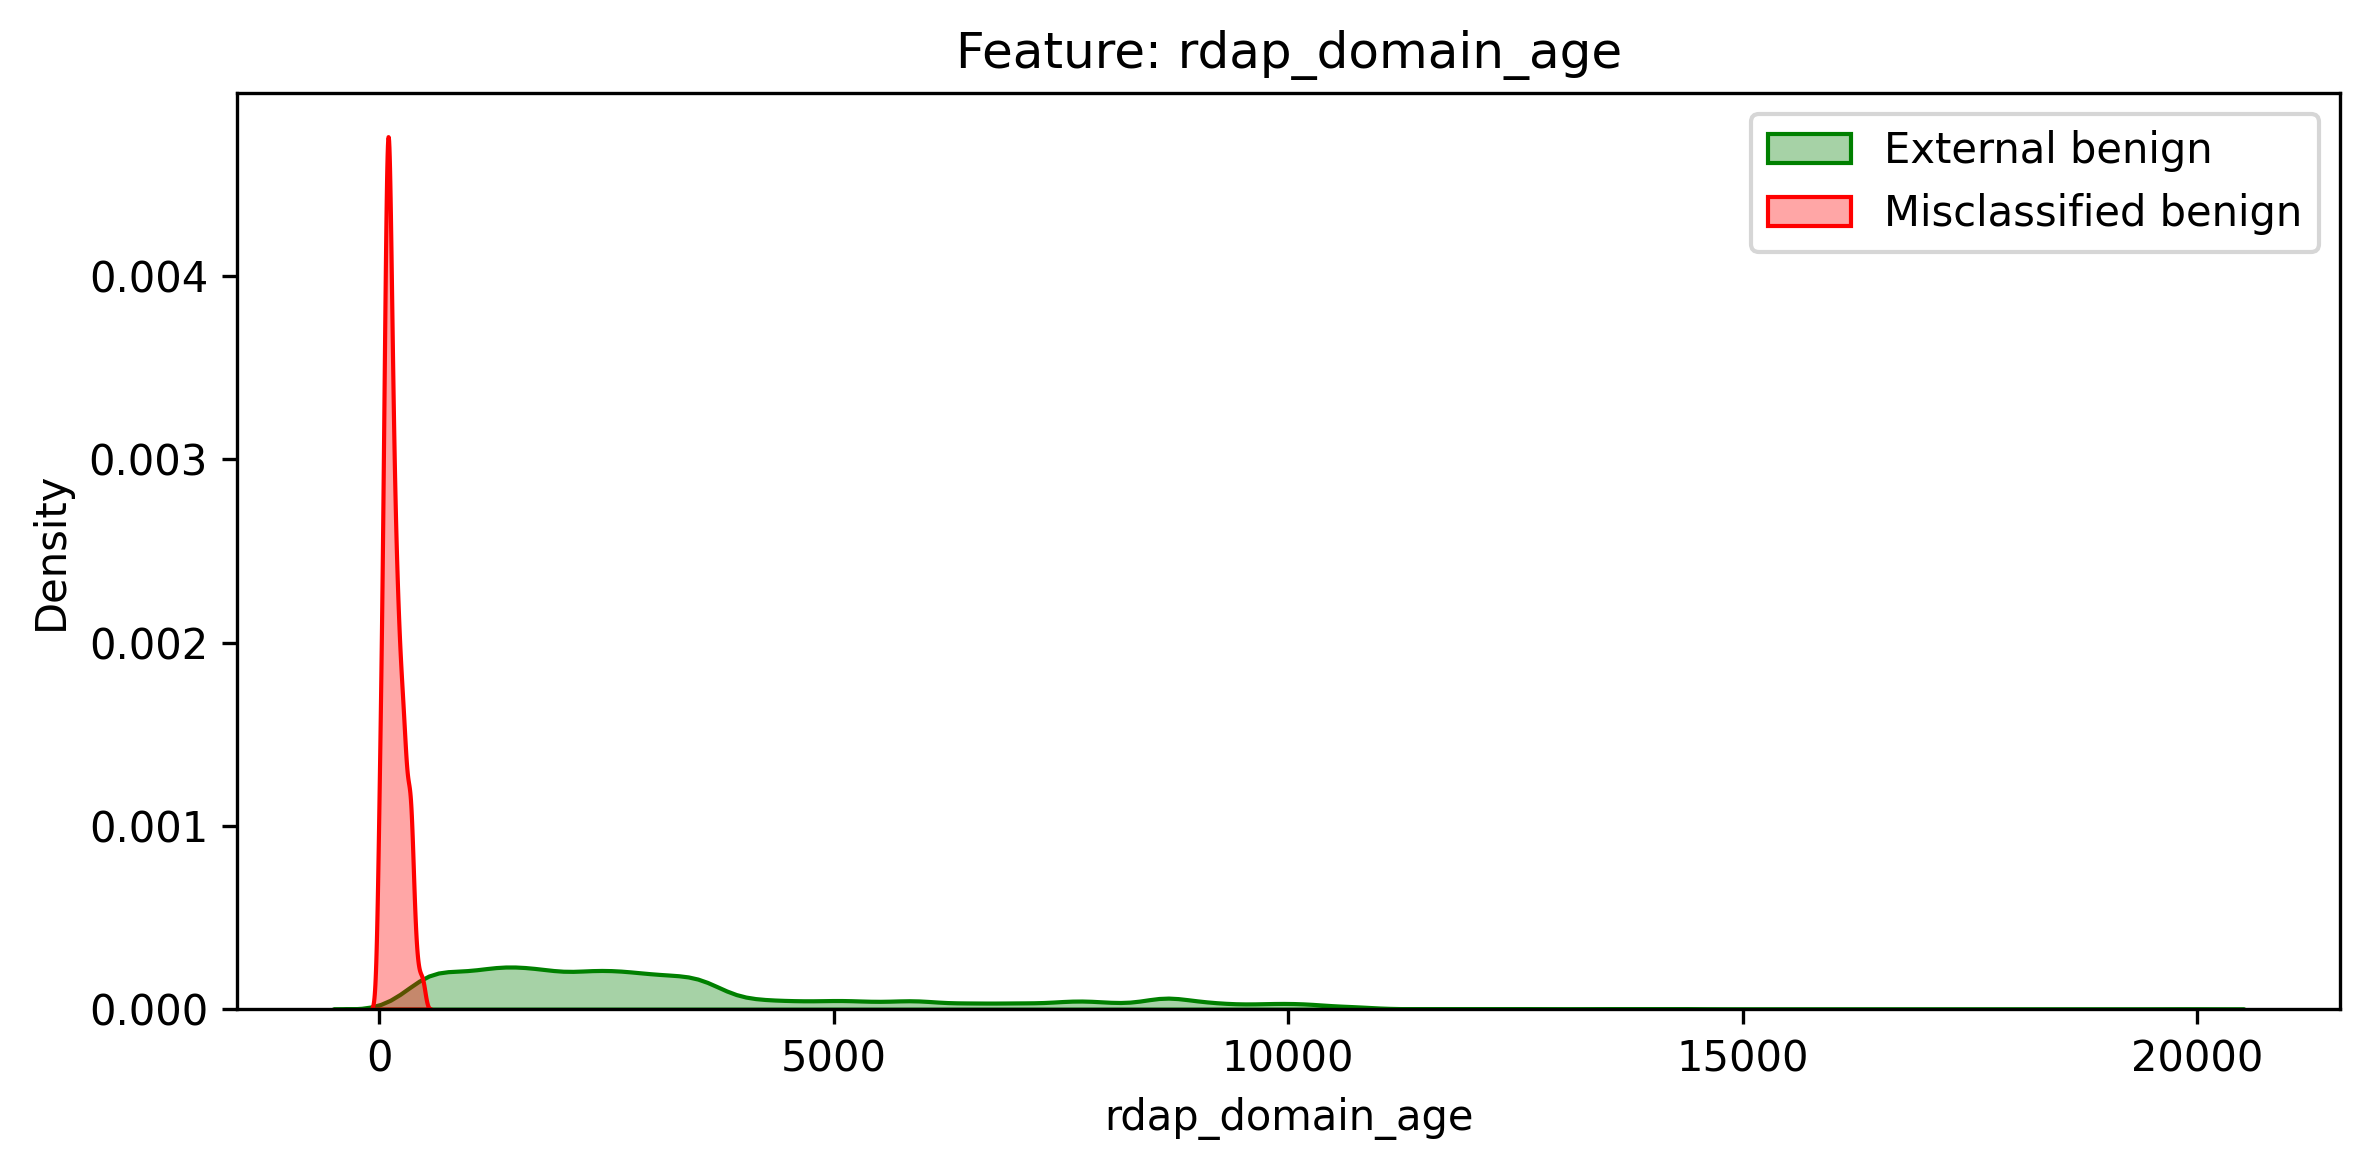

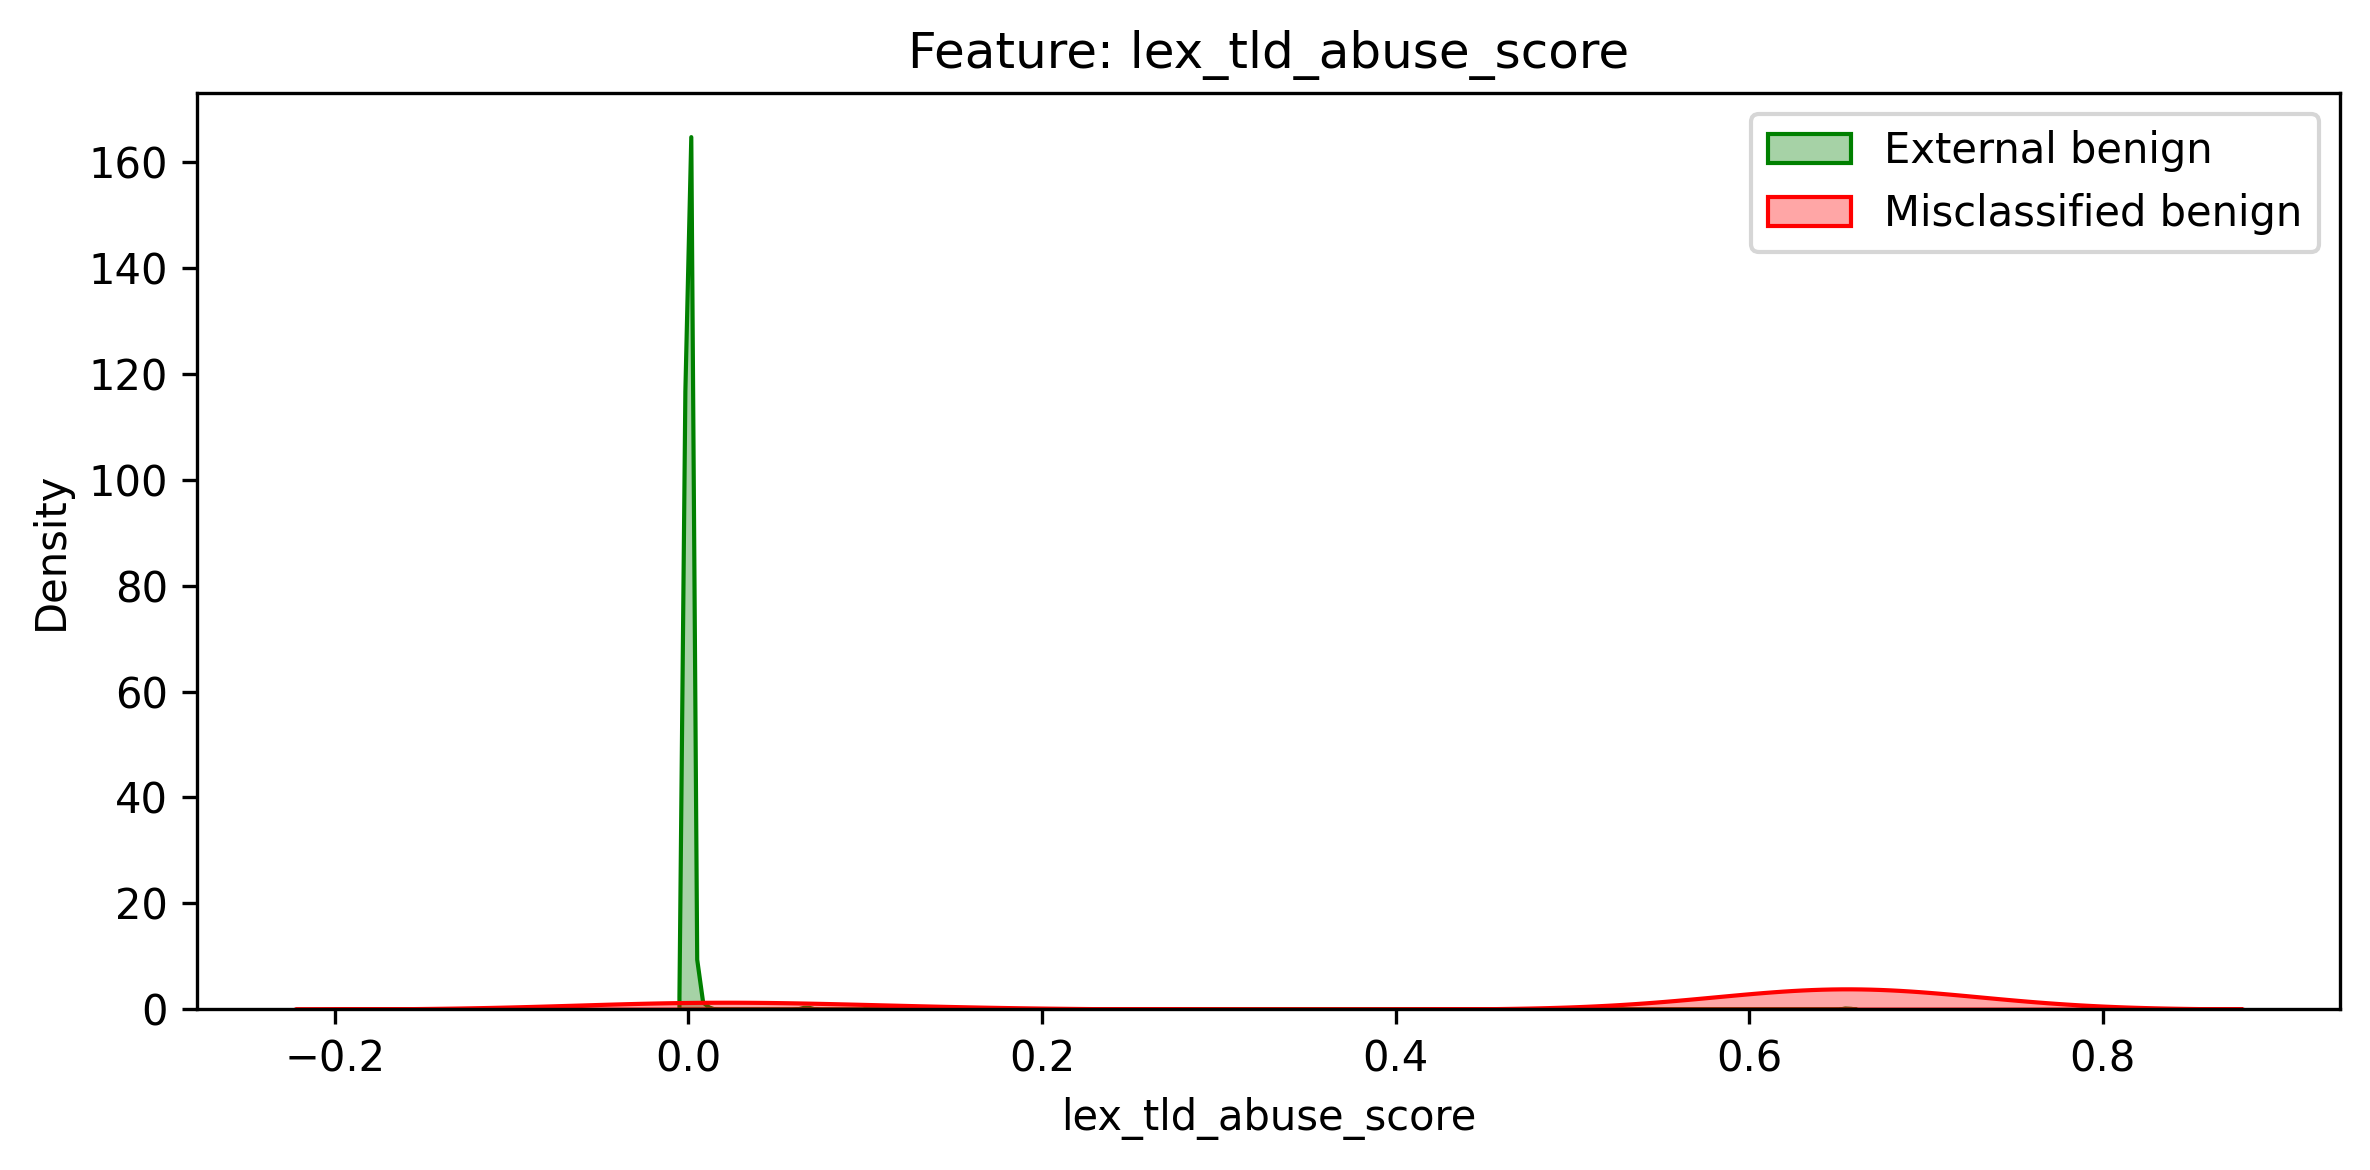

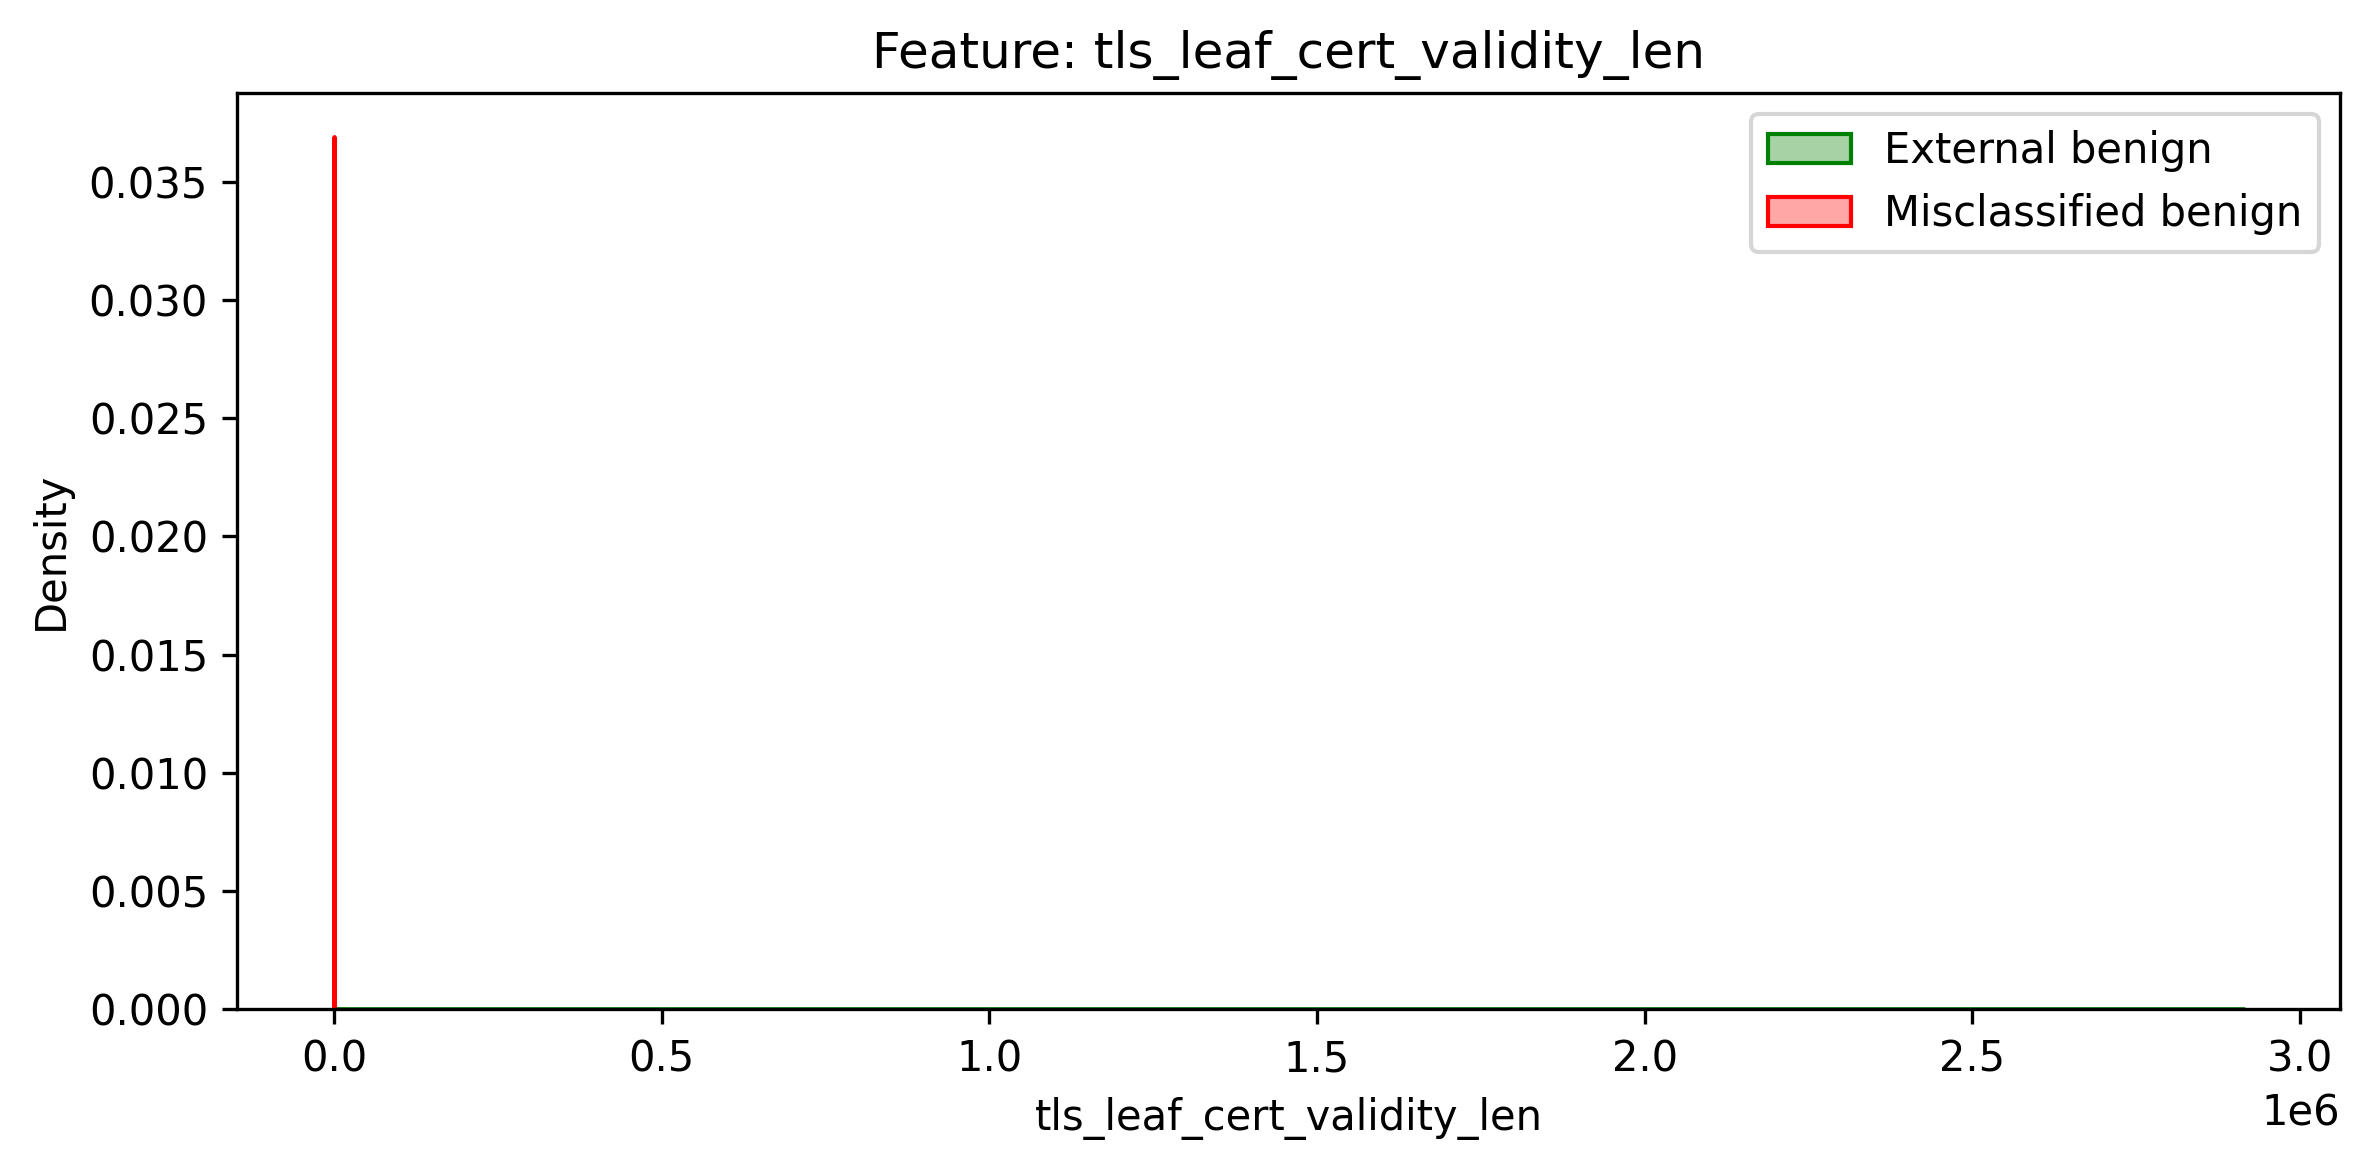

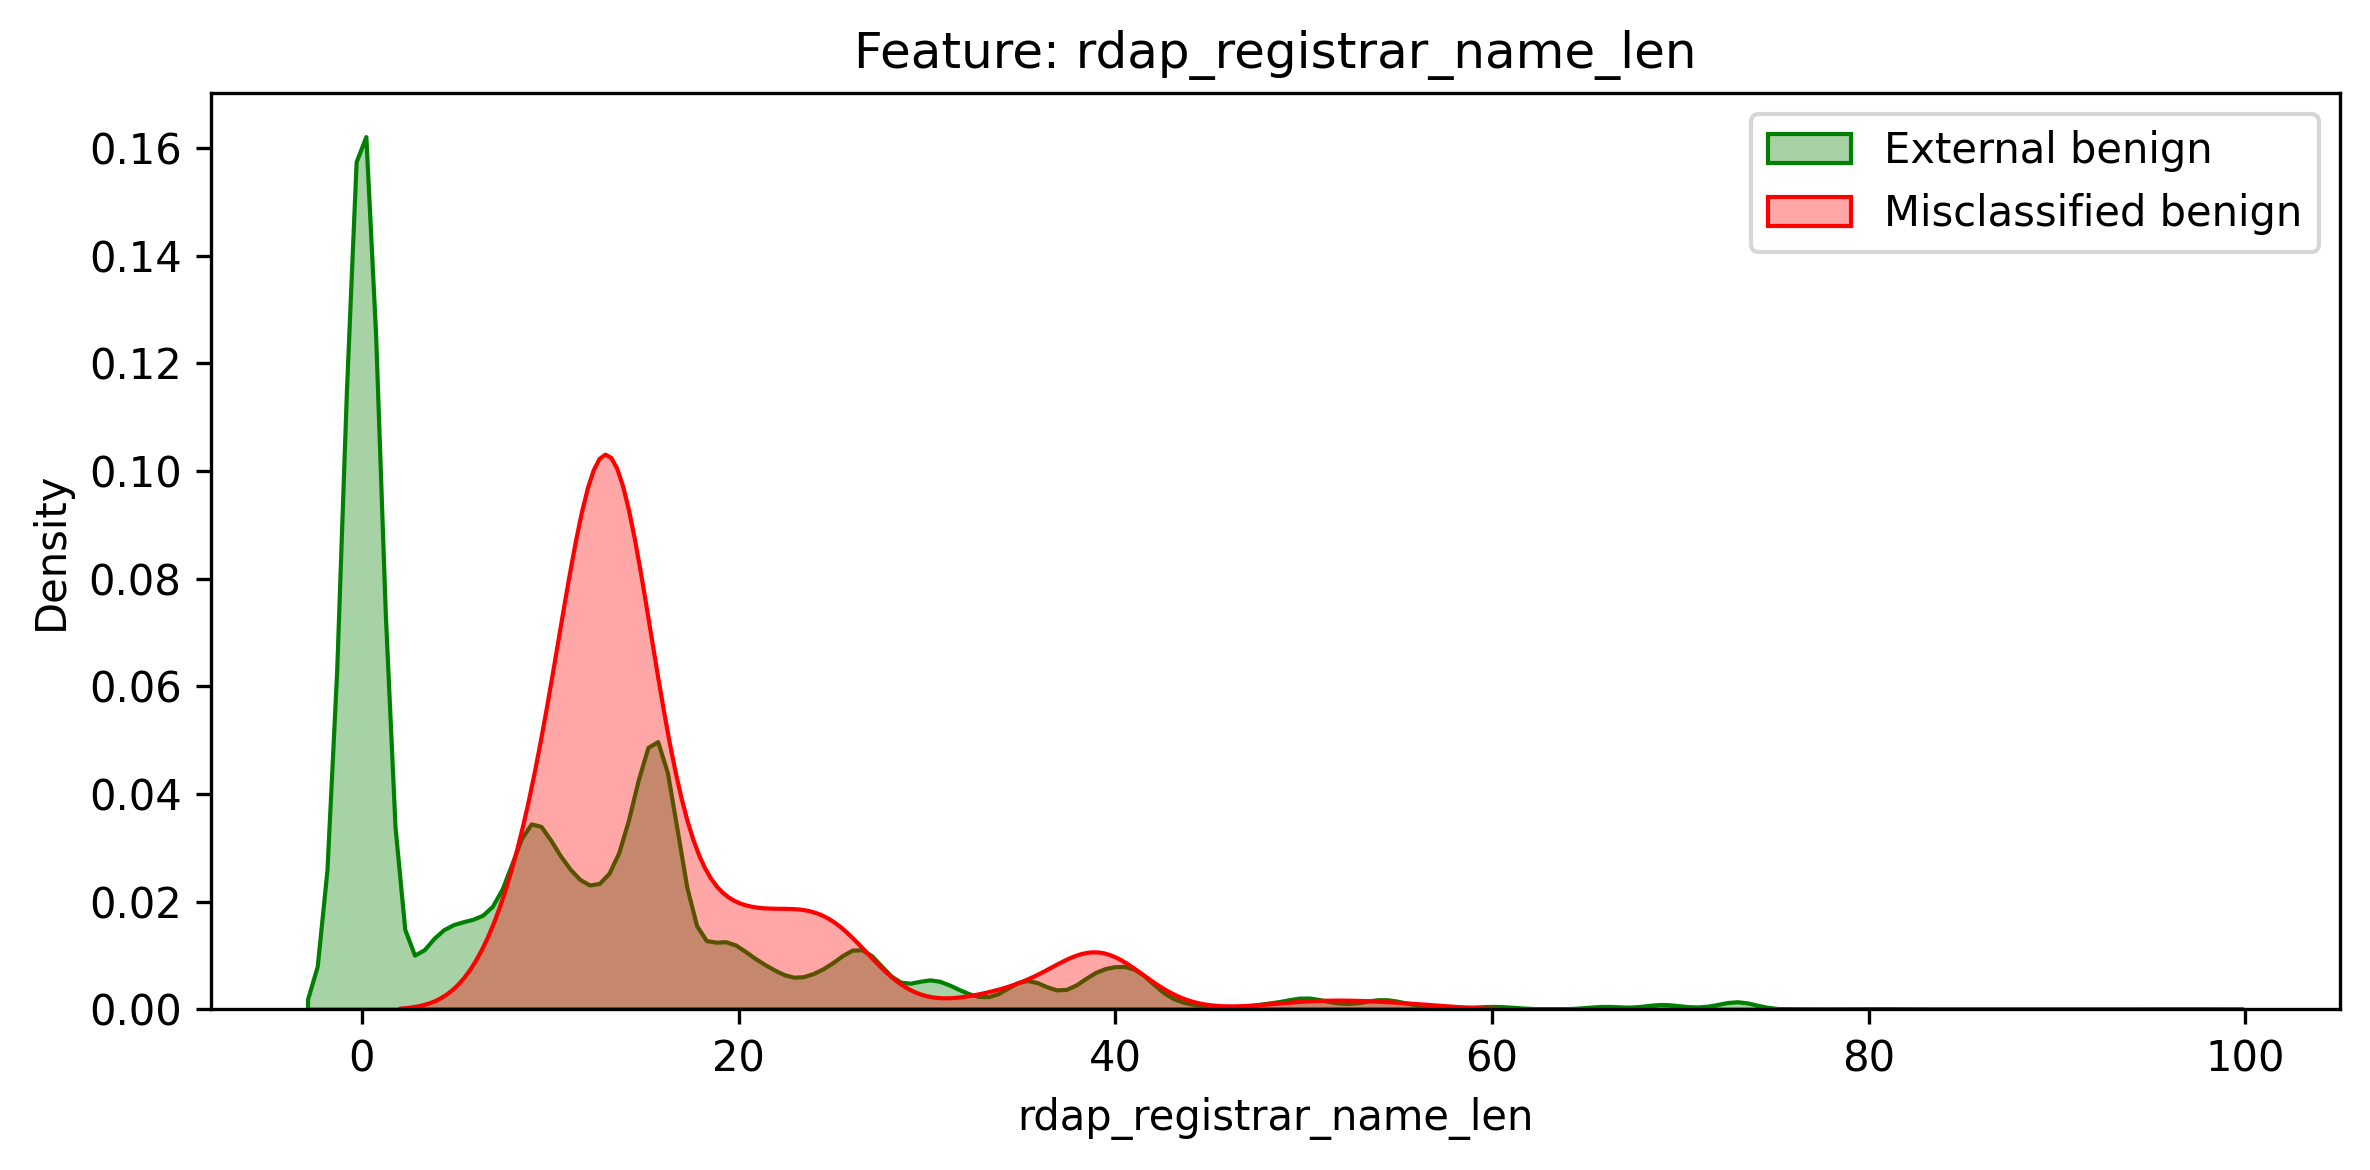

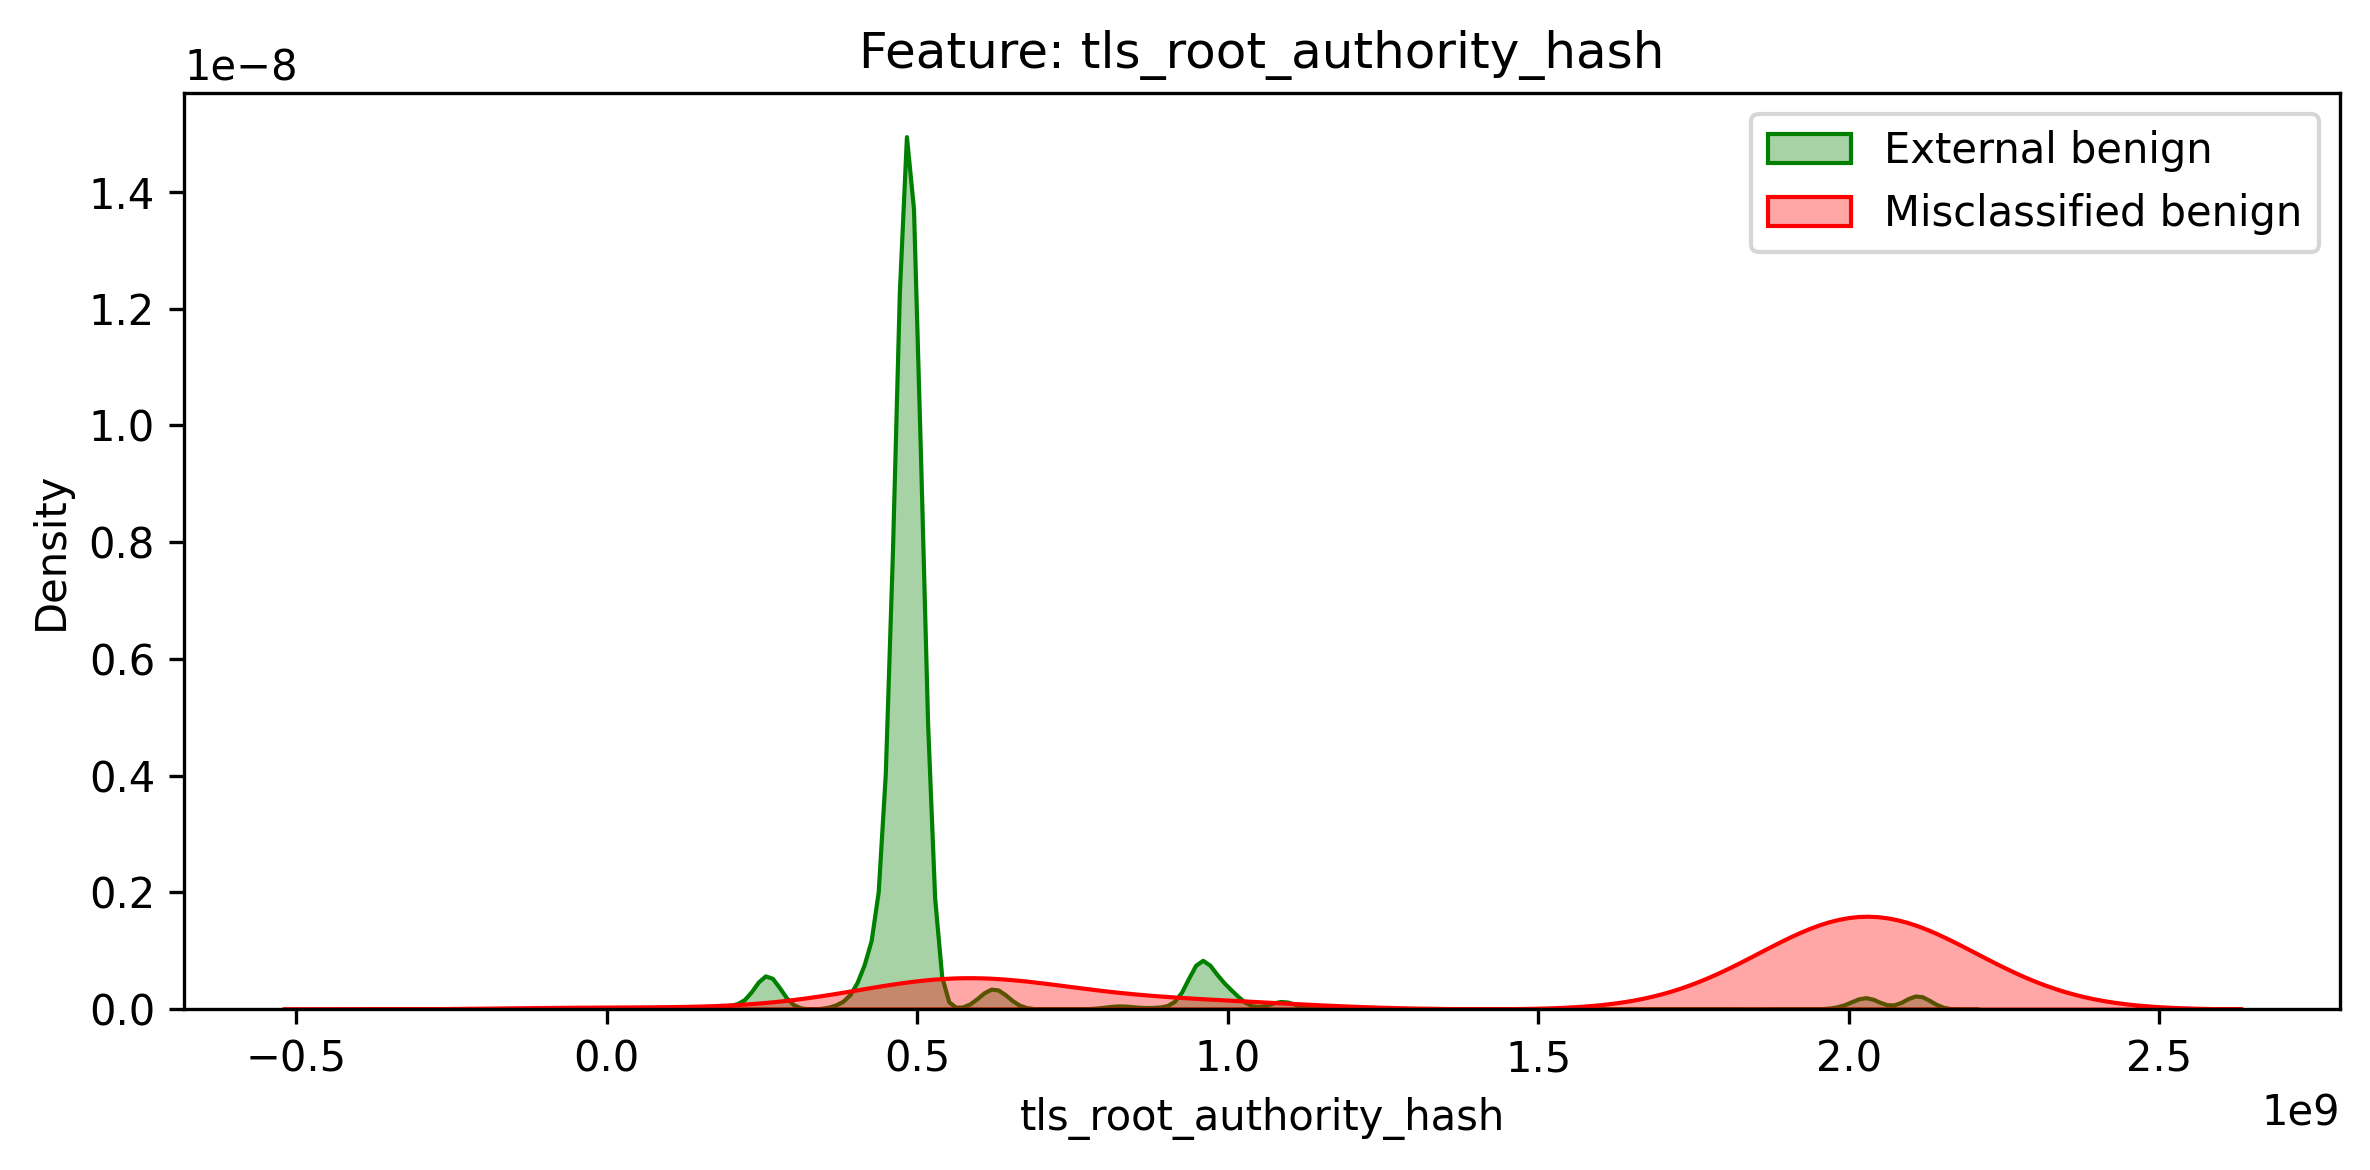

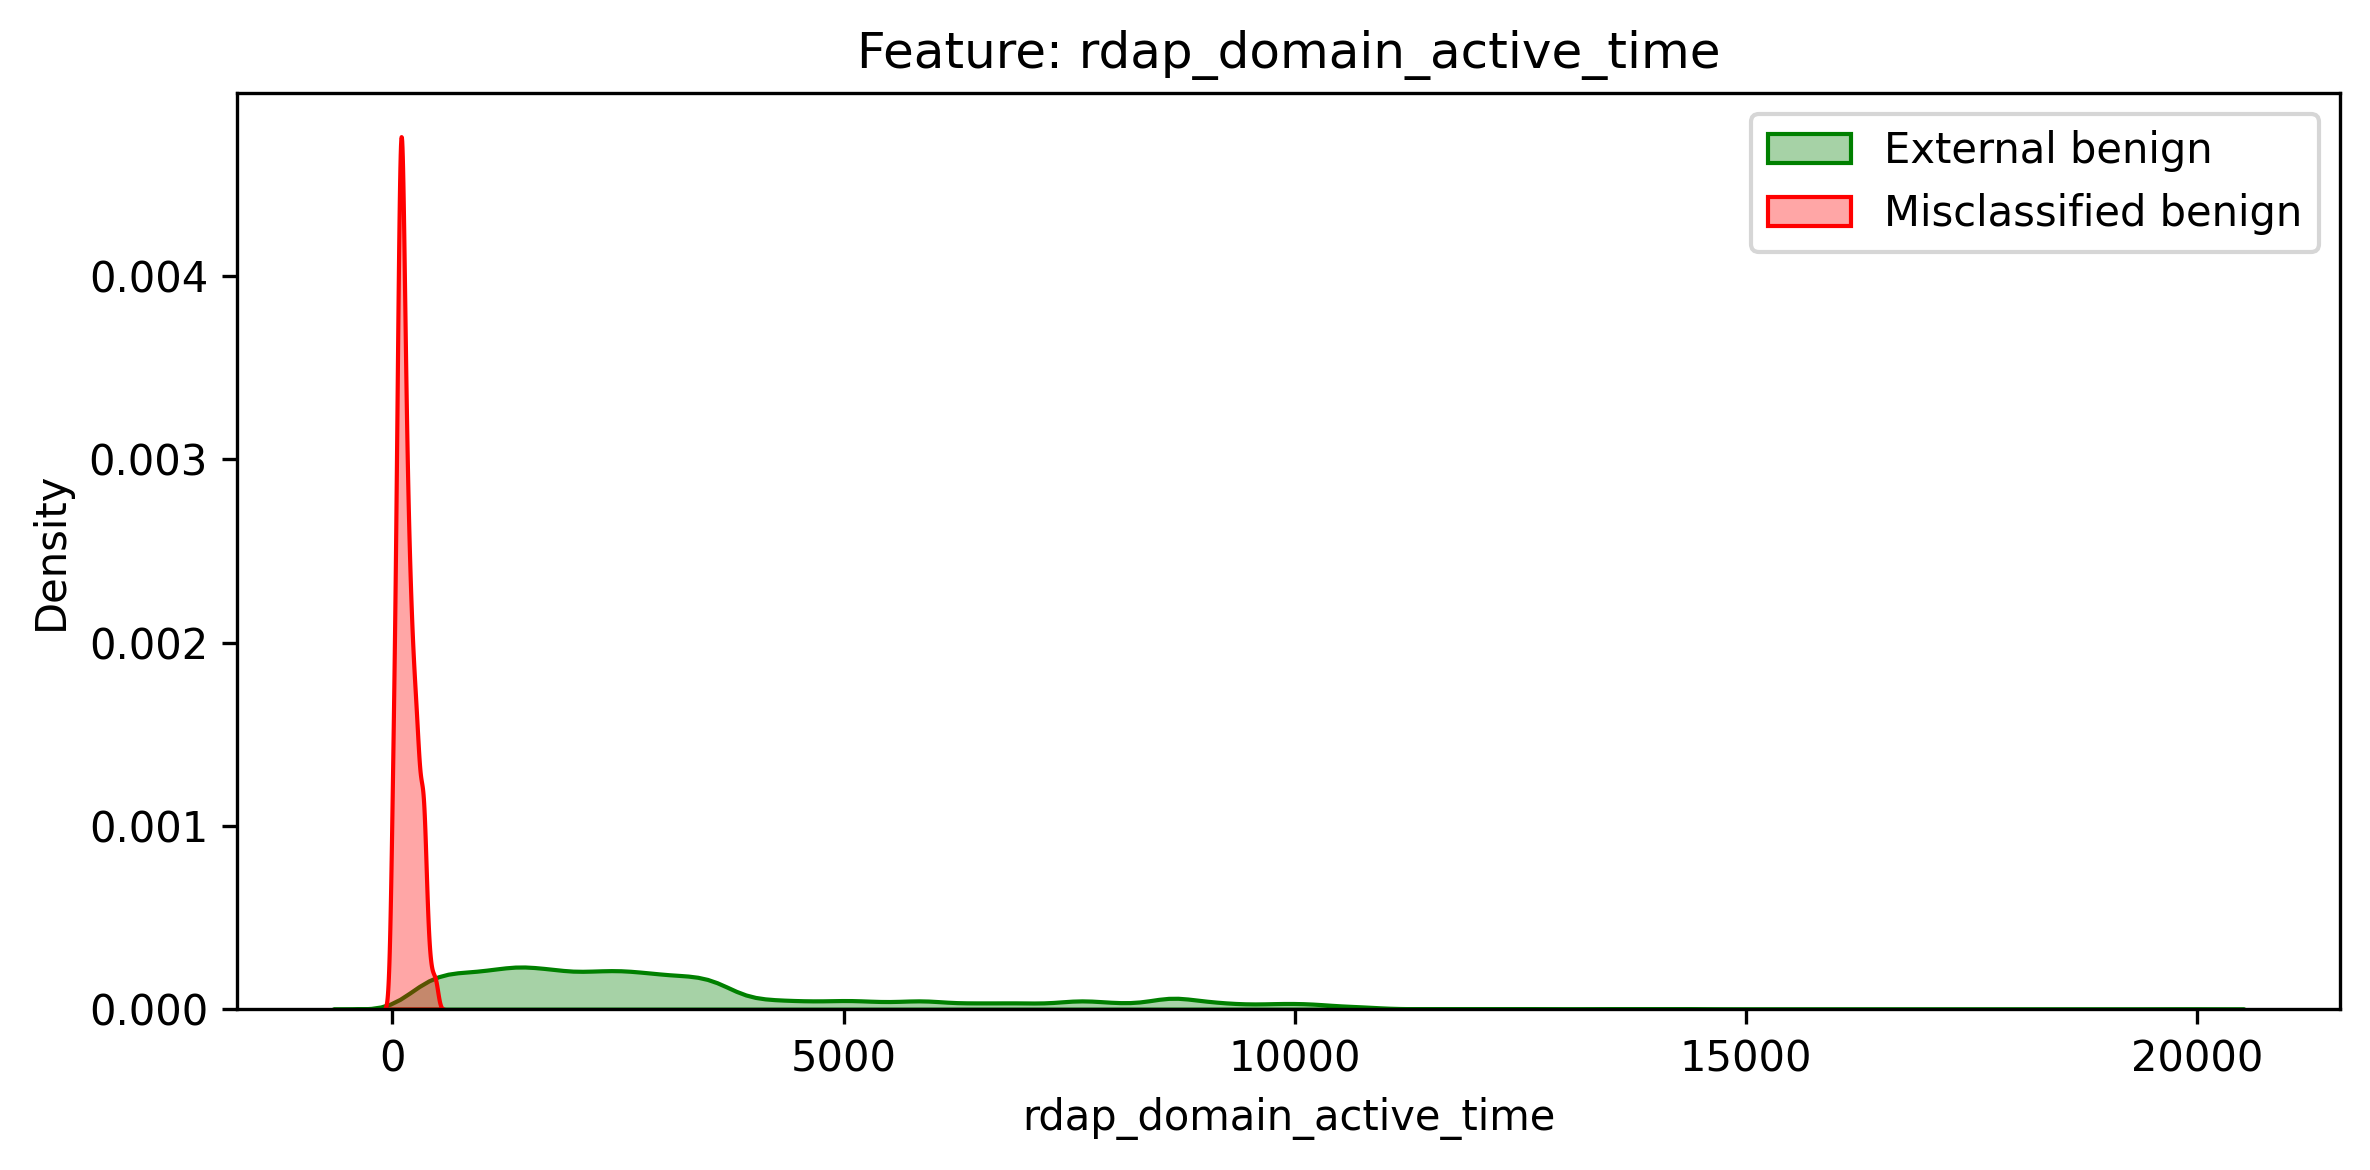

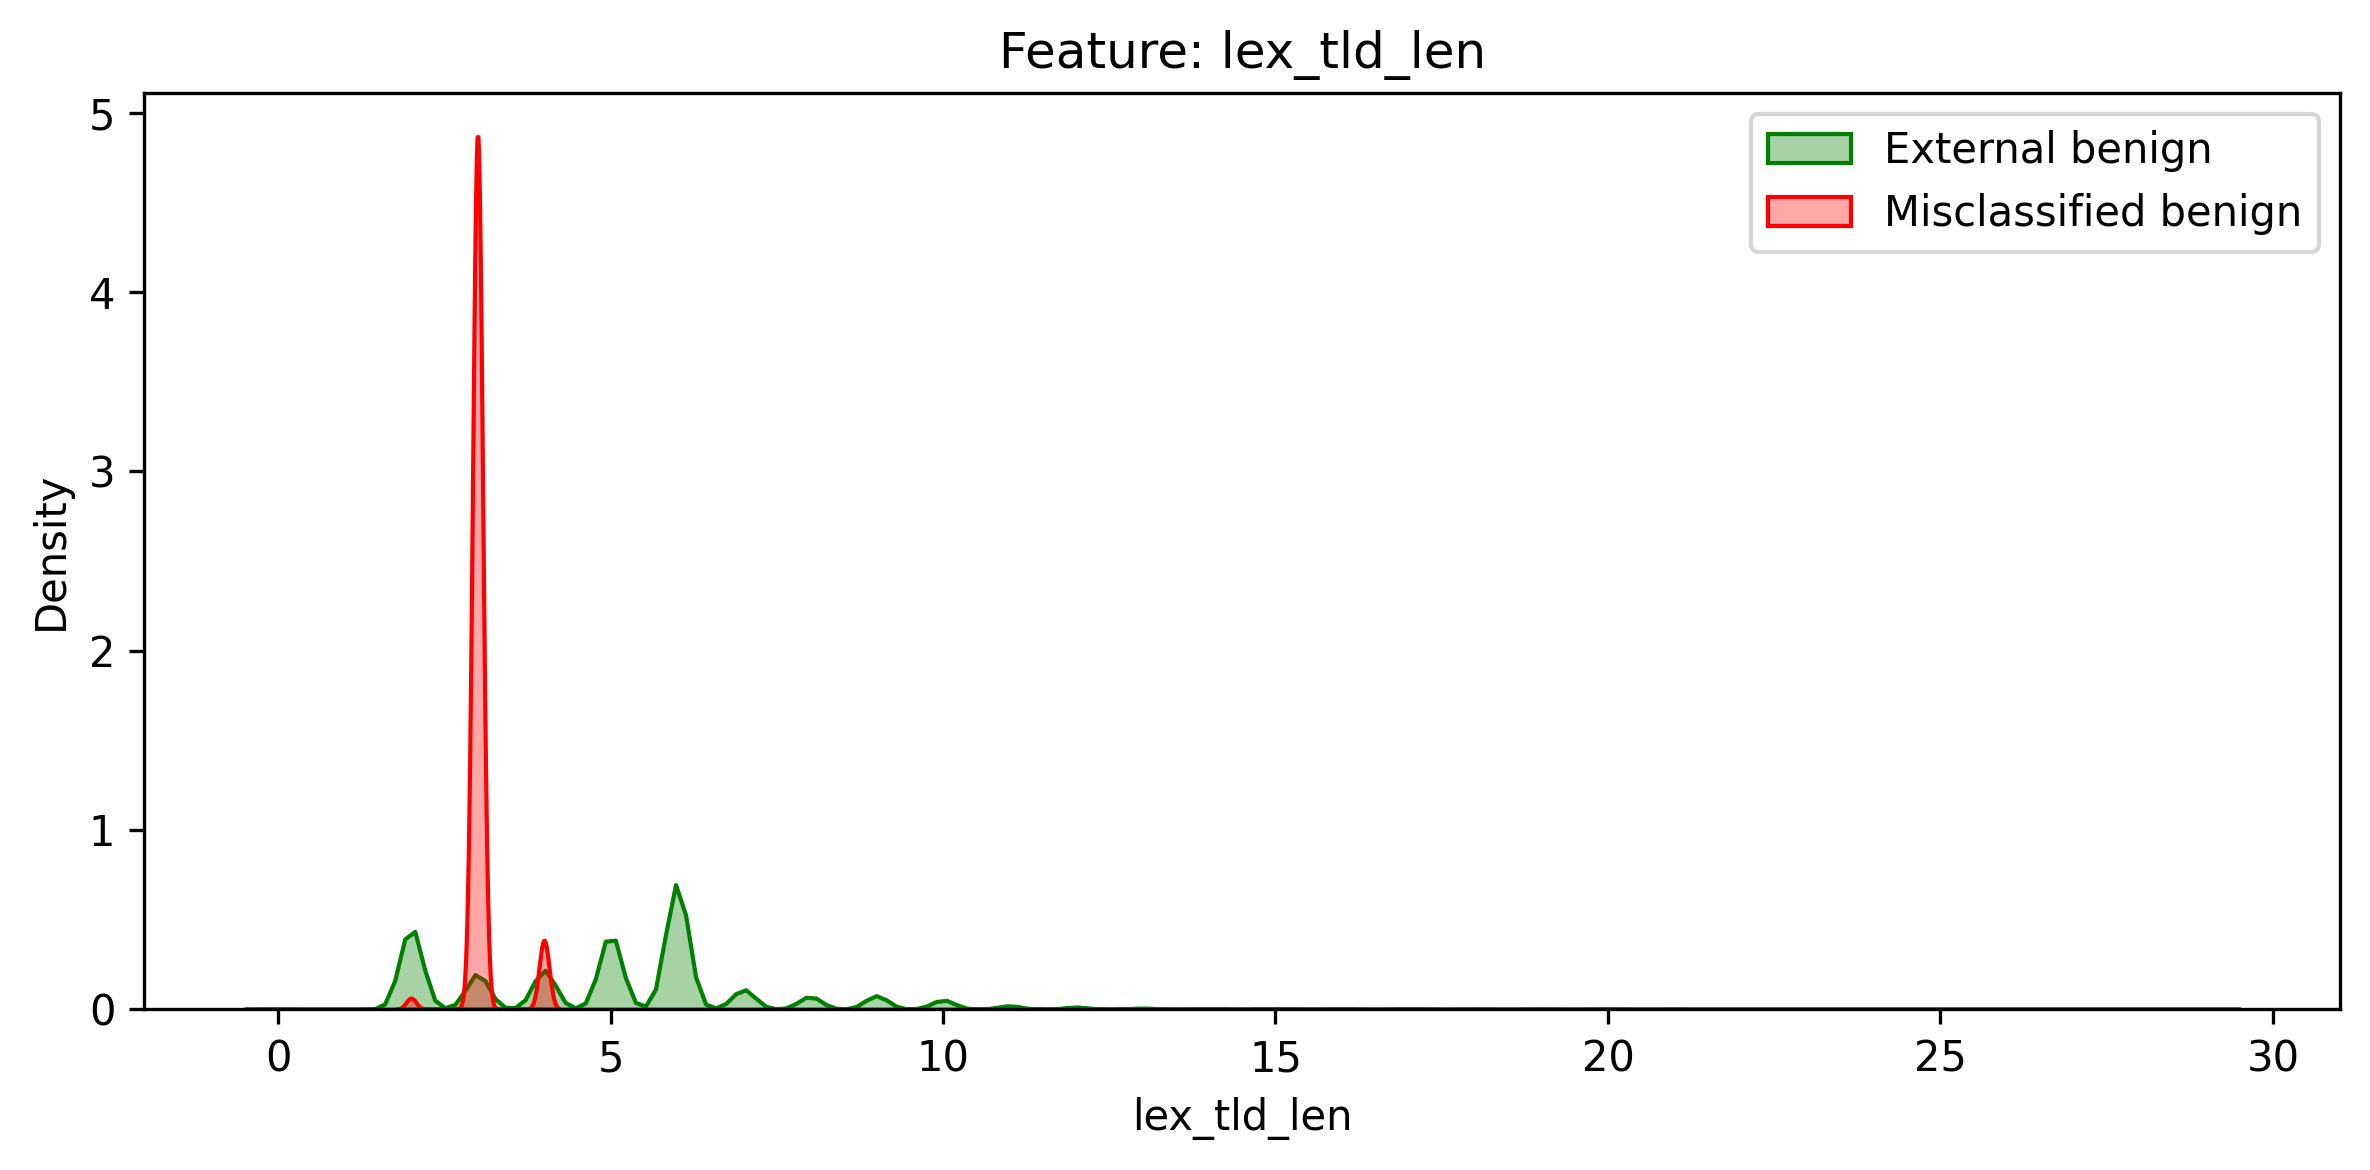

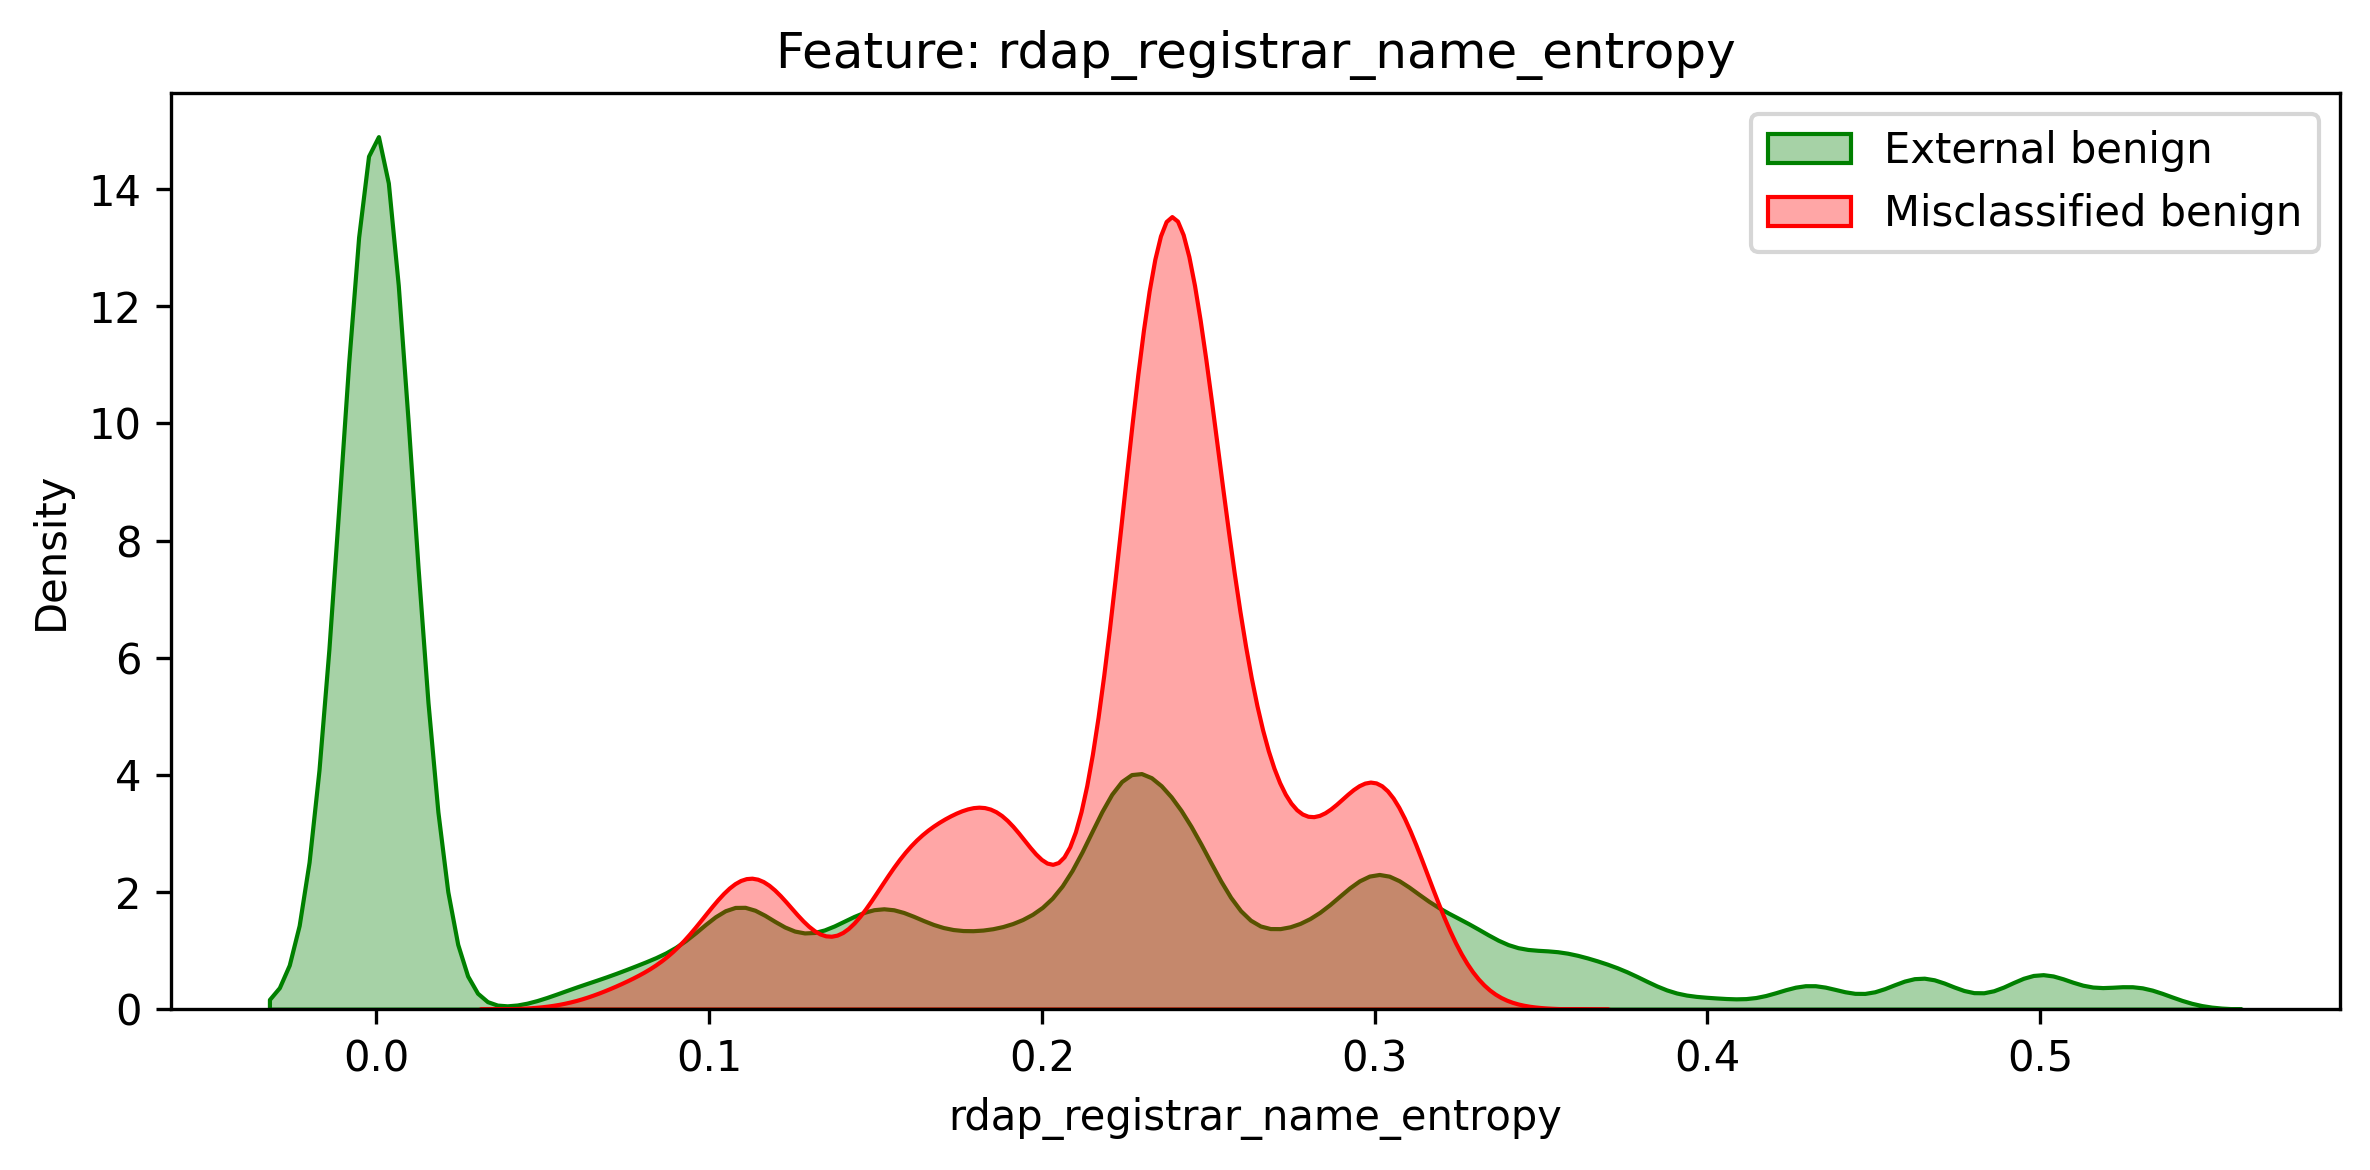

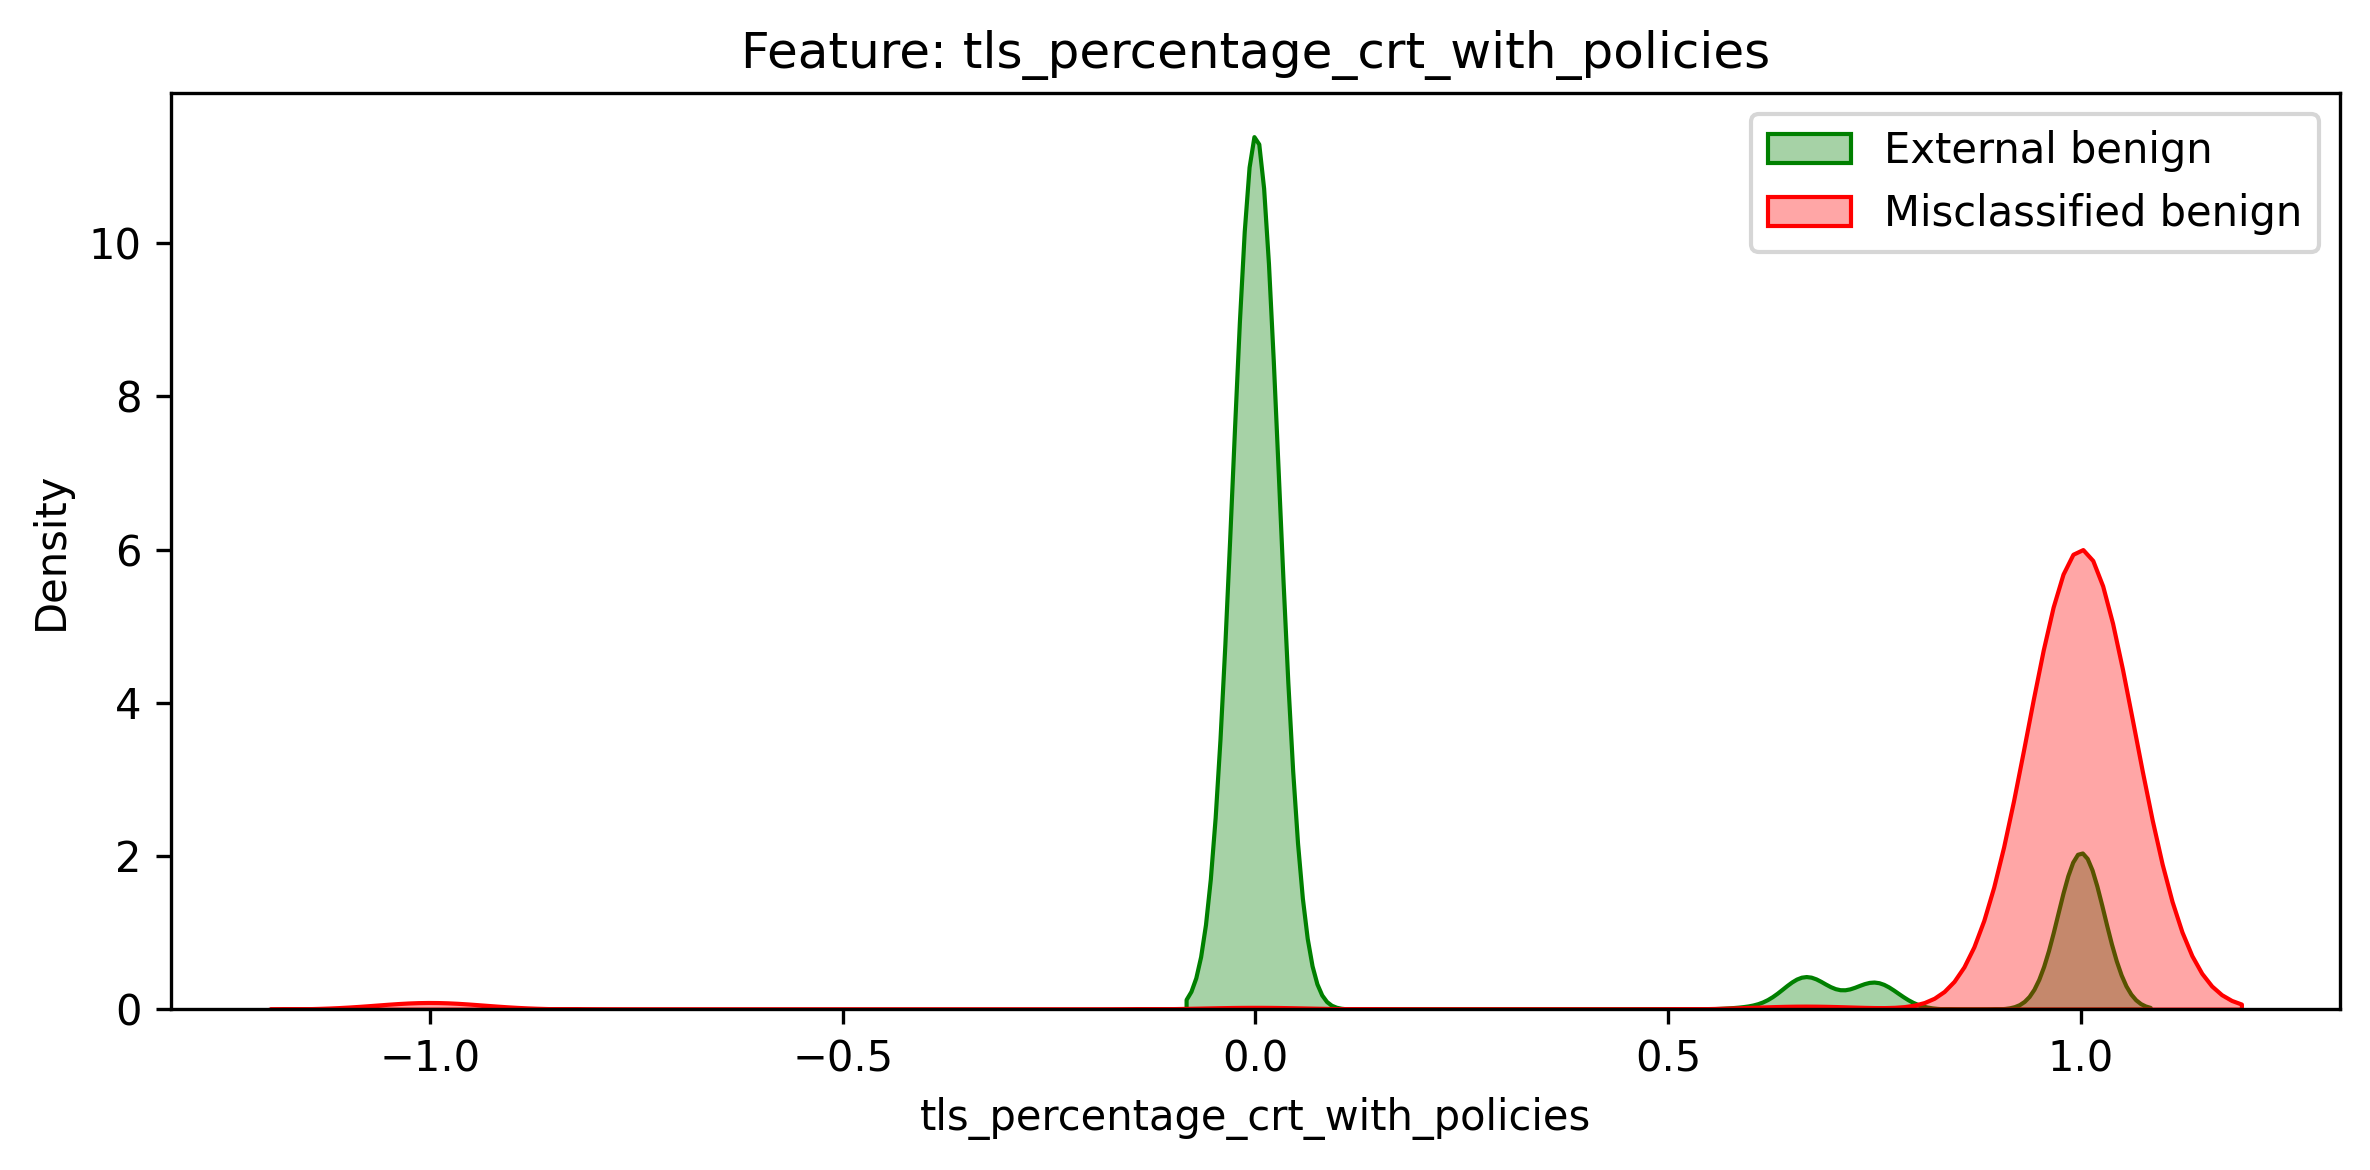

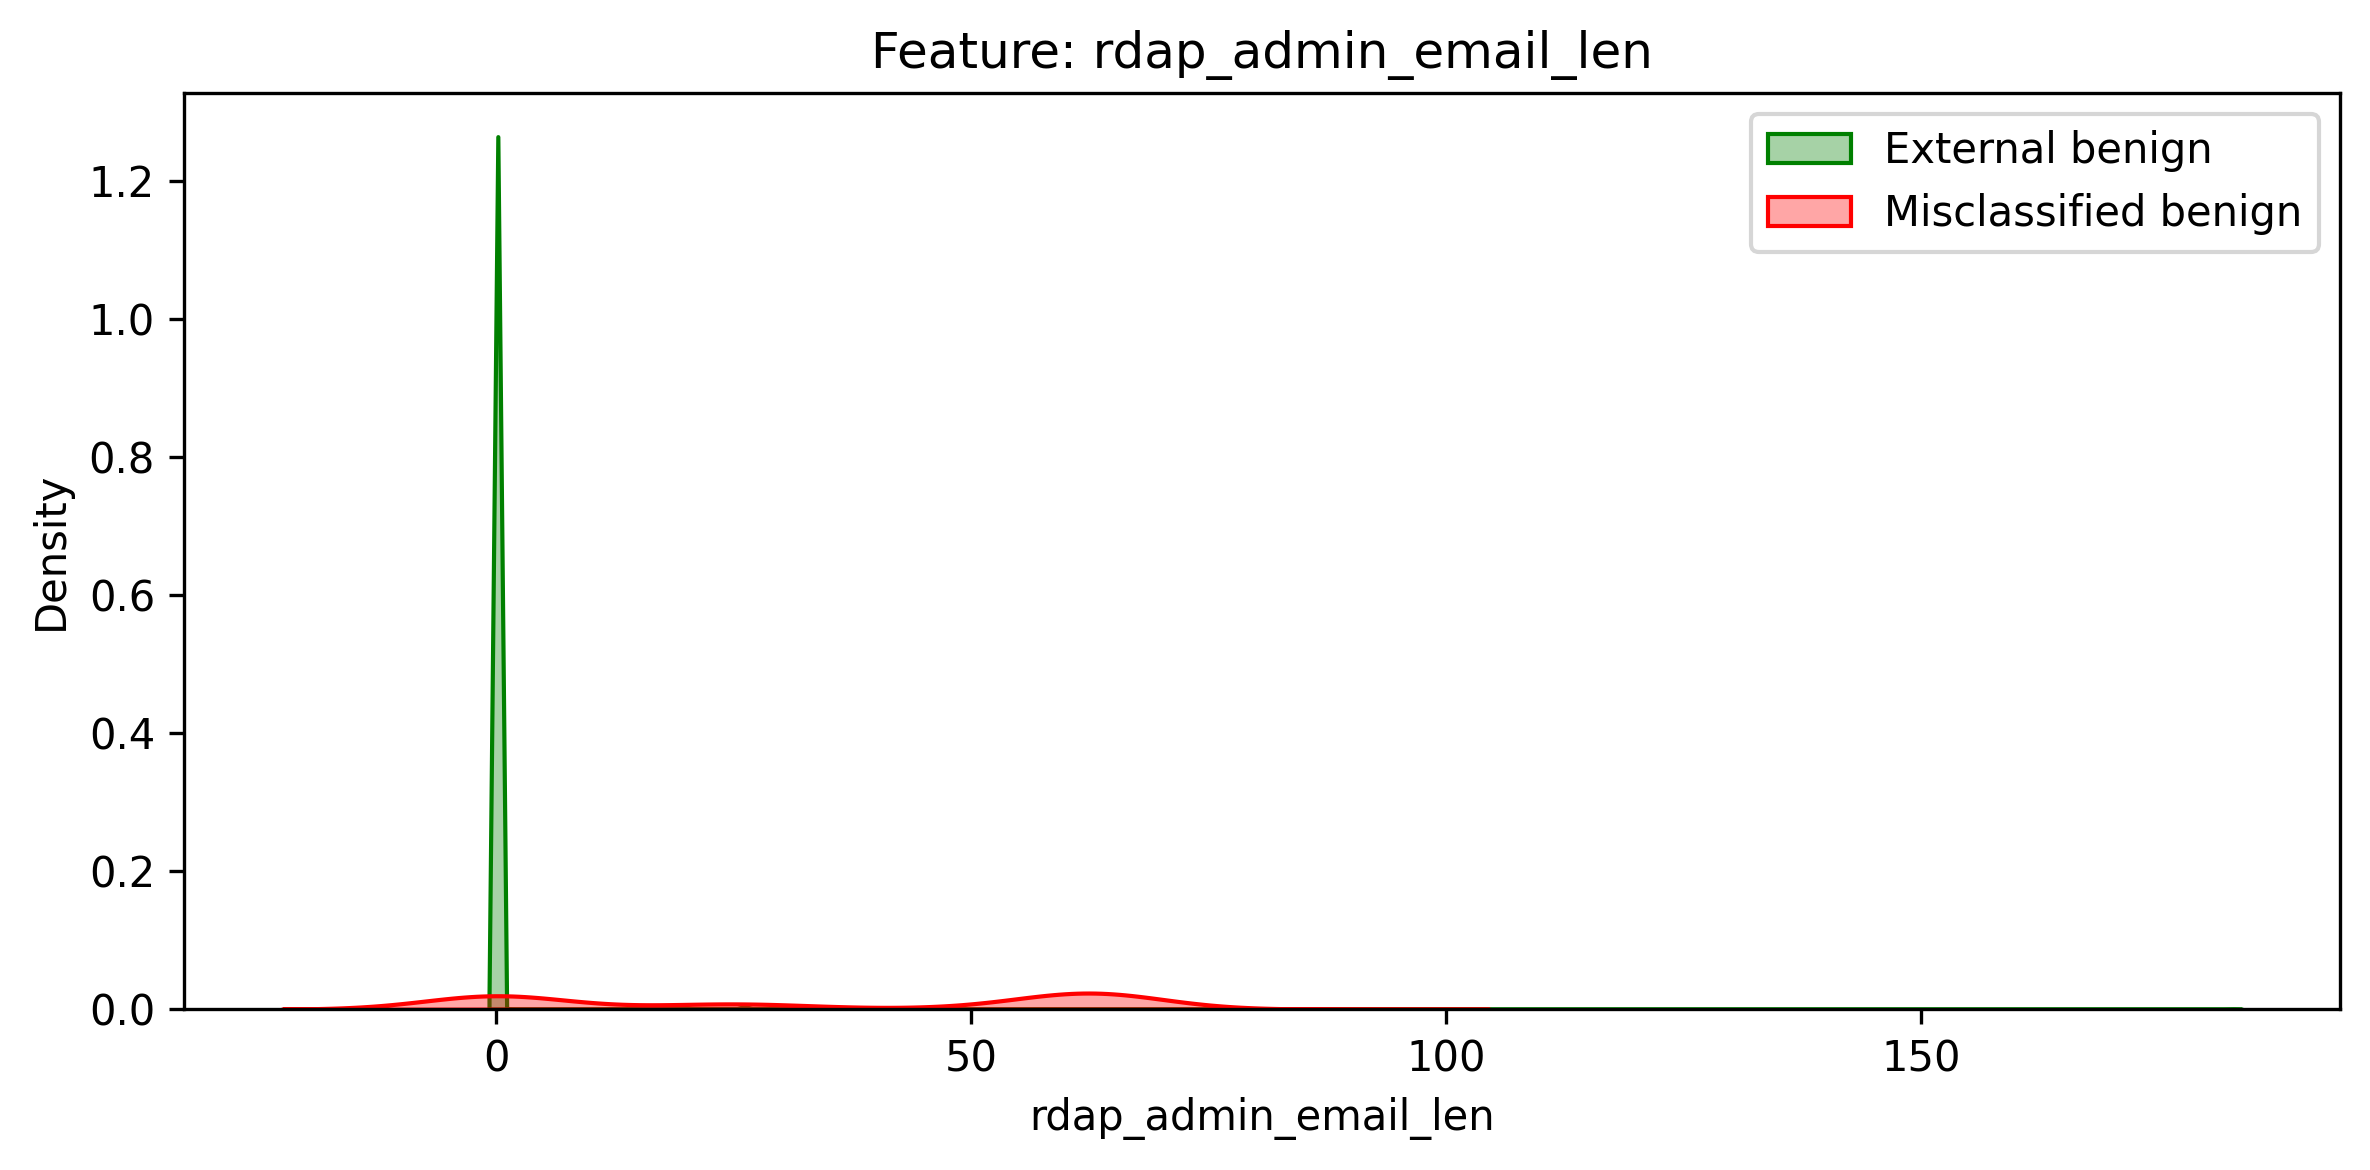

                            feature  threshold phishing_side      mis_mean  \
0                   rdap_domain_age        NaN            <=  1.590630e+02   
1               lex_tld_abuse_score        NaN             >  4.792054e-01   
2        tls_leaf_cert_validity_len        NaN            <=  9.367655e+01   
3           rdap_registrar_name_len        NaN             >  1.706186e+01   
4           tls_root_authority_hash        NaN             >  1.600355e+09   
5           rdap_domain_active_time        NaN            <=  1.590385e+02   
6                       lex_tld_len        NaN            <=  3.060567e+00   
7       rdap_registrar_name_entropy        NaN             >  2.250706e-01   
8  tls_percentage_crt_with_policies        NaN             >  9.656357e-01   
9              rdap_admin_email_len        NaN             >  3.327062e+01   

   external_benign_mean          diff  
0          3.428530e+03 -3.269467e+03  
1          1.268697e-03  4.779367e-01  
2          1.472726e+

In [25]:
# Step 1: get top features (from SHAP analysis or previous step)
top_df = plot_top_problematic_features(model, misclassified, top_k=10, positive_class=1)
top_features = top_df["feature"].tolist()

# Step 2: compare misclassified FP vs external benign
summary_ext = compare_with_external_benign(
    model,
    misclassified_df=misclassified,
    top_features=top_features,
    benign_file="../feature-extraction/floor/benign_2312.parquet",
    top_k=10
)

print(summary_ext)

rdap_domain_age
-1.000000      149
 159.000000      2
 45.534468       2
 131.000000      2
 0.788472        2
              ... 
 197.559884      1
 59.561215       1
 346.696759      1
 102.205868      1
 20.042731       1
Name: count, Length: 797, dtype: int64
rdap_domain_age
-1.000000      0.157007
 159.000000    0.002107
 45.534468     0.002107
 131.000000    0.002107
 0.788472      0.002107
                 ...   
 197.559884    0.001054
 59.561215     0.001054
 346.696759    0.001054
 102.205868    0.001054
 20.042731     0.001054
Name: proportion, Length: 797, dtype: float64


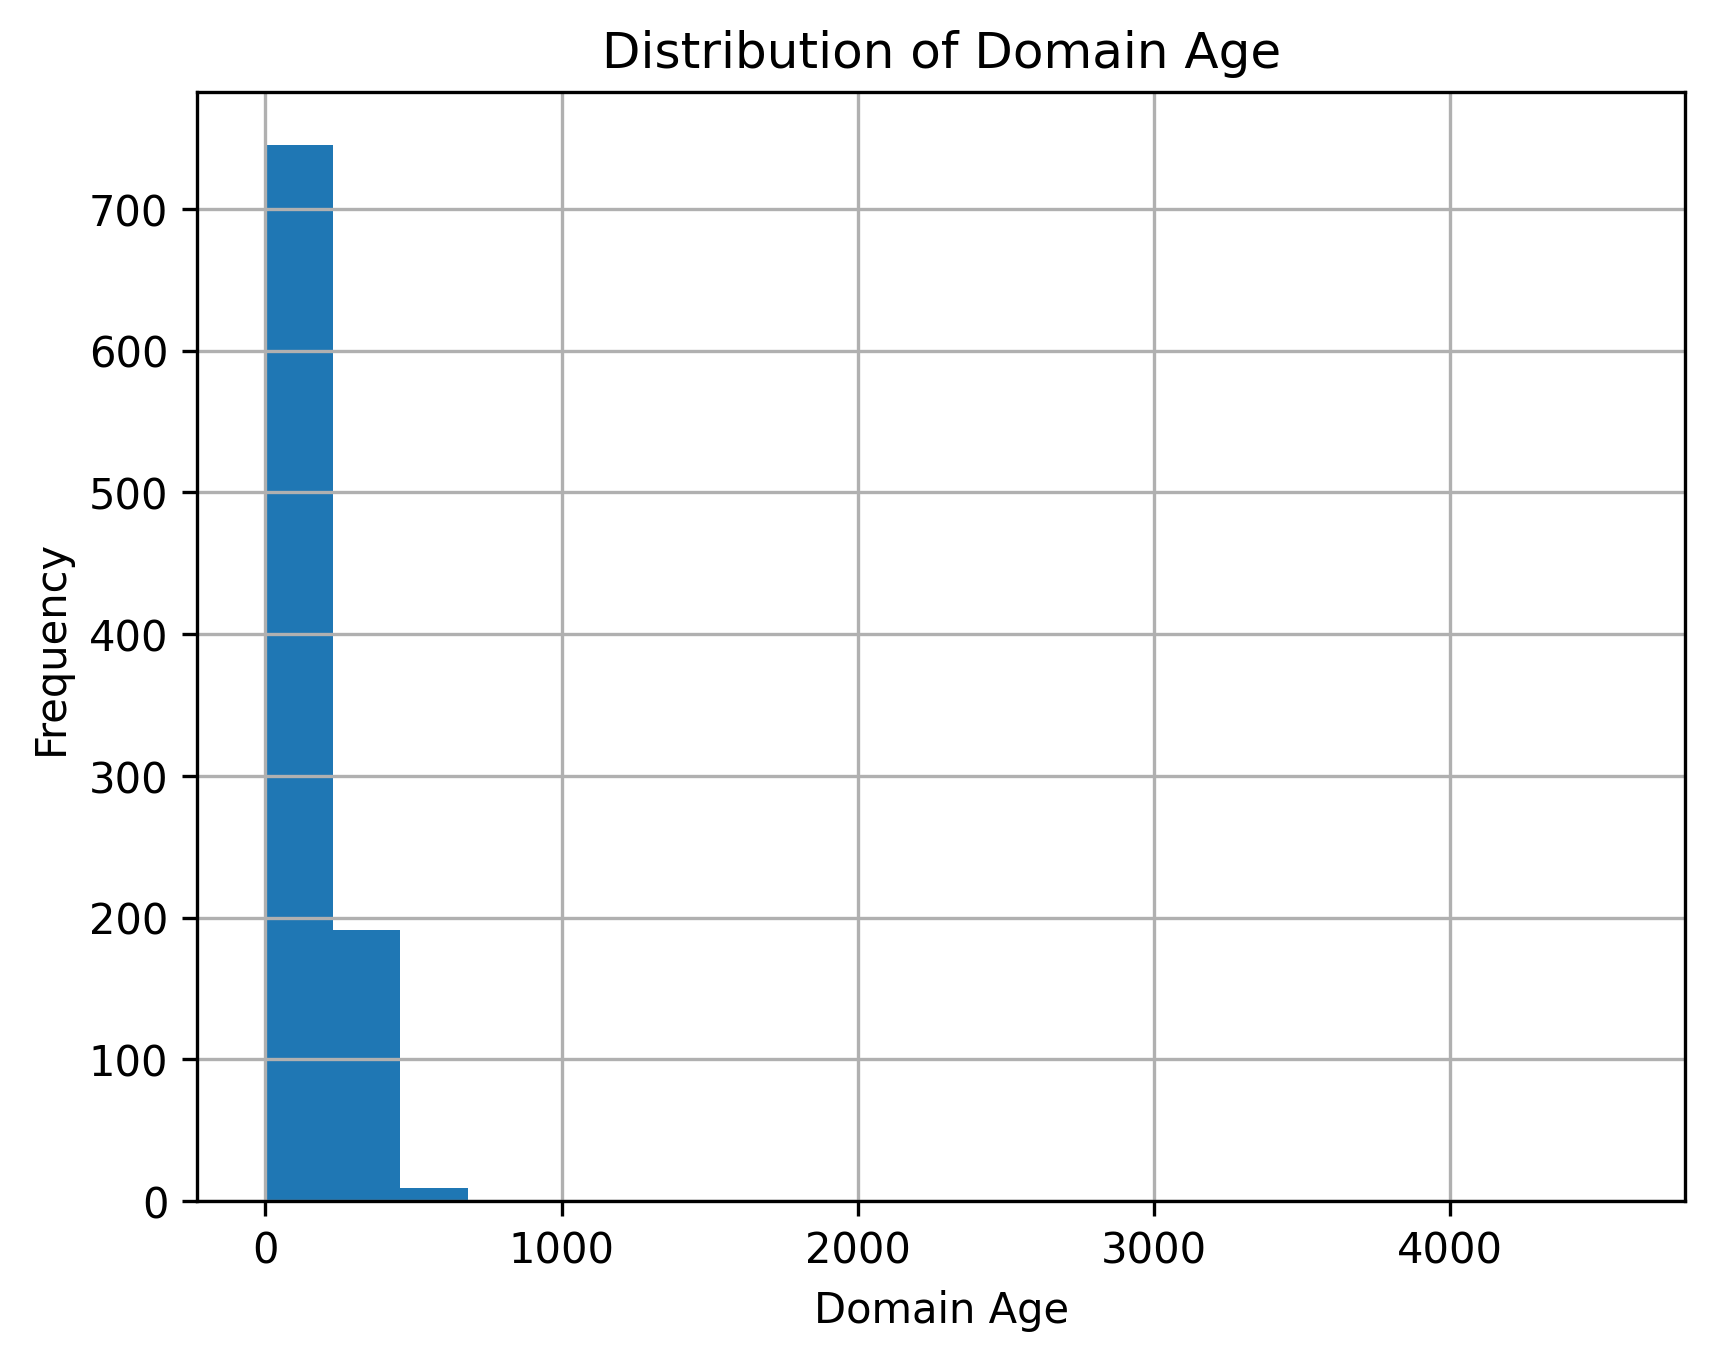

In [26]:
# domain age

import pandas as pd
import matplotlib.pyplot as plt

# Example: Assuming df is your DataFrame
# Frequency count
print(df_validation['rdap_domain_age'].value_counts())

# Normalized frequency (percentages)
print(df_validation['rdap_domain_age'].value_counts(normalize=True))

# Histogram (if it's numeric/continuous)
df_validation['rdap_domain_age'].hist(bins=20)
plt.xlabel("Domain Age")
plt.ylabel("Frequency")
plt.title("Distribution of Domain Age")
plt.show()

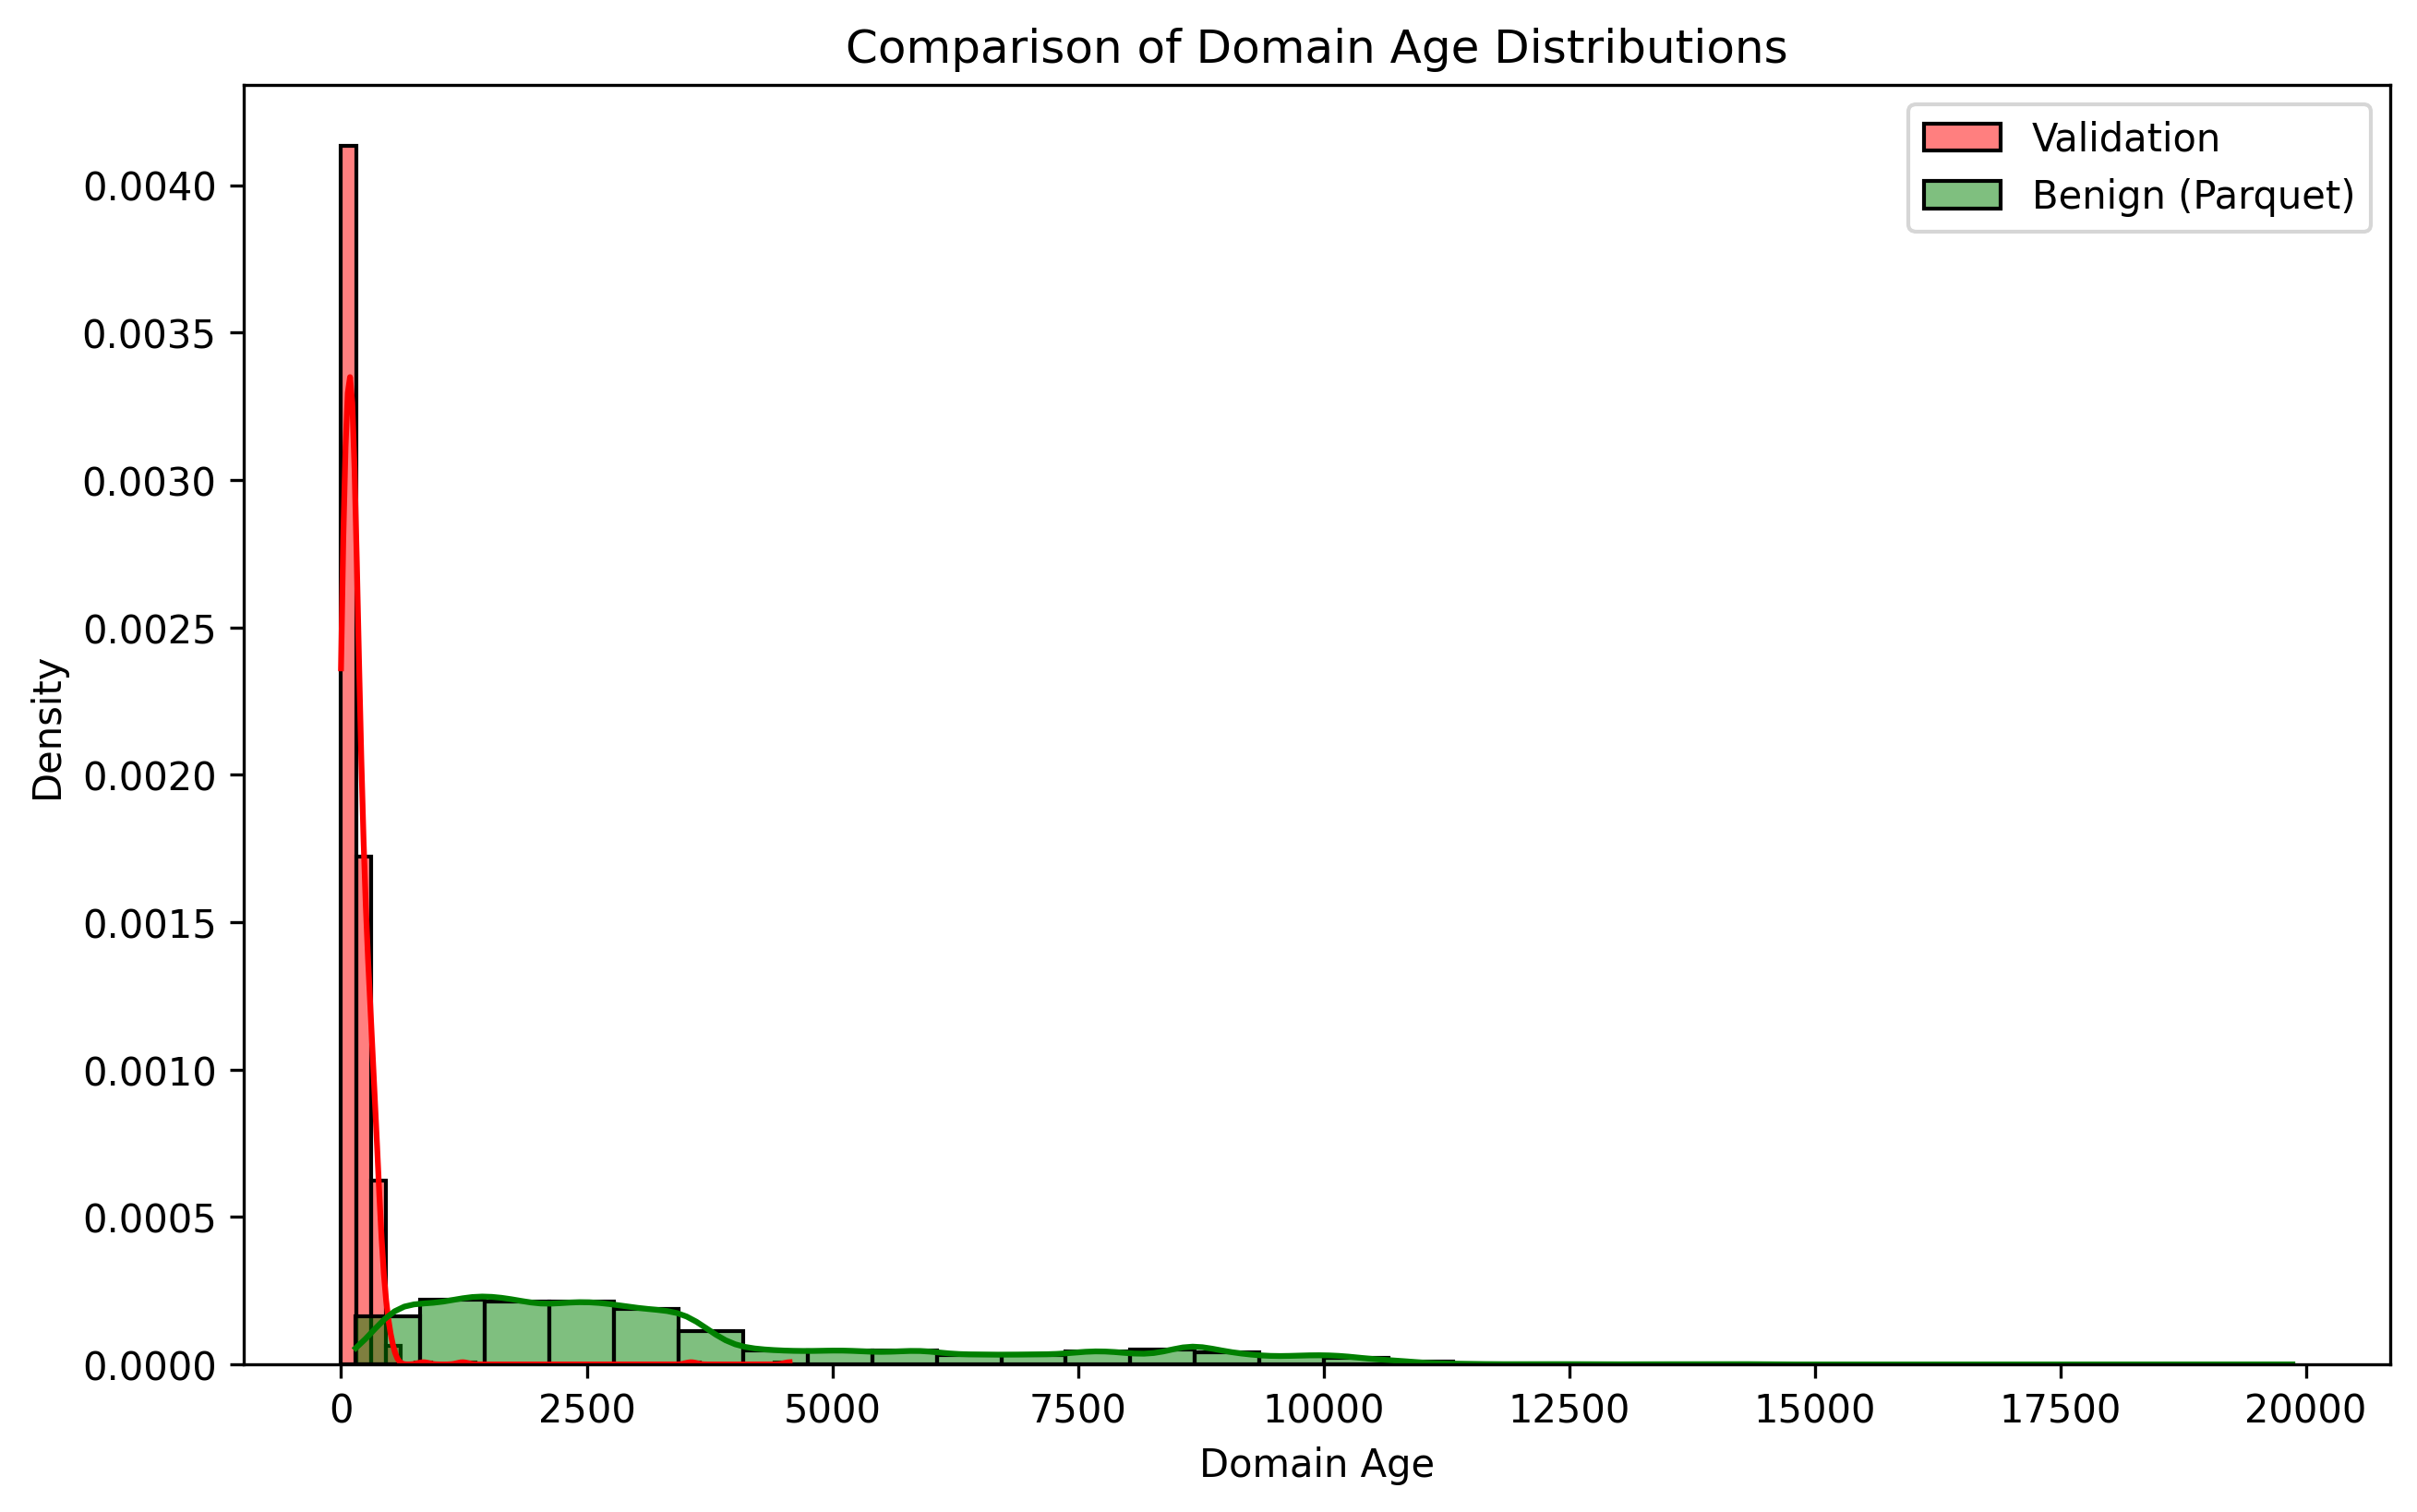

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the parquet file
df_benign = pd.read_parquet("../feature-extraction/floor/benign_2312.parquet")

# Ensure both are numeric
df_validation['rdap_domain_age'] = pd.to_numeric(df_validation['rdap_domain_age'], errors='coerce')
df_benign['rdap_domain_age'] = pd.to_numeric(df_benign['rdap_domain_age'], errors='coerce')

# Drop NaN values
df_validation = df_validation.dropna(subset=['rdap_domain_age'])
df_benign = df_benign.dropna(subset=['rdap_domain_age'])

# Plot
plt.figure(figsize=(10,6))

sns.histplot(df_validation['rdap_domain_age'], bins=30, kde=True, color="red", label="Validation", stat="density", alpha=0.5)
sns.histplot(df_benign['rdap_domain_age'], bins=30, kde=True, color="green", label="Benign (Parquet)", stat="density", alpha=0.5)

plt.xlabel("Domain Age")
plt.ylabel("Density")
plt.title("Comparison of Domain Age Distributions")
plt.legend()
plt.show()


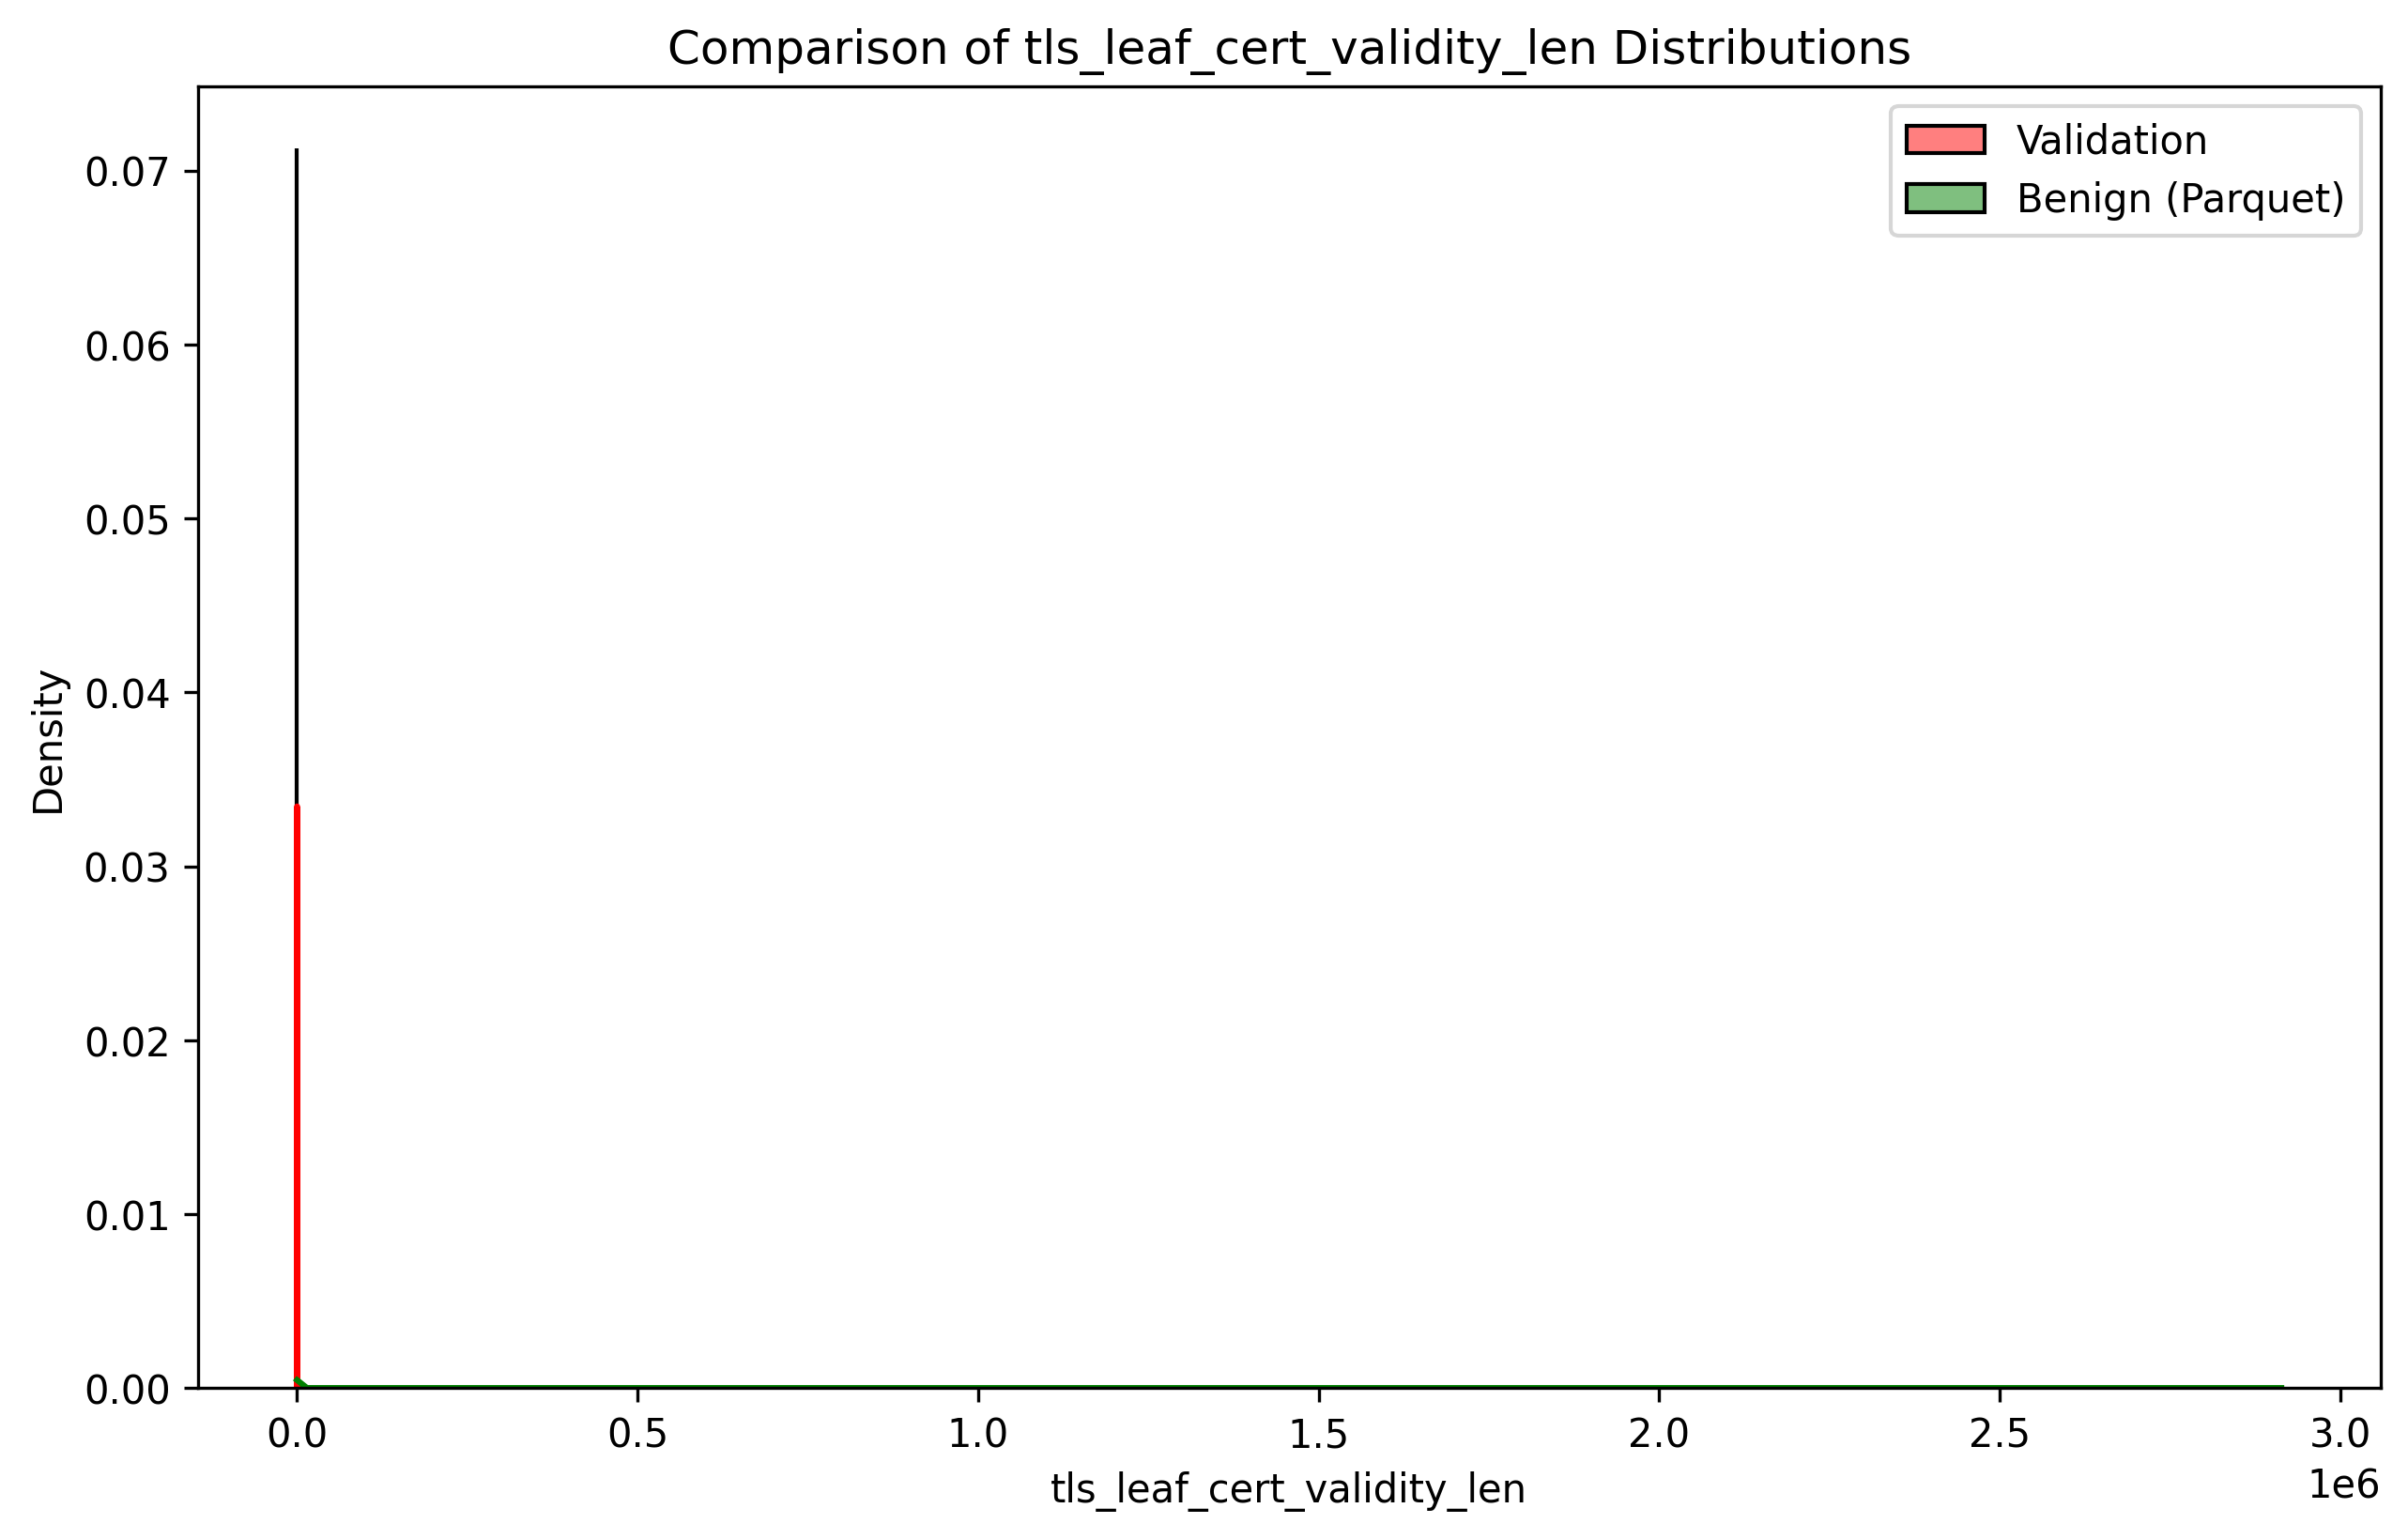

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_name = 'tls_leaf_cert_validity_len'

# Ensure both are numeric
df_validation[feature_name] = pd.to_numeric(df_validation[feature_name], errors='coerce')
df_benign[feature_name] = pd.to_numeric(df_benign[feature_name], errors='coerce')

# Drop NaN values
df_validation = df_validation.dropna(subset=[feature_name])
df_benign = df_benign.dropna(subset=[feature_name])


# Plot
plt.figure(figsize=(10,6))

sns.histplot(df_validation[feature_name], bins=30, kde=True, color="red", label="Validation", stat="density", alpha=0.5)
sns.histplot(df_benign[feature_name], bins=30, kde=True, color="green", label="Benign (Parquet)", stat="density", alpha=0.5)

plt.xlabel(feature_name)
plt.ylabel("Density")
plt.title("Comparison of "+feature_name+" Distributions")
plt.legend()
plt.show()


tls_leaf_cert_validity_len
 90.0     880
-1.0       26
 91.0      15
 366.0     13
 365.0      3
 395.0      2
 61.0       1
 73.0       1
 314.0      1
 302.0      1
 105.0      1
 298.0      1
 396.0      1
 72.0       1
 224.0      1
 46.0       1
Name: count, dtype: int64
tls_leaf_cert_validity_len
 90.0     0.927292
-1.0      0.027397
 91.0     0.015806
 366.0    0.013699
 365.0    0.003161
 395.0    0.002107
 61.0     0.001054
 73.0     0.001054
 314.0    0.001054
 302.0    0.001054
 105.0    0.001054
 298.0    0.001054
 396.0    0.001054
 72.0     0.001054
 224.0    0.001054
 46.0     0.001054
Name: proportion, dtype: float64


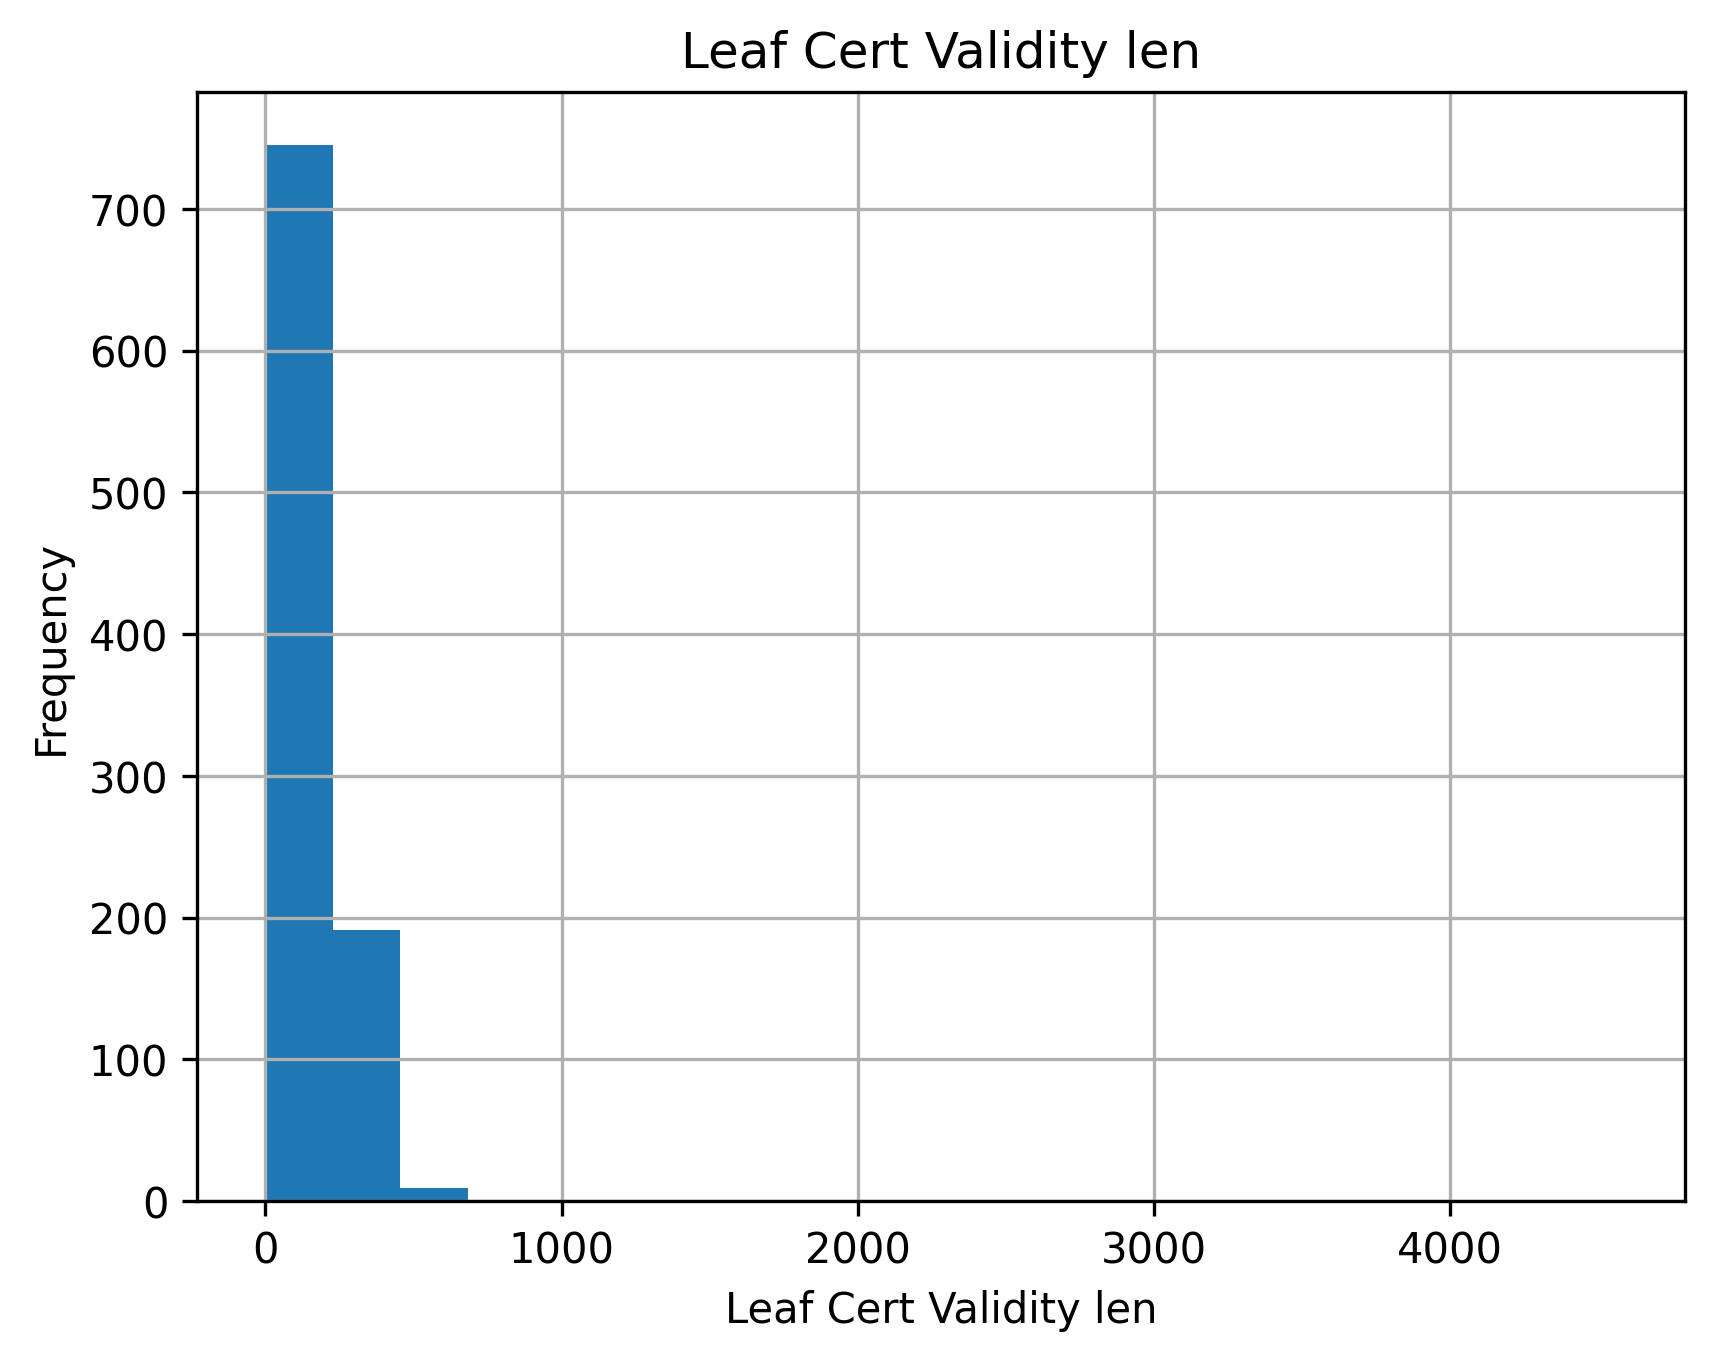

In [29]:
# domain age

import pandas as pd
import matplotlib.pyplot as plt

# Example: Assuming df is your DataFrame
# Frequency count
print(df_validation['tls_leaf_cert_validity_len'].value_counts())

# Normalized frequency (percentages)
print(df_validation['tls_leaf_cert_validity_len'].value_counts(normalize=True))

# Histogram (if it's numeric/continuous)
df_validation['rdap_domain_age'].hist(bins=20)
plt.xlabel("Leaf Cert Validity len")
plt.ylabel("Frequency")
plt.title("Leaf Cert Validity len")
plt.show()

In [34]:
# DISPLAY FEATURE VALUES FOR SOME DOMAINS

import pyarrow as pa
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import difflib

# ==== CONFIG ====
N_DOMAINS = 200           # how many unique domains to sample
RANDOM_SEED = 42          # reproducible sampling
COL = "leaf_cert_validity_len"
# ================

# --- 1) Build unified schema across ALL parquet files ---
all_files = benign_dataset_filenames + malicious_dataset_filenames
schemas = [pq.read_table(f).schema for f in all_files]
unified_schema = pa.unify_schemas(schemas)

# --- 2) Read & cast using the unified schema ---
benign_tables    = [pq.read_table(f).cast(unified_schema) for f in benign_dataset_filenames]
malicious_tables = [pq.read_table(f).cast(unified_schema) for f in malicious_dataset_filenames]

# Use your union_tables() if available to deduplicate by domain_name; otherwise concat
try:
    benign_arrow    = union_tables(benign_tables)
    malicious_arrow = union_tables(malicious_tables)
except NameError:
    benign_arrow    = pa.concat_tables(benign_tables, promote=True)
    malicious_arrow = pa.concat_tables(malicious_tables, promote=True)

# --- 3) Combine into a pandas DataFrame ---
df_benign    = benign_arrow.to_pandas()
df_malicious = malicious_arrow.to_pandas()
df = pd.concat([df_benign, df_malicious], ignore_index=True)

# --- 4) Subsample by domain (or by rows if domain_name missing) ---
rng = np.random.default_rng(RANDOM_SEED)
if "domain_name" in df.columns:
    uniq_domains = pd.Series(df["domain_name"].dropna().unique())
    if len(uniq_domains) == 0:
        print("Warning: 'domain_name' exists but is empty; falling back to row sampling.")
        df_sub = df.sample(n=min(N_DOMAINS, len(df)), random_state=RANDOM_SEED)
    else:
        take = min(N_DOMAINS, len(uniq_domains))
        sampled_domains = uniq_domains.sample(n=take, random_state=RANDOM_SEED)
        df_sub = df[df["domain_name"].isin(sampled_domains)]
        print(f"Subsampled {take} unique domains -> {len(df_sub)} rows.")
else:
    print("Column 'domain_name' not found; sampling rows instead.")
    df_sub = df.sample(n=min(N_DOMAINS, len(df)), random_state=RANDOM_SEED)

# --- 5) Safely find invalid rows in the subsample ---
if COL not in df_sub.columns:
    print(f"Column '{COL}' not found in the subsample.")
    suggestions = difflib.get_close_matches(COL, df_sub.columns.tolist(), n=5)
    if suggestions:
        print("Did you mean:", suggestions)
else:
    vals = pd.to_numeric(df_sub[COL], errors="coerce")
    invalid_rows = df_sub[vals < 0]

    # Print full rows
    print(invalid_rows)

    # Print concise lines
    for idx, row in invalid_rows.iterrows():
        dom = row.get("domain_name", idx)
        print(f"Domain: {dom} | {COL}: {row[COL]}")


Subsampled 200 unique domains -> 200 rows.
Column 'leaf_cert_validity_len' not found in the subsample.
Did you mean: ['tls_leaf_cert_validity_len', 'tls_root_cert_validity_len', 'lex_tld_len']
